# Texas Housing Market Analysis

### Notebook 02: Exploratory Data Analysis

This notebook evaluates historical home-value growth and recent price momentum across nine North Dallas-area housing markets using the Zillow Home Value Index (ZHVI). 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
# PROJECT PATHS

PROJECT_ROOT = Path.cwd().parent
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
ZHVI_FILE = PROCESSED_DATA_DIR / "dallas_zhvi_monthly.csv"

print("Project root:", PROJECT_ROOT)
print("ZHVI File:", ZHVI_FILE)

Project root: /Users/ninahuang/Downloads/Personal/Projects/TX Market Analysis/tx_market_analysis
ZHVI File: /Users/ninahuang/Downloads/Personal/Projects/TX Market Analysis/tx_market_analysis/data/processed/dallas_zhvi_monthly.csv


## 1. Load Processed Zillow Data

This notebook uses the cleaned monthly ZHVI dataset produced in Notebook 01.

In [3]:
# LOAD PROCESSED ZHVI DATA

df = pd.read_csv(
    ZHVI_FILE, parse_dates = ["Date"]
)

print("Dataset shape:", df.shape)
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())
print("Cities:", sorted(df["City"].unique()))

Dataset shape: (927, 6)
Date range: 2018-01-31 to 2026-07-31
Cities: ['Anna', 'Celina', 'Frisco', 'McKinney', 'Melissa', 'Plano', 'Princeton', 'Prosper', 'Richardson']


In [4]:
# VALIDATION

print("Number of cities:", df["City"].nunique())
print("Total observations:", len(df))
print("Missing ZHVI Values:", df["ZHVI"].isna().sum())
print("Duplicate city-month rows:", df.duplicated(subset=["City", "Date"]).sum())

Number of cities: 9
Total observations: 927
Missing ZHVI Values: 0
Duplicate city-month rows: 0


## 2. Historical Home Values

The first visualization compares the level of typical home values across the 9 markets from January 2018 - July 2026.

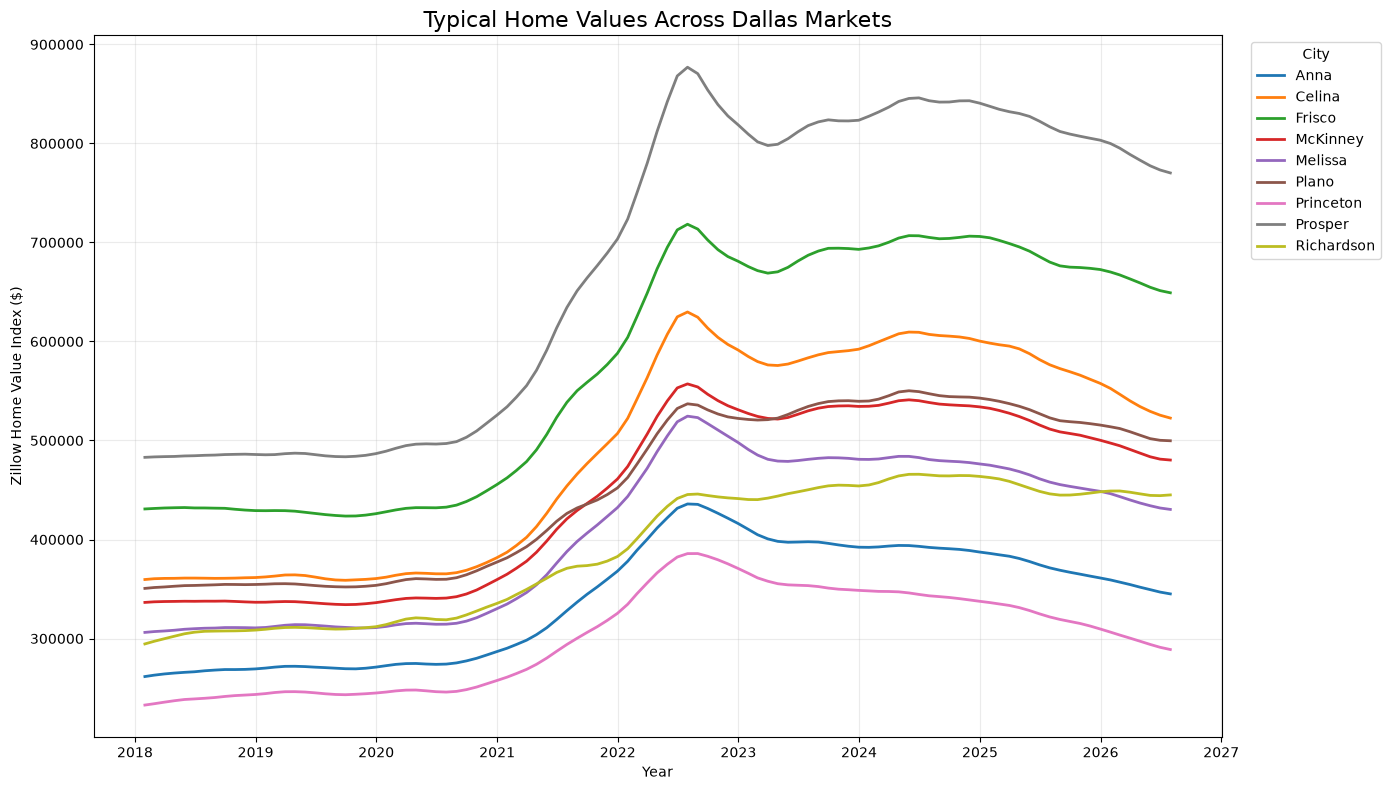

In [5]:
# HISTORICAL ZHVI BY CITY

fig, ax = plt.subplots(figsize=(14, 8))

for city in sorted(df["City"].unique()):
    city_data = df[df["City"] == city]
    ax.plot(
        city_data["Date"],
        city_data["ZHVI"],
        label=city,
        linewidth=2
    )

ax.set_title("Typical Home Values Across Dallas Markets", fontsize=16)
ax.set_xlabel("Year")
ax.set_ylabel("Zillow Home Value Index ($)")

ax.legend(title="City", bbox_to_anchor=(1.02,1), loc="upper left")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 3. Indexed Home-Value Growth

Because the target markets began the study period at substantially different home-value levels, raw dollar values do not provide a fair comparison of proportional appreciation.

Each city's January 2018 ZHVI is normalized to 100.

An index value of:
- 100 = no change from January 2018
- 125 = 25% appreciation
- 150 = 50% appreciation
- 200 = 100% appreciation

In [6]:
# CREATE 2018 = 100 INDEX

df = df.sort_values(["City", "Date"]).copy()

df["Starting_ZHVI"] = (
    df.groupby("City")["ZHVI"].transform("first")
)

df["ZHVI_Index_2018"] = (
    df["ZHVI"] / df["Starting_ZHVI"]
) * 100

df.head()

,City,Date,ZHVI,Year,Month,YearMonth,Starting_ZHVI,ZHVI_Index_2018
0,Anna,2018-01-31,"261,595.26",2018,1,2018-01,"261,595.26",100.00
1,Anna,2018-02-28,"262,998.65",2018,2,2018-02,"261,595.26",100.54
2,Anna,2018-03-31,"264,233.70",2018,3,2018-03,"261,595.26",101.01
3,Anna,2018-04-30,"265,124.49",2018,4,2018-04,"261,595.26",101.35
4,Anna,2018-05-31,"265,856.00",2018,5,2018-05,"261,595.26",101.63


In [7]:
# SANITY CHECK

df.groupby("City").first()[
    ["ZHVI", "Starting_ZHVI", "ZHVI_Index_2018"]
]

,ZHVI,Starting_ZHVI,ZHVI_Index_2018
City,,,
Anna,"261,595.26","261,595.26",100.00
Celina,"359,592.10","359,592.10",100.00
Frisco,"430,859.52","430,859.52",100.00
McKinney,"336,476.43","336,476.43",100.00
Melissa,"306,192.92","306,192.92",100.00
Plano,"350,625.89","350,625.89",100.00
Princeton,"232,811.74","232,811.74",100.00
Prosper,"482,988.47","482,988.47",100.00
Richardson,"294,546.77","294,546.77",100.00


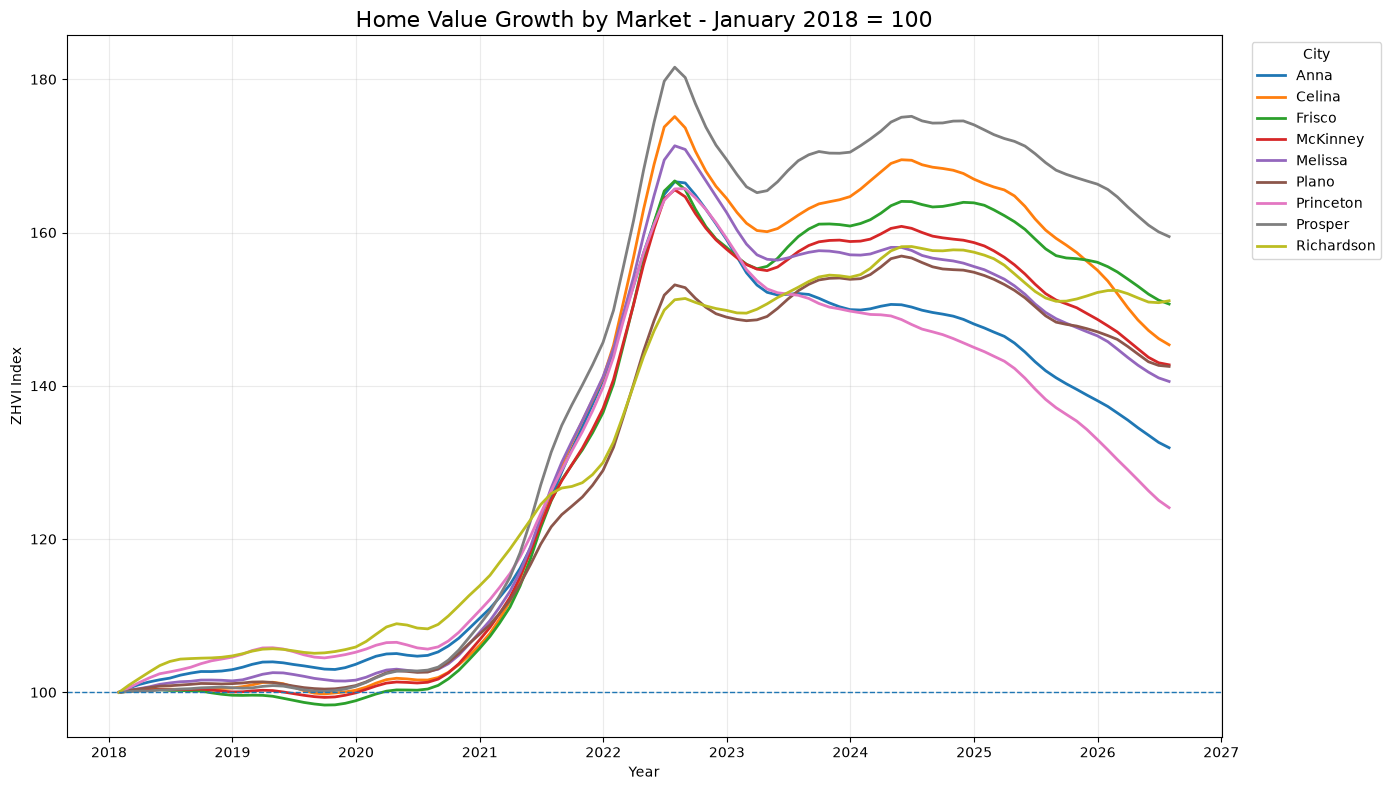

In [8]:
# INDEXED HOME VALUE GROWTH

fix, ax = plt.subplots(figsize = (14,8))

for city in sorted(df["City"].unique()):
    city_data = df[df["City"] == city]

    ax.plot(
        city_data["Date"],
        city_data["ZHVI_Index_2018"],
        label=city,
        linewidth=2
    )

ax.axhline(
    100,
    linestyle="--",
    linewidth=1
)

ax.set_title("Home Value Growth by Market - January 2018 = 100", fontsize=16)
ax.set_xlabel("Year")
ax.set_ylabel("ZHVI Index")

ax.legend(
    title="City",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 4. Cumulative Home-Value Appreciation

The next step measures the total percentage change in ZHVI from the beginning of the study period to the latest available observation.

In [9]:
# STARTING AND LATEST ZHVI

starting_values = (
    df.sort_values("Date")
    .groupby("City", as_index=False)
    .first()
    [["City", "Date", "ZHVI"]]
    .rename(
        columns={
            "Date": "Start_Date",
            "ZHVI": "Start_ZHVI"
        }
    )
)

latest_values = (
    df.sort_values("Date")
    .groupby("City", as_index=False)
    .last()
    [["City", "Date", "ZHVI"]]
    .rename(
        columns={
            "Date": "Latest_Date",
            "ZHVI": "Latest_ZHVI"
        }
    )
)

appreciation_summary = starting_values.merge(
    latest_values,
    on="City"
)

appreciation_summary

,City,Start_Date,Start_ZHVI,Latest_Date,Latest_ZHVI
0,Anna,2018-01-31,"261,595.26",2026-07-31,"345,077.93"
1,Celina,2018-01-31,"359,592.10",2026-07-31,"522,656.82"
2,Frisco,2018-01-31,"430,859.52",2026-07-31,"649,172.68"
3,McKinney,2018-01-31,"336,476.43",2026-07-31,"480,264.85"
4,Melissa,2018-01-31,"306,192.92",2026-07-31,"430,393.87"
5,Plano,2018-01-31,"350,625.89",2026-07-31,"499,723.21"
6,Princeton,2018-01-31,"232,811.74",2026-07-31,"288,891.23"
7,Prosper,2018-01-31,"482,988.47",2026-07-31,"770,217.03"
8,Richardson,2018-01-31,"294,546.77",2026-07-31,"445,039.94"


In [10]:
# TOTAL APPRECIATION

appreciation_summary["Total_Appreciation_Pct"] = (
    (
        appreciation_summary["Latest_ZHVI"]
        / appreciation_summary["Start_ZHVI"]
    ) - 1
) * 100

appreciation_summary = appreciation_summary.sort_values(
    "Total_Appreciation_Pct", 
    ascending=False
)

appreciation_summary[
    [
        "City",
        "Start_ZHVI",
        "Latest_ZHVI",
        "Total_Appreciation_Pct"
    ]
]

,City,Start_ZHVI,Latest_ZHVI,Total_Appreciation_Pct
7,Prosper,"482,988.47","770,217.03",59.47
8,Richardson,"294,546.77","445,039.94",51.09
2,Frisco,"430,859.52","649,172.68",50.67
1,Celina,"359,592.10","522,656.82",45.35
3,McKinney,"336,476.43","480,264.85",42.73
5,Plano,"350,625.89","499,723.21",42.52
4,Melissa,"306,192.92","430,393.87",40.56
0,Anna,"261,595.26","345,077.93",31.91
6,Princeton,"232,811.74","288,891.23",24.09


In [11]:
appreciation_display = appreciation_summary[
    [
        "City",
        "Start_ZHVI",
        "Latest_ZHVI",
        "Total_Appreciation_Pct"
    ]
].copy()

appreciation_display["Start_ZHVI"] = (
    appreciation_display["Start_ZHVI"]
    .map(lambda x: f"${x:,.0f}")
)

appreciation_display["Latest_ZHVI"] = (
    appreciation_display["Latest_ZHVI"]
    .map(lambda x: f"${x:,.0f}")
)

appreciation_display["Total_Appreciation_Pct"] = (
    appreciation_display["Total_Appreciation_Pct"]
    .map(lambda x: f"{x:,.0f}%")
)

appreciation_display

,City,Start_ZHVI,Latest_ZHVI,Total_Appreciation_Pct
7,Prosper,"$482,988","$770,217",59%
8,Richardson,"$294,547","$445,040",51%
2,Frisco,"$430,860","$649,173",51%
1,Celina,"$359,592","$522,657",45%
3,McKinney,"$336,476","$480,265",43%
5,Plano,"$350,626","$499,723",43%
4,Melissa,"$306,193","$430,394",41%
0,Anna,"$261,595","$345,078",32%
6,Princeton,"$232,812","$288,891",24%


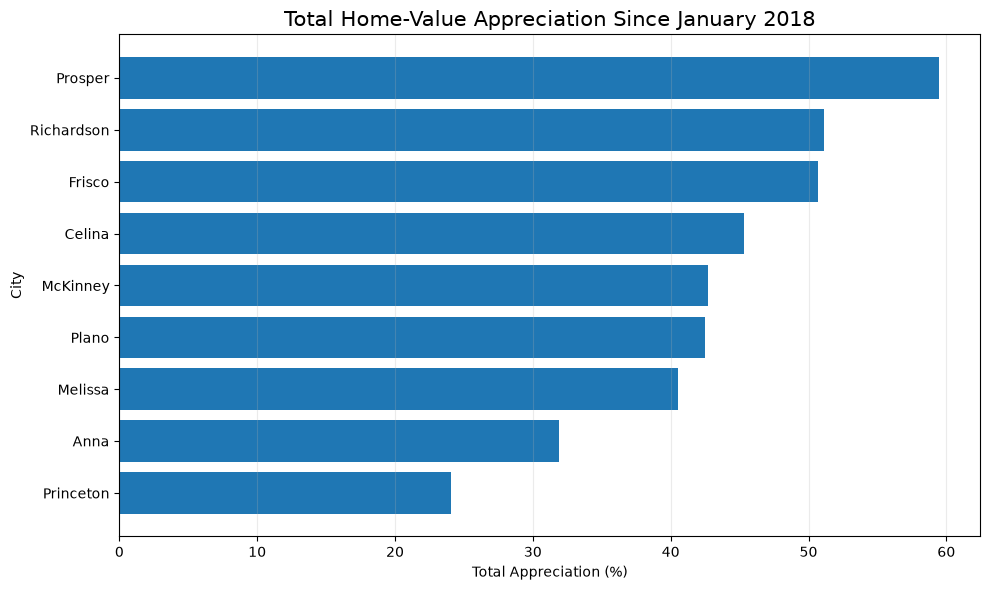

In [12]:
# TOTAL APPRECIATION BAR CHART

plot_data = appreciation_summary.sort_values(
    "Total_Appreciation_Pct"
)

fig, ax = plt.subplots(figsize=(10,6))
ax.barh(
    plot_data["City"],
    plot_data["Total_Appreciation_Pct"]
)

ax.set_title("Total Home-Value Appreciation Since January 2018", fontsize=15)
ax.set_xlabel("Total Appreciation (%)")
ax.set_ylabel("City")

ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

In [13]:
# FULL-PERIOD CAGR

appreciation_summary["Years"] = (
    (
        appreciation_summary["Latest_Date"] - appreciation_summary["Start_Date"]
    ).dt.days / 365.25
)

appreciation_summary["Full_Period_CAGR_Pct"] = (
    (
        appreciation_summary["Latest_ZHVI"] / appreciation_summary["Start_ZHVI"]
    ) ** (1 / appreciation_summary["Years"]) - 1
) * 100

appreciation_summary[
    [
        "City",
        "Years",
        "Total_Appreciation_Pct",
        "Full_Period_CAGR_Pct"
    ]
].sort_values(
    "Full_Period_CAGR_Pct", ascending=False
)

,City,Years,Total_Appreciation_Pct,Full_Period_CAGR_Pct
7,Prosper,8.50,59.47,5.65
8,Richardson,8.50,51.09,4.98
2,Frisco,8.50,50.67,4.94
1,Celina,8.50,45.35,4.50
3,McKinney,8.50,42.73,4.28
5,Plano,8.50,42.52,4.26
4,Melissa,8.50,40.56,4.09
0,Anna,8.50,31.91,3.31
6,Princeton,8.50,24.09,2.57


In [14]:
# YEAR OVER YEAR (YOY) HOME VALUE GROWTH

df["ZHVI_YoY_Pct"] = (
    df.groupby("City")["ZHVI"]
    .pct_change(periods=12)
    * 100
)

df[
    [
        "City",
        "Date",
        "ZHVI",
        "ZHVI_YoY_Pct"
    ]
].tail(20)

,City,Date,ZHVI,ZHVI_YoY_Pct
907,Richardson,2024-12-31,"463,722.99",2.12
908,Richardson,2025-01-31,"462,572.68",1.64
909,Richardson,2025-02-28,"461,197.75",0.81
910,Richardson,2025-03-31,"458,715.35",-0.54
911,Richardson,2025-04-30,"455,386.62",-1.90
912,Richardson,2025-05-31,"451,907.78",-2.99
913,Richardson,2025-06-30,"448,623.26",-3.71
914,Richardson,2025-07-31,"446,104.19",-4.09
915,Richardson,2025-08-31,"444,840.43",-4.19
916,Richardson,2025-09-30,"444,904.62",-4.16


## 5. Recent Price Momentum

Year-over-year ZHVI growth measures whether typical home values are rising or falling relative to the same month one year earlier.

This helps distinguish markets that experienced strong historical appreciation from markets that are still appreciating today.

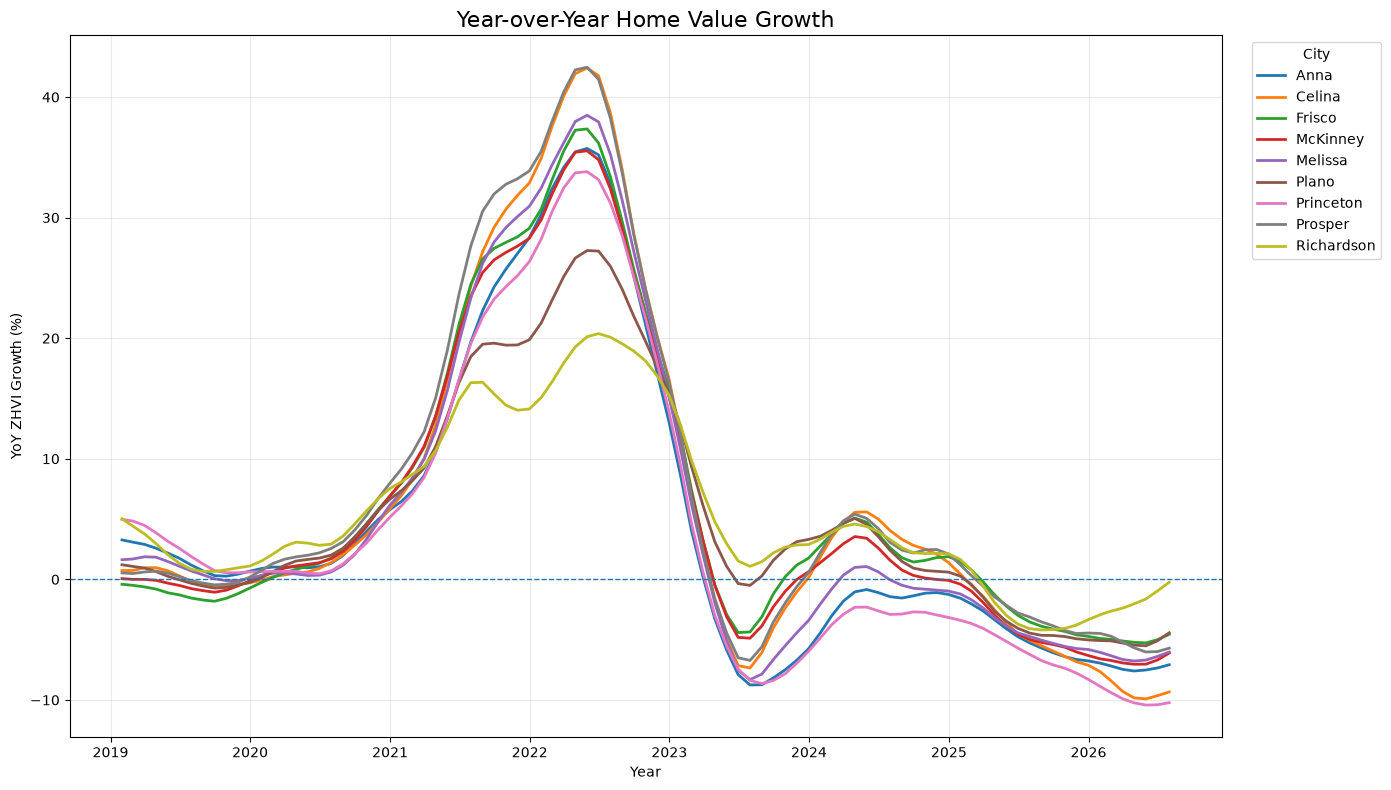

In [15]:
# YEAR-OVER-YEAR ZHVI GROWTH

fig, ax = plt.subplots(figsize=(14,8))

for city in sorted(df["City"].unique()):
    city_data = df[df["City"] == city]

    ax.plot(
        city_data["Date"],
        city_data["ZHVI_YoY_Pct"],
        label=city,
        linewidth=2
    )

ax.axhline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_title("Year-over-Year Home Value Growth", fontsize=16)
ax.set_xlabel("Year")
ax.set_ylabel("YoY ZHVI Growth (%)")

ax.legend(title="City", bbox_to_anchor=(1.02,1), loc="upper left")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [16]:
# LATEST YOY GROWTH BY CITY

latest_yoy = (
    df.dropna(subset=["ZHVI_YoY_Pct"])
    .sort_values("Date")
    .groupby("City", as_index=False)
    .last()
    [["City", "Date", "ZHVI", "ZHVI_YoY_Pct"]]
    .sort_values(
        "ZHVI_YoY_Pct", ascending=False
    )
)

latest_yoy

,City,Date,ZHVI,ZHVI_YoY_Pct
8,Richardson,2026-07-31,"445,039.94",-0.24
5,Plano,2026-07-31,"499,723.21",-4.43
2,Frisco,2026-07-31,"649,172.68",-4.56
7,Prosper,2026-07-31,"770,217.03",-5.71
4,Melissa,2026-07-31,"430,393.87",-6.02
3,McKinney,2026-07-31,"480,264.85",-6.11
0,Anna,2026-07-31,"345,077.93",-7.08
1,Celina,2026-07-31,"522,656.82",-9.34
6,Princeton,2026-07-31,"288,891.23",-10.23


In [17]:
# 3-YEAR CAGR

latest_date = df["Date"].max()
three_yr_target = latest_date - pd.DateOffset(years=3)

three_yr_start = (
    df[df["Date"] <= three_yr_target]
    .sort_values("Date")
    .groupby("City", as_index=False)
    .last()
    [["City", "Date", "ZHVI"]]
    .rename(
        columns={
            "Date": "Three_Yr_Start_Date",
            "ZHVI": "Three_Yr_Start_ZHVI"
        }
    )
)

three_yr_latest = (
    df.sort_values("Date")
    .groupby("City", as_index=False)
    .last()
    [["City", "Date", "ZHVI"]]
    .rename(
        columns={
            "Date": "Latest_Date",
            "ZHVI": "Latest_ZHVI"
        }
    )
)

three_yr_growth = three_yr_start.merge(
    three_yr_latest, on="City"
)

three_yr_growth["Years"] = (
    (
        three_yr_growth["Latest_Date"] 
        - three_yr_growth["Three_Yr_Start_Date"]
    ).dt.days 
    / 365.25
)

three_yr_growth["Three_Yr_CAGR_Pct"] = (
    (
        three_yr_growth["Latest_ZHVI"] / three_yr_growth["Three_Yr_Start_ZHVI"]
    ) ** (1 / three_yr_growth["Years"]) - 1
) * 100

three_yr_growth[
    [
        "City",
        "Three_Yr_CAGR_Pct"
    ]
].sort_values(
    "Three_Yr_CAGR_Pct", ascending=False
)

,City,Three_Yr_CAGR_Pct
8,Richardson,-0.39
2,Frisco,-1.87
7,Prosper,-1.99
5,Plano,-2.21
3,McKinney,-3.23
1,Celina,-3.60
4,Melissa,-3.63
0,Anna,-4.62
6,Princeton,-6.50


In [18]:
# 5-YEAR CAGR

five_yr_target = latest_date - pd.DateOffset(years=5)

five_yr_start = (
    df[df["Date"] <= five_yr_target]
    .sort_values("Date")
    .groupby("City", as_index=False)
    .last()
    [["City", "Date", "ZHVI"]]
    .rename(
        columns={
            "Date": "Five_Yr_Start_Date",
            "ZHVI": "Five_Yr_Start_ZHVI"
        }
    )
)

five_yr_growth = five_yr_start.merge(
    three_yr_latest,
    on="City"
)

five_yr_growth["Years"] = (
    (
        five_yr_growth["Latest_Date"]
        - five_yr_growth["Five_Yr_Start_Date"]
    ).dt.days
    / 365.25
)

five_yr_growth["Five_Yr_CAGR_Pct"] = (
    (
        five_yr_growth["Latest_ZHVI"]
        / five_yr_growth["Five_Yr_Start_ZHVI"]
    )
    ** (1 / five_yr_growth["Years"])
    - 1
) * 100

five_yr_growth[
    [
        "City",
        "Five_Yr_CAGR_Pct"
    ]
].sort_values(
    "Five_Yr_CAGR_Pct",
    ascending=False
)

,City,Five_Yr_CAGR_Pct
7,Prosper,3.96
2,Frisco,3.81
8,Richardson,3.71
5,Plano,3.23
1,Celina,2.85
3,McKinney,2.67
4,Melissa,2.10
0,Anna,1.01
6,Princeton,-0.35


In [19]:
# CONDOLIDATED PRICE PERFORMANCE SUMMARY

price_summary = (
    appreciation_summary[
        [
            "City",
            "Start_ZHVI",
            "Latest_ZHVI",
            "Total_Appreciation_Pct",
            "Full_Period_CAGR_Pct"
        ]
    ]
    .merge(
        three_yr_growth[
            [
                "City",
                "Three_Yr_CAGR_Pct"
            ]
        ],
        on="City"
    )
    .merge(
        five_yr_growth[
            [
                "City",
                "Five_Yr_CAGR_Pct"
            ]
        ],
        on="City"
    )
    .merge(
        latest_yoy[
            [
                "City",
                "ZHVI_YoY_Pct"
            ]
        ],
        on="City"
    )
)

price_summary = price_summary.rename(
    columns={
        "ZHVI_YoY_Pct": "Latest_YoY_Pct"
    }
)

price_summary = price_summary.sort_values("Total_Appreciation_Pct", ascending=False)
price_summary

,City,Start_ZHVI,Latest_ZHVI,Total_Appreciation_Pct,Full_Period_CAGR_Pct,Three_Yr_CAGR_Pct,Five_Yr_CAGR_Pct,Latest_YoY_Pct
0,Prosper,"482,988.47","770,217.03",59.47,5.65,-1.99,3.96,-5.71
1,Richardson,"294,546.77","445,039.94",51.09,4.98,-0.39,3.71,-0.24
2,Frisco,"430,859.52","649,172.68",50.67,4.94,-1.87,3.81,-4.56
3,Celina,"359,592.10","522,656.82",45.35,4.50,-3.60,2.85,-9.34
4,McKinney,"336,476.43","480,264.85",42.73,4.28,-3.23,2.67,-6.11
5,Plano,"350,625.89","499,723.21",42.52,4.26,-2.21,3.23,-4.43
6,Melissa,"306,192.92","430,393.87",40.56,4.09,-3.63,2.10,-6.02
7,Anna,"261,595.26","345,077.93",31.91,3.31,-4.62,1.01,-7.08
8,Princeton,"232,811.74","288,891.23",24.09,2.57,-6.50,-0.35,-10.23


In [20]:
# PRICE MOMENTUM CHANGE

price_summary["Momentum_vs_3yr"] = (
    price_summary["Latest_YoY_Pct"] - price_summary["Three_Yr_CAGR_Pct"]
)

price_summary[
    [
        "City",
        "Latest_YoY_Pct",
        "Three_Yr_CAGR_Pct",
        "Momentum_vs_3yr"
    ]
].sort_values(
    "Momentum_vs_3yr", ascending=False
)

,City,Latest_YoY_Pct,Three_Yr_CAGR_Pct,Momentum_vs_3yr
1,Richardson,-0.24,-0.39,0.15
5,Plano,-4.43,-2.21,-2.22
6,Melissa,-6.02,-3.63,-2.39
7,Anna,-7.08,-4.62,-2.46
2,Frisco,-4.56,-1.87,-2.69
4,McKinney,-6.11,-3.23,-2.89
0,Prosper,-5.71,-1.99,-3.72
8,Princeton,-10.23,-6.50,-3.73
3,Celina,-9.34,-3.60,-5.73


In [21]:
# PRICE MOMENTUM CLASSIFICATION

def classify_price_momentum(row):
    yoy = row["Latest_YoY_Pct"]
    momentum = row["Momentum_vs_3yr"]

    if yoy > 3 and momentum > 0:
        return "Strong / Accelerating"

    elif yoy > 0 and momentum > 0:
        return "Positive / Accelerating"

    elif yoy > 0 and momentum <= 0:
        return "Positive / Slowing"

    elif yoy <= 0 and momentum > 0:
        return "Declining / Improving"

    else:
        return "Declining / Weakening"

price_summary["Price_Momentum"] = price_summary.apply(
    classify_price_momentum, axis=1
)

price_summary[
    [
        "City",
        "Latest_YoY_Pct",
        "Three_Yr_CAGR_Pct",
        "Momentum_vs_3yr",
        "Price_Momentum"
    ]
].sort_values(
    "Latest_YoY_Pct", ascending=False
)

,City,Latest_YoY_Pct,Three_Yr_CAGR_Pct,Momentum_vs_3yr,Price_Momentum
1,Richardson,-0.24,-0.39,0.15,Declining / Improving
5,Plano,-4.43,-2.21,-2.22,Declining / Weakening
2,Frisco,-4.56,-1.87,-2.69,Declining / Weakening
0,Prosper,-5.71,-1.99,-3.72,Declining / Weakening
6,Melissa,-6.02,-3.63,-2.39,Declining / Weakening
4,McKinney,-6.11,-3.23,-2.89,Declining / Weakening
7,Anna,-7.08,-4.62,-2.46,Declining / Weakening
3,Celina,-9.34,-3.60,-5.73,Declining / Weakening
8,Princeton,-10.23,-6.50,-3.73,Declining / Weakening


In [22]:
# CURRENT PRICE TREND SEVERITY

def classify_price_trend(yoy):
    if yoy >= 5:
        return "Strong Growth"
    elif yoy >= 2:
        return "Moderate Growth"
    elif yoy >= 0:
        return "Stable / Slight Growth"
    elif yoy >= -5:
        return "Moderate Decline"
    elif yoy >= -10:
        return "Significant Decline"
    else:
        return "Severe Decline"

price_summary["Current_Price_Trend"] = (
    price_summary["Latest_YoY_Pct"].apply(classify_price_trend)
)

price_summary[
    [
        "City",
        "Latest_YoY_Pct",
        "Current_Price_Trend"
    ]
].sort_values(
    "Latest_YoY_Pct", ascending=False
)

,City,Latest_YoY_Pct,Current_Price_Trend
1,Richardson,-0.24,Moderate Decline
5,Plano,-4.43,Moderate Decline
2,Frisco,-4.56,Moderate Decline
0,Prosper,-5.71,Significant Decline
6,Melissa,-6.02,Significant Decline
4,McKinney,-6.11,Significant Decline
7,Anna,-7.08,Significant Decline
3,Celina,-9.34,Significant Decline
8,Princeton,-10.23,Severe Decline


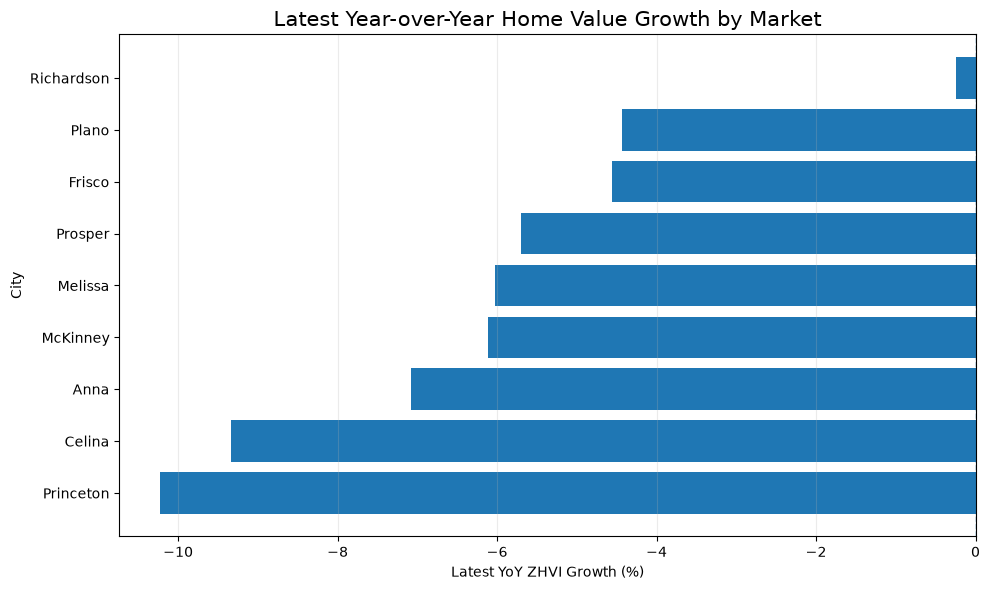

In [23]:
# LATEST YOY HOME VALUE GROWTH BY CITY

plot_data = price_summary.sort_values(
    "Latest_YoY_Pct"
)

fig, ax = plt.subplots(figsize=(10,6))

ax.barh(
    plot_data["City"], plot_data["Latest_YoY_Pct"]
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_title("Latest Year-over-Year Home Value Growth by Market", fontsize=15)
ax.set_xlabel("Latest YoY ZHVI Growth (%)")
ax.set_ylabel("City")

ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

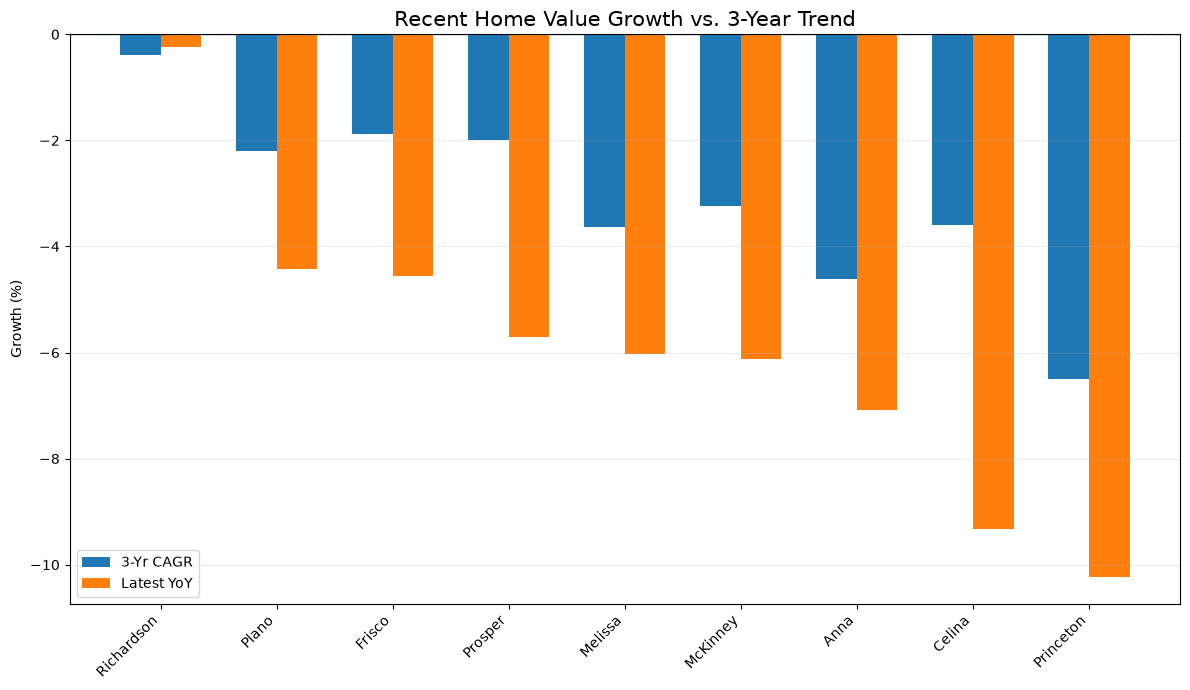

In [24]:
# CURRENT GROWTH VS. 3-YEAR CAGR

comparison = price_summary[
    [
        "City", 
        "Latest_YoY_Pct",
        "Three_Yr_CAGR_Pct"
    ]
].copy()

comparison = comparison.sort_values("Latest_YoY_Pct", ascending=False)

x = np.arange(len(comparison))
width = 0.35

fig, ax = plt.subplots(figsize=(12,7))

ax.bar(
    x - width / 2,
    comparison["Three_Yr_CAGR_Pct"], width, label="3-Yr CAGR"
)

ax.bar(
    x + width / 2,
    comparison["Latest_YoY_Pct"], width, label="Latest YoY"
)

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(
    comparison["City"], rotation=45, ha="right"
)

ax.set_title("Recent Home Value Growth vs. 3-Year Trend", fontsize=15)
ax.set_ylabel("Growth (%)")
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

In [25]:
# PEAK ZHVI ANALYSIS

peak_summary = (
    df.loc[
        df.groupby("City")["ZHVI"].idxmax(),
        ["City", "Date", "ZHVI"]
    ]
    .rename(
        columns={
            "Date": "Peak_Date",
            "ZHVI": "Peak_ZHVI"
        }
    )
)

peak_summary = peak_summary.merge(
    latest_values[
        [
            "City",
            "Latest_Date",
            "Latest_ZHVI"
        ]
    ],
    on="City"
)

peak_summary["Change_From_Peak_Pct"] = (
    (
        peak_summary["Latest_ZHVI"] / peak_summary["Peak_ZHVI"]
    ) - 1
) * 100

peak_summary.sort_values("Change_From_Peak_Pct")

,City,Peak_Date,Peak_ZHVI,Latest_Date,Latest_ZHVI,Change_From_Peak_Pct
6,Princeton,2022-08-31,"385,817.37",2026-07-31,"288,891.23",-25.12
0,Anna,2022-07-31,"435,906.92",2026-07-31,"345,077.93",-20.84
4,Melissa,2022-07-31,"524,567.99",2026-07-31,"430,393.87",-17.95
1,Celina,2022-07-31,"629,785.63",2026-07-31,"522,656.82",-17.01
3,McKinney,2022-07-31,"557,158.82",2026-07-31,"480,264.85",-13.80
7,Prosper,2022-07-31,"876,976.00",2026-07-31,"770,217.03",-12.17
2,Frisco,2022-07-31,"718,394.35",2026-07-31,"649,172.68",-9.64
5,Plano,2024-05-31,"550,232.57",2026-07-31,"499,723.21",-9.18
8,Richardson,2024-06-30,"465,892.56",2026-07-31,"445,039.94",-4.48


In [26]:
# MONTHS SINCE PEAK

peak_summary["Months_Since_Peak"] = (
    (
        peak_summary["Latest_Date"].dt.year - peak_summary["Peak_Date"].dt.year
    ) * 12
    +
    (
        peak_summary["Latest_Date"].dt.month - peak_summary["Peak_Date"].dt.month
    )
)

peak_summary[
    [
        "City", 
        "Peak_Date",
        "Peak_ZHVI",
        "Latest_ZHVI",
        "Change_From_Peak_Pct",
        "Months_Since_Peak"
    ]
].sort_values("Change_From_Peak_Pct")

,City,Peak_Date,Peak_ZHVI,Latest_ZHVI,Change_From_Peak_Pct,Months_Since_Peak
6,Princeton,2022-08-31,"385,817.37","288,891.23",-25.12,47
0,Anna,2022-07-31,"435,906.92","345,077.93",-20.84,48
4,Melissa,2022-07-31,"524,567.99","430,393.87",-17.95,48
1,Celina,2022-07-31,"629,785.63","522,656.82",-17.01,48
3,McKinney,2022-07-31,"557,158.82","480,264.85",-13.80,48
7,Prosper,2022-07-31,"876,976.00","770,217.03",-12.17,48
2,Frisco,2022-07-31,"718,394.35","649,172.68",-9.64,48
5,Plano,2024-05-31,"550,232.57","499,723.21",-9.18,26
8,Richardson,2024-06-30,"465,892.56","445,039.94",-4.48,25


In [27]:
# ADD PEAK METRICS TO PRICE SUMMARY 

price_summary = price_summary.merge(
    peak_summary[
        [
            "City",
            "Peak_Date",
            "Peak_ZHVI",
            "Change_From_Peak_Pct",
            "Months_Since_Peak"
        ]
    ],
    on="City", how="left"
)

price_summary

,City,Start_ZHVI,Latest_ZHVI,Total_Appreciation_Pct,Full_Period_CAGR_Pct,Three_Yr_CAGR_Pct,Five_Yr_CAGR_Pct,Latest_YoY_Pct,Momentum_vs_3yr,Price_Momentum,Current_Price_Trend,Peak_Date,Peak_ZHVI,Change_From_Peak_Pct,Months_Since_Peak
0,Prosper,"482,988.47","770,217.03",59.47,5.65,-1.99,3.96,-5.71,-3.72,Declining / Weakening,Significant Decline,2022-07-31,"876,976.00",-12.17,48
1,Richardson,"294,546.77","445,039.94",51.09,4.98,-0.39,3.71,-0.24,0.15,Declining / Improving,Moderate Decline,2024-06-30,"465,892.56",-4.48,25
2,Frisco,"430,859.52","649,172.68",50.67,4.94,-1.87,3.81,-4.56,-2.69,Declining / Weakening,Moderate Decline,2022-07-31,"718,394.35",-9.64,48
3,Celina,"359,592.10","522,656.82",45.35,4.50,-3.60,2.85,-9.34,-5.73,Declining / Weakening,Significant Decline,2022-07-31,"629,785.63",-17.01,48
4,McKinney,"336,476.43","480,264.85",42.73,4.28,-3.23,2.67,-6.11,-2.89,Declining / Weakening,Significant Decline,2022-07-31,"557,158.82",-13.80,48
5,Plano,"350,625.89","499,723.21",42.52,4.26,-2.21,3.23,-4.43,-2.22,Declining / Weakening,Moderate Decline,2024-05-31,"550,232.57",-9.18,26
6,Melissa,"306,192.92","430,393.87",40.56,4.09,-3.63,2.10,-6.02,-2.39,Declining / Weakening,Significant Decline,2022-07-31,"524,567.99",-17.95,48
7,Anna,"261,595.26","345,077.93",31.91,3.31,-4.62,1.01,-7.08,-2.46,Declining / Weakening,Significant Decline,2022-07-31,"435,906.92",-20.84,48
8,Princeton,"232,811.74","288,891.23",24.09,2.57,-6.50,-0.35,-10.23,-3.73,Declining / Weakening,Severe Decline,2022-08-31,"385,817.37",-25.12,47


In [28]:
# FINAL PRICE TREND SUMMARY

final_price_summary = price_summary[
    [
        "City",
        "Start_ZHVI",
        "Latest_ZHVI",
        "Total_Appreciation_Pct",
        "Five_Yr_CAGR_Pct",
        "Three_Yr_CAGR_Pct",
        "Latest_YoY_Pct",
        "Momentum_vs_3yr",
        "Change_From_Peak_Pct",
        "Months_Since_Peak",
        "Current_Price_Trend"
    ]
].sort_values("Latest_YoY_Pct", ascending=False)

final_price_summary.round(2)

,City,Start_ZHVI,Latest_ZHVI,Total_Appreciation_Pct,Five_Yr_CAGR_Pct,Three_Yr_CAGR_Pct,Latest_YoY_Pct,Momentum_vs_3yr,Change_From_Peak_Pct,Months_Since_Peak,Current_Price_Trend
1,Richardson,"294,546.77","445,039.94",51.09,3.71,-0.39,-0.24,0.15,-4.48,25,Moderate Decline
5,Plano,"350,625.89","499,723.21",42.52,3.23,-2.21,-4.43,-2.22,-9.18,26,Moderate Decline
2,Frisco,"430,859.52","649,172.68",50.67,3.81,-1.87,-4.56,-2.69,-9.64,48,Moderate Decline
0,Prosper,"482,988.47","770,217.03",59.47,3.96,-1.99,-5.71,-3.72,-12.17,48,Significant Decline
6,Melissa,"306,192.92","430,393.87",40.56,2.10,-3.63,-6.02,-2.39,-17.95,48,Significant Decline
4,McKinney,"336,476.43","480,264.85",42.73,2.67,-3.23,-6.11,-2.89,-13.80,48,Significant Decline
7,Anna,"261,595.26","345,077.93",31.91,1.01,-4.62,-7.08,-2.46,-20.84,48,Significant Decline
3,Celina,"359,592.10","522,656.82",45.35,2.85,-3.60,-9.34,-5.73,-17.01,48,Significant Decline
8,Princeton,"232,811.74","288,891.23",24.09,-0.35,-6.50,-10.23,-3.73,-25.12,47,Severe Decline


## Price Trend Interpretation

All 9 target markets are currently experiencing weaker home-value performance than their recent historical trends. Richardson, Plano, and Frisco show the most resilience, with the smallest declines from peak values and the mildest current year-over-year declines. Celina, Anna, Melissa, and Princeton show substantially deeper differences. Princeton has experienced the largest decline from peak value at approximately 25%, while Celina shows the sharpest deterioration in recent momentum relative to its three-year trend. These results indicate broad price-market cooling across North Dallas. However, price trends alone cannot determine whether a city is fundamentatlly weakening. Transaction activity, inventory, population growth, and residential construction must be incorportaed before evaluating overall market strength.

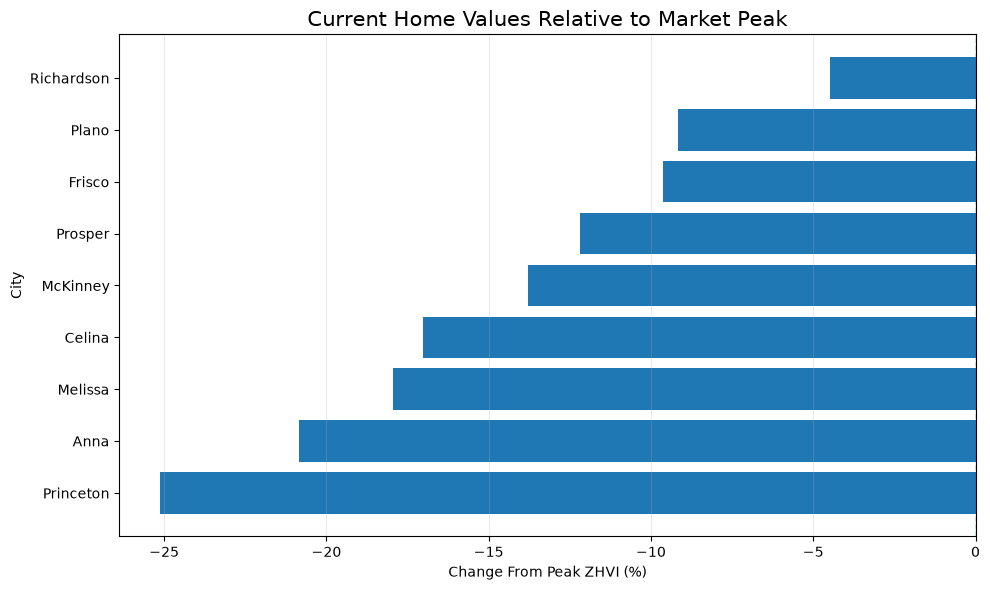

In [29]:
# CHANGE FROM PEAK ZHVI BY CITY

plot_data = final_price_summary.sort_values("Change_From_Peak_Pct")

fig, ax = plt.subplots(figsize=(10,6))

ax.barh(
    plot_data["City"], 
    plot_data["Change_From_Peak_Pct"]
)

ax.axvline(0, linestyle="--", linewidth=1)

ax.set_title("Current Home Values Relative to Market Peak", fontsize=15)
ax.set_xlabel("Change From Peak ZHVI (%)")
ax.set_ylabel("City")

ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

# Transaction Activity Analysis

## 6. Housing Transaction Activity

Home-value appreciation alone does not indicate whether a housing market is strengthening or weakening. This section evaluates actual housing-market activity to determine whether buyer demand and transaction volume is expanding or contracting across the target markets.

Key indicators include:
- Number of homes sold
- Year-over-year sales growth
- Annual transaction volume
- Change in transaction volume from peak levels
- Median sale price
- Days on market
- Housing inventory
- Months of supply

These indicators complement Zillow home-value trends by measuring the underlying level of market activity.

In [30]:
# REDFIN FILE PATH

REDFIN_FILE = (RAW_DATA_DIR / "redfin_housing_market_monthly_all_cities_2018_Jan_to_2026_Jul.csv")

print("Redfin file:", REDFIN_FILE)
print("File exists:", REDFIN_FILE.exists())

Redfin file: /Users/ninahuang/Downloads/Personal/Projects/TX Market Analysis/tx_market_analysis/data/raw/redfin_housing_market_monthly_all_cities_2018_Jan_to_2026_Jul.csv
File exists: True


In [31]:
# LOAD RAW REDFIN DATA

redfin_raw = pd.read_csv(REDFIN_FILE)
print("Dataset shape:", redfin_raw.shape)
redfin_raw.head()

Dataset shape: (2667667, 21)


,LAST UPDATED,FREQUENCY,PERIOD BEGIN,PERIOD END,REGION ID,REGION TYPE,REGION NAME,HOMES SOLD,MEDIAN SALE PRICE NSA ($),MEDIAN DAYS ON MARKET (DAYS),AVERAGE SALE TO LIST RATIO (%),SHARE SOLD ABOVE ORIGINAL LIST (%),NEW LISTINGS,ACTIVE LISTINGS,INVENTORY,PENDING SALES,MEDIAN NEW LISTING PRICE ($),MEDIAN NEW LISTING PRICE PER SQ.FT. ($),MEDIAN SALE PRICE PER SQ.FT. ($),MONTHS OF SUPPLY,PERCENT OFF MARKET IN TWO WEEKS (%)
0,2026-08-03,Rolling 3 Months,2026-05-01,2026-07-31,31349,City,"Aaronsburg, PA",NaN,NaN,NaN,NaN,NaN,NaN,1.00,1.00,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-08-03,Rolling 3 Months,2026-05-01,2026-07-31,21117,City,"Aaronsburg, PA",1.00,"259,870.00",154.00,94.54,0.00,NaN,1.00,1.00,NaN,NaN,NaN,116.04,3.20,NaN
2,2026-08-03,Rolling 3 Months,2026-05-01,2026-07-31,18,City,"Abbeville, AL",7.00,"212,893.00",95.00,96.00,0.00,10.00,16.00,12.00,9.00,"231,273.00",116.79,111.60,5.00,21.99
3,2026-08-03,Rolling 3 Months,2026-05-01,2026-07-31,29,City,"Abbeville, GA",NaN,NaN,NaN,NaN,NaN,1.00,4.00,3.00,1.00,"133,712.00",111.31,NaN,NaN,0.00
4,2026-08-03,Rolling 3 Months,2026-05-01,2026-07-31,3,City,"Abbeville, LA",16.00,"70,964.00",129.00,89.73,0.00,21.00,56.00,33.00,21.00,"89,141.00",64.29,59.43,6.20,4.71


In [32]:
# INSPECT REDFIN COLUMNS

print("Number of columns:", len(redfin_raw.columns))

for col in redfin_raw.columns:
    print(col)

Number of columns: 21
LAST UPDATED
FREQUENCY
PERIOD BEGIN
PERIOD END
REGION ID
REGION TYPE
REGION NAME
HOMES SOLD
MEDIAN SALE PRICE NSA ($)
MEDIAN DAYS ON MARKET (DAYS)
AVERAGE SALE TO LIST RATIO (%)
SHARE SOLD ABOVE ORIGINAL LIST (%)
NEW LISTINGS
ACTIVE LISTINGS
INVENTORY
PENDING SALES
MEDIAN NEW LISTING PRICE ($)
MEDIAN NEW LISTING PRICE PER SQ.FT. ($)
MEDIAN SALE PRICE PER SQ.FT. ($)
MONTHS OF SUPPLY
PERCENT OFF MARKET IN TWO WEEKS (%)


In [33]:
# DEFINE TARGET REDFIN REGIONS

TARGET_REDFIN_REGIONS = [
    "Anna, TX",
    "Celina, TX",
    "Frisco, TX",
    "McKinney, TX",
    "Melissa, TX",
    "Plano, TX",
    "Princeton, TX",
    "Prosper, TX",
    "Richardson, TX",
]

redfin_target = redfin_raw[
    redfin_raw["REGION NAME"].isin(TARGET_REDFIN_REGIONS)
].copy()

print("Rows found:", len(redfin_target))
print("Regions found:")

for region in sorted(redfin_target["REGION NAME"].unique()):
    print("-", region)

Rows found: 909
Regions found:
- Anna, TX
- Celina, TX
- Frisco, TX
- McKinney, TX
- Melissa, TX
- Plano, TX
- Princeton, TX
- Prosper, TX
- Richardson, TX


In [34]:
# VALIDATE REDFIN CITY COVERAGE

regions_found = set(redfin_target["REGION NAME"].unique())
regions_missing = sorted(set(TARGET_REDFIN_REGIONS) - regions_found)

print("Target regions:", len(TARGET_REDFIN_REGIONS))
print("Regions found:", len(regions_found))
print("\nMissing regions:")

if regions_missing:
    for region in regions_missing:
        print("-", region)
else:
    print("None")

Target regions: 9
Regions found: 9

Missing regions:
None


In [35]:
# CHECK REDFIN DATA GRAIN

duplicate_count = redfin_target.duplicated(
    subset=["REGION NAME", "PERIOD END"]
).sum()

print("Duplicate region-period rows:", duplicate_count)

redfin_target.groupby("REGION NAME").size().sort_values()

Duplicate region-period rows: 0


REGION NAME
Anna, TX          101
Celina, TX        101
Frisco, TX        101
McKinney, TX      101
Melissa, TX       101
Plano, TX         101
Princeton, TX     101
Prosper, TX       101
Richardson, TX    101
dtype: int64

In [36]:
# REDFIN DATA COVERAGE BY CITY

redfin_coverage = (
    redfin_target
    .groupby("REGION NAME")
    .agg(
        First_Period=("PERIOD END", "min"),
        Last_Period=("PERIOD END", "max"),
        Observations=("PERIOD END", "count")
    )
    .reset_index()
    .sort_values("REGION NAME")
)

redfin_coverage

,REGION NAME,First_Period,Last_Period,Observations
0,"Anna, TX",2018-03-31,2026-07-31,101
1,"Celina, TX",2018-03-31,2026-07-31,101
2,"Frisco, TX",2018-03-31,2026-07-31,101
3,"McKinney, TX",2018-03-31,2026-07-31,101
4,"Melissa, TX",2018-03-31,2026-07-31,101
5,"Plano, TX",2018-03-31,2026-07-31,101
6,"Princeton, TX",2018-03-31,2026-07-31,101
7,"Prosper, TX",2018-03-31,2026-07-31,101
8,"Richardson, TX",2018-03-31,2026-07-31,101


In [37]:
# SELECT AND RENAME REDFIN VARIABLES

redfin_clean = redfin_target[
    [
        "REGION NAME",
		"PERIOD BEGIN",
        "PERIOD END",
        "HOMES SOLD",
        "MEDIAN SALE PRICE NSA ($)",
        "MEDIAN DAYS ON MARKET (DAYS)",
        "AVERAGE SALE TO LIST RATIO (%)",
        "SHARE SOLD ABOVE ORIGINAL LIST (%)",
        "NEW LISTINGS",
        "ACTIVE LISTINGS",
        "INVENTORY",
        "PENDING SALES",
        "MEDIAN SALE PRICE PER SQ.FT. ($)",
        "MONTHS OF SUPPLY",
        "PERCENT OFF MARKET IN TWO WEEKS (%)"
    ]
].copy()

redfin_clean = redfin_clean.rename(
    columns={
        "REGION NAME": "Region",
        "PERIOD BEGIN": "Period_Begin",
        "PERIOD END": "Date",
        "HOMES SOLD": "Homes_Sold",
        "MEDIAN SALE PRICE NSA ($)": "Median_Sale_Price",
        "MEDIAN DAYS ON MARKET (DAYS)": "Median_DOM",
        "AVERAGE SALE TO LIST RATIO (%)": "Sale_to_List_Pct",
        "SHARE SOLD ABOVE ORIGINAL LIST (%)": "Share_Sold_Above_List_Pct",
        "NEW LISTINGS": "New_Listings",
        "ACTIVE LISTINGS": "Active_Listings",
        "INVENTORY": "Inventory",
        "PENDING SALES": "Pending_Sales",
        "MEDIAN SALE PRICE PER SQ.FT. ($)": "Median_Sale_Price_Per_SqFt",
        "MONTHS OF SUPPLY": "Months_of_Supply",
        "PERCENT OFF MARKET IN TWO WEEKS (%)": "Pct_Off_Market_2_Weeks"
    }
)

redfin_clean.head()

,Region,Period_Begin,Date,Homes_Sold,Median_Sale_Price,Median_DOM,Sale_to_List_Pct,Share_Sold_Above_List_Pct,New_Listings,Active_Listings,Inventory,Pending_Sales,Median_Sale_Price_Per_SqFt,Months_of_Supply,Pct_Off_Market_2_Weeks
586,"Anna, TX",2026-05-01,2026-07-31,210.00,"350,814.00",76.00,97.73,2.93,314.00,663.00,402.00,216.00,163.27,5.90,12.43
3980,"Celina, TX",2026-05-01,2026-07-31,281.00,"509,745.00",83.00,96.50,3.64,468.00,988.00,626.00,297.00,185.79,6.80,11.41
8712,"Frisco, TX",2026-05-01,2026-07-31,730.00,"674,662.00",50.00,97.29,8.14,"1,118.00","2,102.00","1,158.00",706.00,230.03,4.90,23.29
15171,"McKinney, TX",2026-05-01,2026-07-31,796.00,"510,744.00",45.00,97.76,10.94,"1,081.00","2,018.00","1,054.00",796.00,211.31,4.10,25.40
15305,"Melissa, TX",2026-05-01,2026-07-31,105.00,"449,774.00",60.00,97.90,12.64,159.00,316.00,178.00,95.00,181.60,5.20,16.84


In [38]:
# CREATE CITY VARIABLE

redfin_clean["City"] = (
    redfin_clean["Region"].str.replace(", TX", "", regex=False)
)

redfin_clean[
    ["Region", "City"]
].drop_duplicates().sort_values("City")

,Region,City
586,"Anna, TX",Anna
3980,"Celina, TX",Celina
8712,"Frisco, TX",Frisco
15171,"McKinney, TX",McKinney
15305,"Melissa, TX",Melissa
19264,"Plano, TX",Plano
19798,"Princeton, TX",Princeton
19837,"Prosper, TX",Prosper
20372,"Richardson, TX",Richardson


In [39]:
# CREATE TIME VARIABLES

redfin_clean["Date"] = pd.to_datetime(redfin_clean["Date"])
redfin_clean["Year"] = redfin_clean["Date"].dt.year
redfin_clean["Month"] = redfin_clean["Date"].dt.month

redfin_clean["YearMonth"] = (
    redfin_clean["Date"]
    .dt.to_period("M")
    .astype(str)
)

redfin_clean = (
    redfin_clean
    .sort_values(["City", "Date"])
    .reset_index(drop=True)
)

redfin_clean.head()

,Region,Period_Begin,Date,Homes_Sold,Median_Sale_Price,Median_DOM,Sale_to_List_Pct,Share_Sold_Above_List_Pct,New_Listings,Active_Listings,Inventory,Pending_Sales,Median_Sale_Price_Per_SqFt,Months_of_Supply,Pct_Off_Market_2_Weeks,City,Year,Month,YearMonth
0,"Anna, TX",2018-01-01,2018-03-31,129.00,"233,490.00",39.00,98.62,16.28,158.00,259.00,102.00,167.00,121.70,2.40,36.53,Anna,2018,3,2018-03
1,"Anna, TX",2018-02-01,2018-04-30,145.00,"236,000.00",42.00,98.75,14.48,179.00,272.00,101.00,183.00,123.13,2.10,39.89,Anna,2018,4,2018-04
2,"Anna, TX",2018-03-01,2018-05-31,169.00,"235,900.00",36.00,98.85,18.34,179.00,279.00,92.00,194.00,123.13,1.70,42.78,Anna,2018,5,2018-05
3,"Anna, TX",2018-04-01,2018-06-30,173.00,"234,900.00",36.00,99.11,21.39,190.00,288.00,116.00,185.00,123.13,2.00,43.24,Anna,2018,6,2018-06
4,"Anna, TX",2018-05-01,2018-07-31,168.00,"234,145.00",34.00,99.09,26.79,195.00,293.00,128.00,167.00,122.72,2.30,45.51,Anna,2018,7,2018-07


In [40]:
# MISSING VALUE SUMMARY

analysis_columns = [
    "Homes_Sold",
    "Median_Sale_Price",
    "Median_DOM",
    "Sale_to_List_Pct",
    "New_Listings",
    "Active_Listings",
    "Inventory",
    "Pending_Sales",
    "Median_Sale_Price_Per_SqFt",
    "Months_of_Supply",
    "Pct_Off_Market_2_Weeks"
]

missing_summary = (
    redfin_clean[analysis_columns]
    .isna()
    .sum()
    .to_frame("Missing")
)

missing_summary["Missing_Pct"] = (
    missing_summary["Missing"] / len(redfin_clean) * 100
)

missing_summary.round(2)

,Missing,Missing_Pct
Homes_Sold,0,0.00
Median_Sale_Price,0,0.00
Median_DOM,0,0.00
Sale_to_List_Pct,0,0.00
New_Listings,0,0.00
Active_Listings,0,0.00
Inventory,0,0.00
Pending_Sales,0,0.00
Median_Sale_Price_Per_SqFt,0,0.00
Months_of_Supply,0,0.00


In [41]:
# HOMES SOLD COERAGE BY CITY

sales_coverage = (
    redfin_clean
    .groupby("City")["Homes_Sold"]
    .agg(
        Total_Periods="size",
        Available_Periods="count",
        Missing_Periods=lambda x: x.isna().sum()
    )
)

sales_coverage["Coverage_Pct"] = (
    sales_coverage["Available_Periods"] / sales_coverage["Total_Periods"] * 100
)

sales_coverage.round(1)

,Total_Periods,Available_Periods,Missing_Periods,Coverage_Pct
City,,,,
Anna,101,101,0,100.00
Celina,101,101,0,100.00
Frisco,101,101,0,100.00
McKinney,101,101,0,100.00
Melissa,101,101,0,100.00
Plano,101,101,0,100.00
Princeton,101,101,0,100.00
Prosper,101,101,0,100.00
Richardson,101,101,0,100.00


## Rolling Transaction Activity

The Redfin dataset reports housing activity using rolling three-month periods. Therefore, each observation represents activity across an overlapping three-month window, rather than an independent calendar month.

For this reason, `Homes Sold` observations are used to evaluate transaction trends and year-over-year changes but are **not summed across months to estimate annual transaction totals.**

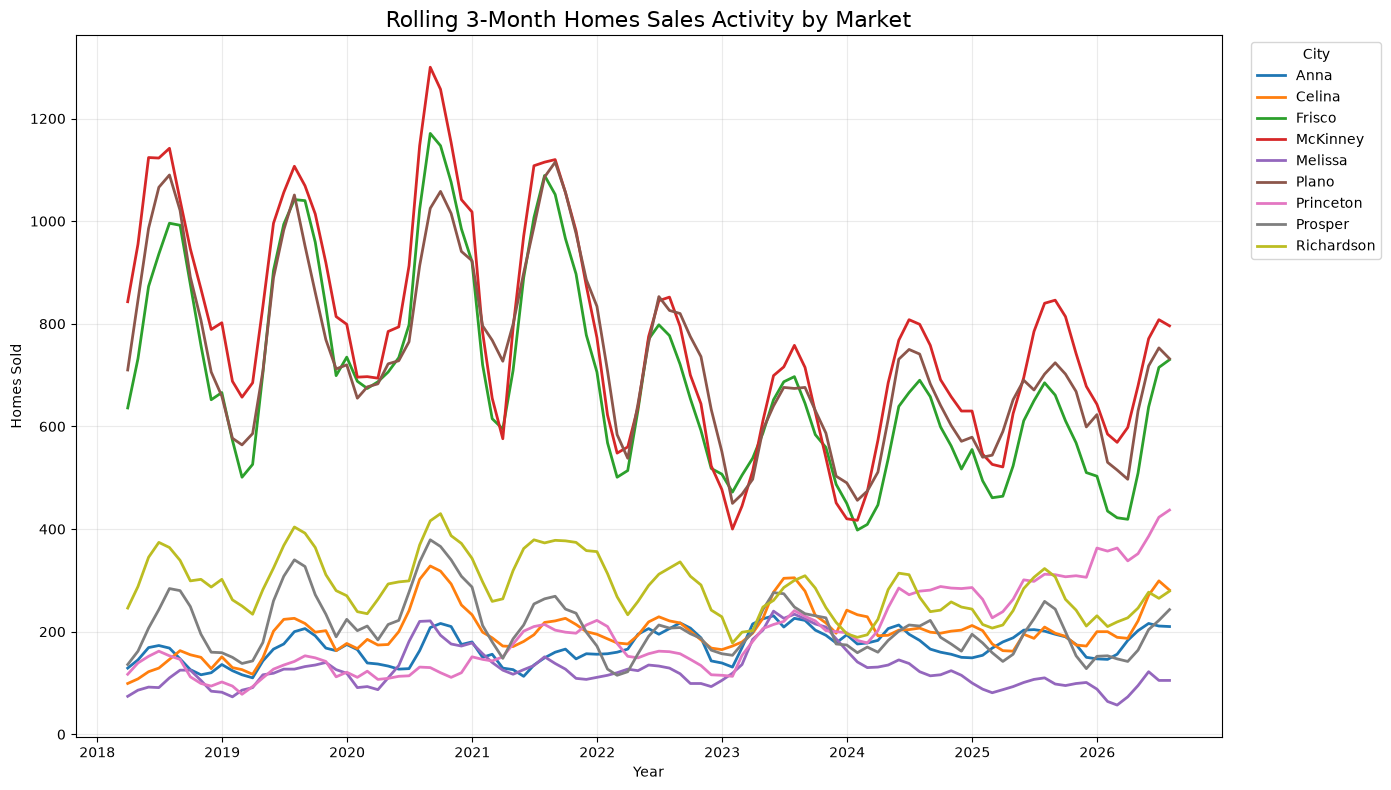

In [42]:
# ROLLING 3-MONTH HOMES SOLD

fig, ax = plt.subplots(figsize=(14,8))

for city in sorted(redfin_clean["City"].unique()):
    city_data = redfin_clean[
        redfin_clean["City"] == city
    ]

    ax.plot(
        city_data["Date"],
        city_data["Homes_Sold"],
        label=city,
        linewidth=2
    )

ax.set_title("Rolling 3-Month Homes Sales Activity by Market", fontsize=16)
ax.set_xlabel("Year")
ax.set_ylabel("Homes Sold")

ax.legend(
    title="City",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [43]:
# YEAR-OVER-YEAR CHANGE IN HOMES SOLD

redfin_clean["Homes_Sold_YoY_Pct"] = (
    redfin_clean
    .groupby("City")["Homes_Sold"]
    .pct_change(periods=12) * 100
)

redfin_clean[
    [
        "City",
        "Date",
        "Homes_Sold",
        "Homes_Sold_YoY_Pct"
    ]
].tail(20)

,City,Date,Homes_Sold,Homes_Sold_YoY_Pct
889,Richardson,2024-12-31,244.00,24.49
890,Richardson,2025-01-31,214.00,13.23
891,Richardson,2025-02-28,207.00,6.70
892,Richardson,2025-03-31,213.00,-4.91
893,Richardson,2025-04-30,241.00,-14.54
894,Richardson,2025-05-31,284.00,-9.55
895,Richardson,2025-06-30,306.00,-1.61
896,Richardson,2025-07-31,323.00,20.97
897,Richardson,2025-08-31,307.00,28.45
898,Richardson,2025-09-30,263.00,8.68


In [44]:
# LATEST TRANSACTION ACTIVITY

latest_sales = (
    redfin_clean
    .dropna(subset=["Homes_Sold"])
    .sort_values("Date")
    .groupby("City", as_index=False)
    .last()
    [
        [
            "City",
            "Date",
            "Homes_Sold",
            "Homes_Sold_YoY_Pct"
        ]
    ]
    .sort_values(
        "Homes_Sold_YoY_Pct", ascending=False
    )
)

latest_sales.round(2)

/var/folders/6d/pd31hflx6pndghn88mc5d6tr0000gn/T/ipykernel_27360/1898546614.py:22: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  latest_sales.round(2)


,City,Date,Homes_Sold,Homes_Sold_YoY_Pct
6,Princeton,2026-07-31,437.00,40.06
1,Celina,2026-07-31,281.00,34.45
2,Frisco,2026-07-31,730.00,6.57
0,Anna,2026-07-31,210.00,4.48
5,Plano,2026-07-31,732.00,4.27
4,Melissa,2026-07-31,105.00,-4.55
3,McKinney,2026-07-31,796.00,-5.24
7,Prosper,2026-07-31,243.00,-6.18
8,Richardson,2026-07-31,279.00,-13.62


In [45]:
# PEAK TRANSACTION ACTIVITY

sales_peak = (
    redfin_clean
    .dropna(subset=["Homes_Sold"])
    .loc[
        lambda x: x.groupby("City")["Homes_Sold"].idxmax(),
        ["City", "Date", "Homes_Sold"]
    ]
    .rename(
        columns={
            "Date": "Peak_Sales_Date",
            "Homes_Sold": "Peak_Homes_Sold"
        }
    )
)

sales_peak = sales_peak.merge(
    latest_sales[
        [
            "City",
            "Date",
            "Homes_Sold",
            "Homes_Sold_YoY_Pct"
        ]
    ],
    on="City",
    how="left"
)

sales_peak = sales_peak.rename(
    columns={
        "Date": "Latest_Sales_Date",
        "Homes_Sold": "Latest_Homes_Sold"
    }
)

sales_peak["Change_From_Sales_Peak_Pct"] = (
    sales_peak["Latest_Homes_Sold"] / sales_peak["Peak_Homes_Sold"] - 1
) * 100

sales_peak[
    [
        "City",
        "Peak_Sales_Date",
        "Peak_Homes_Sold",
        "Latest_Homes_Sold",
        "Homes_Sold_YoY_Pct",
        "Change_From_Sales_Peak_Pct"
    ]
].sort_values(
    "Change_From_Sales_Peak_Pct", ascending=False
).round(2)

/var/folders/6d/pd31hflx6pndghn88mc5d6tr0000gn/T/ipykernel_27360/1155045754.py:53: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ).round(2)


,City,Peak_Sales_Date,Peak_Homes_Sold,Latest_Homes_Sold,Homes_Sold_YoY_Pct,Change_From_Sales_Peak_Pct
6,Princeton,2026-07-31,437.00,437.00,40.06,0.00
0,Anna,2023-05-31,231.00,210.00,4.48,-9.09
1,Celina,2020-08-31,328.00,281.00,34.45,-14.33
5,Plano,2021-08-31,"1,115.00",732.00,4.27,-34.35
8,Richardson,2020-09-30,430.00,279.00,-13.62,-35.12
7,Prosper,2020-08-31,379.00,243.00,-6.18,-35.88
2,Frisco,2020-08-31,"1,171.00",730.00,6.57,-37.66
3,McKinney,2020-08-31,"1,300.00",796.00,-5.24,-38.77
4,Melissa,2023-05-31,240.00,105.00,-4.55,-56.25


## 7. Housing Supply and Inventory

Transaction activity must be interpreted alongside housing supply.

An increase in home sales can indicate stronger buyer demand, but if inventory is increasing even faster, buyers may still have greater negotiating power and home prices may remain under pressure.

This section evaluates inventory growth, months of supply, new listings, and market time to determine whether housing supply is tightening or expanding.

In [46]:
# YEAR-OVER-YEAR INVENTORY GROWTH

redfin_clean["Inventory_YoY_Pct"] = (
    redfin_clean
    .groupby("City")["Inventory"]
    .pct_change(periods=12) * 100
)

In [47]:
# LATEST INVENTORY CONDITIONS

latest_inventory = (
    redfin_clean
    .sort_values("Date")
    .groupby("City", as_index=False)
    .last()
    [
        [
            "City",
            "Date",
            "Inventory",
            "Inventory_YoY_Pct",
            "Months_of_Supply"
        ]
    ]
    .sort_values(
        "Inventory_YoY_Pct", ascending=False
    )
)

latest_inventory.round(2)

/var/folders/6d/pd31hflx6pndghn88mc5d6tr0000gn/T/ipykernel_27360/4100918398.py:22: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  latest_inventory.round(2)


,City,Date,Inventory,Inventory_YoY_Pct,Months_of_Supply
1,Celina,2026-07-31,626.00,15.93,6.80
0,Anna,2026-07-31,402.00,10.74,5.90
2,Frisco,2026-07-31,"1,158.00",4.70,4.90
8,Richardson,2026-07-31,347.00,1.76,3.80
7,Prosper,2026-07-31,422.00,0.24,5.30
6,Princeton,2026-07-31,467.00,-1.06,3.30
3,McKinney,2026-07-31,"1,054.00",-10.07,4.10
4,Melissa,2026-07-31,178.00,-13.59,5.20
5,Plano,2026-07-31,807.00,-19.70,3.40


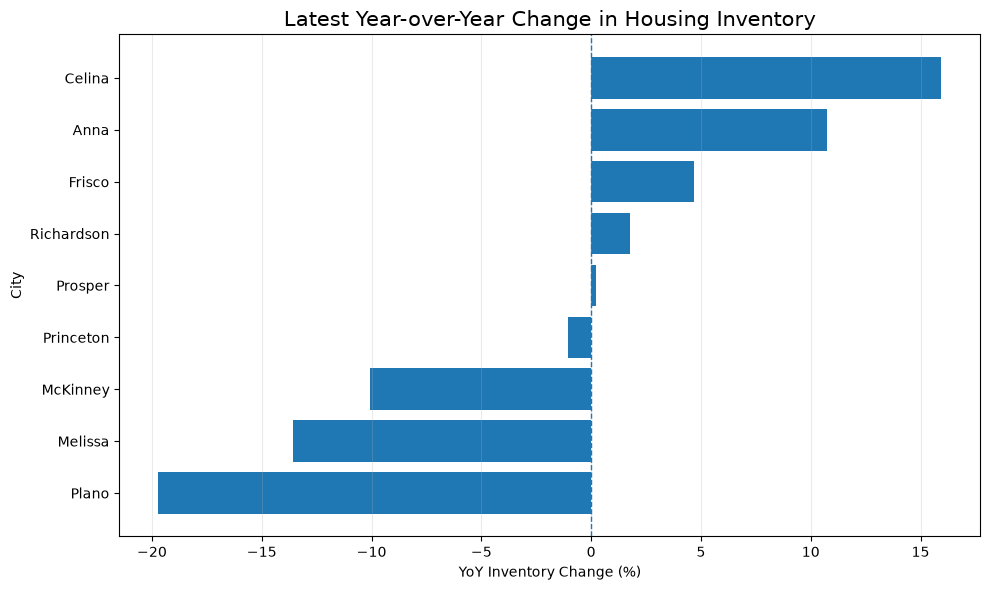

In [48]:
# LATEST YOY INVENTORY GROWTH

plot_data = latest_inventory.sort_values("Inventory_YoY_Pct")

fig, ax = plt.subplots(figsize=(10,6))

ax.barh(
    plot_data["City"], 
    plot_data["Inventory_YoY_Pct"]
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_title("Latest Year-over-Year Change in Housing Inventory", fontsize=15)
ax.set_xlabel("YoY Inventory Change (%)")
ax.set_ylabel("City")

ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

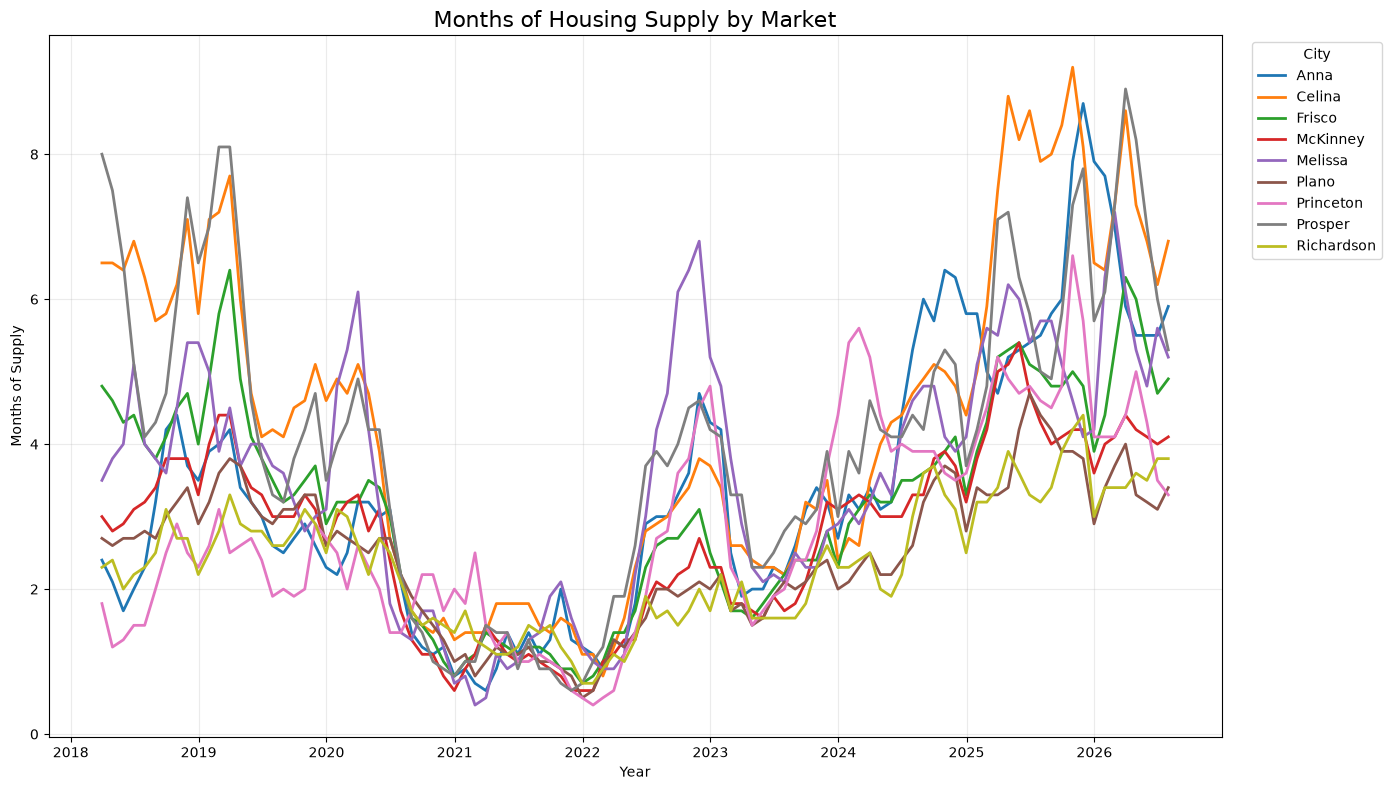

In [49]:
# MONTHS OF SUPPLY OVER TIME

fig, ax = plt.subplots(figsize=(14,8))

for city in sorted(redfin_clean["City"].unique()):
    city_data = redfin_clean[
        redfin_clean["City"] == city
    ]

    ax.plot(
        city_data["Date"],
        city_data["Months_of_Supply"],
        label=city,
        linewidth=2
    )

ax.set_title("Months of Housing Supply by Market", fontsize=16)
ax.set_xlabel("Year")
ax.set_ylabel("Months of Supply")

ax.legend(
    title="City",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [50]:
latest_supply = (
    redfin_clean
    .sort_values("Date")
    .groupby("City", as_index=False)
    .last()
    [
        [
            "City",
            "Date",
            "Months_of_Supply"
        ]
    ]
    .sort_values(
        "Months_of_Supply",
        ascending=False
    )
)

latest_supply.round(2)

/var/folders/6d/pd31hflx6pndghn88mc5d6tr0000gn/T/ipykernel_27360/504398252.py:19: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  latest_supply.round(2)


,City,Date,Months_of_Supply
1,Celina,2026-07-31,6.80
0,Anna,2026-07-31,5.90
7,Prosper,2026-07-31,5.30
4,Melissa,2026-07-31,5.20
2,Frisco,2026-07-31,4.90
3,McKinney,2026-07-31,4.10
8,Richardson,2026-07-31,3.80
5,Plano,2026-07-31,3.40
6,Princeton,2026-07-31,3.30


In [51]:
# YEAR-OVER-YEAR CHANGE IN DAYS ON MARKET

redfin_clean["DOM_YoY_Change"] = (redfin_clean["Median_DOM"] - redfin_clean.groupby("City")["Median_DOM"].shift(12))

In [52]:
latest_dom = (
    redfin_clean
    .sort_values("Date")
    .groupby("City", as_index=False)
    .last()
    [
        [
            "City",
            "Date",
            "Median_DOM",
            "DOM_YoY_Change"
        ]
    ]
    .sort_values(
        "DOM_YoY_Change", ascending=False
    )
)

latest_dom.round(2)

/var/folders/6d/pd31hflx6pndghn88mc5d6tr0000gn/T/ipykernel_27360/3857844584.py:19: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  latest_dom.round(2)


,City,Date,Median_DOM,DOM_YoY_Change
0,Anna,2026-07-31,76.00,14.00
1,Celina,2026-07-31,83.00,10.00
4,Melissa,2026-07-31,60.00,3.00
2,Frisco,2026-07-31,50.00,2.00
5,Plano,2026-07-31,36.00,1.00
8,Richardson,2026-07-31,33.00,1.00
3,McKinney,2026-07-31,45.00,0.00
7,Prosper,2026-07-31,66.00,0.00
6,Princeton,2026-07-31,61.00,-5.00


In [53]:
# LATEST SALE-TO-LIST CONDITIONS

latest_sale_to_list = (
    redfin_clean
    .sort_values("Date")
    .groupby("City", as_index=False)
    .last()
    [
        [
            "City",
            "Date",
            "Sale_to_List_Pct",
            "Share_Sold_Above_List_Pct",
            "Pct_Off_Market_2_Weeks"
        ]
    ]
    .sort_values("Sale_to_List_Pct", ascending=False)
)

latest_sale_to_list.round(2)

/var/folders/6d/pd31hflx6pndghn88mc5d6tr0000gn/T/ipykernel_27360/4260573300.py:20: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  latest_sale_to_list.round(2)


,City,Date,Sale_to_List_Pct,Share_Sold_Above_List_Pct,Pct_Off_Market_2_Weeks
4,Melissa,2026-07-31,97.90,12.64,16.84
5,Plano,2026-07-31,97.90,14.42,36.50
8,Richardson,2026-07-31,97.82,18.71,33.50
3,McKinney,2026-07-31,97.76,10.94,25.40
0,Anna,2026-07-31,97.73,2.93,12.43
6,Princeton,2026-07-31,97.33,10.55,12.12
2,Frisco,2026-07-31,97.29,8.14,23.29
1,Celina,2026-07-31,96.50,3.64,11.41
7,Prosper,2026-07-31,96.36,3.38,14.84


In [54]:
# COMBINED CURRENT MARKET CONDITIONS

market_conditions = (
    final_price_summary[
        [
            "City",
            "Latest_YoY_Pct",
            "Change_From_Peak_Pct"
        ]
    ]
    .merge(
        latest_sales[
            [
                "City",
                "Homes_Sold_YoY_Pct"
            ]
        ],
        on="City"
    )
    .merge(
        latest_inventory[
            [
                "City",
                "Inventory_YoY_Pct",
                "Months_of_Supply"
            ]
        ],
        on="City"
    )
    .merge(
        latest_dom[
            [
                "City",
                "Median_DOM",
                "DOM_YoY_Change"
            ]
        ],
        on="City"
    )
    .merge(
        latest_sale_to_list[
            [
                "City",
                "Sale_to_List_Pct"
            ]
        ],
        on="City"
    )
)

market_conditions = market_conditions.rename(
    columns={
        "Latest_YoY_Pct": "ZHVI_YoY_Pct",
        "Change_From_Peak_Pct": "ZHVI_From_Peak_Pct"
    }
)

market_conditions.round(2)

,City,ZHVI_YoY_Pct,ZHVI_From_Peak_Pct,Homes_Sold_YoY_Pct,Inventory_YoY_Pct,Months_of_Supply,Median_DOM,DOM_YoY_Change,Sale_to_List_Pct
0,Richardson,-0.24,-4.48,-13.62,1.76,3.80,33.00,1.00,97.82
1,Plano,-4.43,-9.18,4.27,-19.70,3.40,36.00,1.00,97.90
2,Frisco,-4.56,-9.64,6.57,4.70,4.90,50.00,2.00,97.29
3,Prosper,-5.71,-12.17,-6.18,0.24,5.30,66.00,0.00,96.36
4,Melissa,-6.02,-17.95,-4.55,-13.59,5.20,60.00,3.00,97.90
5,McKinney,-6.11,-13.80,-5.24,-10.07,4.10,45.00,0.00,97.76
6,Anna,-7.08,-20.84,4.48,10.74,5.90,76.00,14.00,97.73
7,Celina,-9.34,-17.01,34.45,15.93,6.80,83.00,10.00,96.50
8,Princeton,-10.23,-25.12,40.06,-1.06,3.30,61.00,-5.00,97.33


## Current Market Conditions: Initial Findings

The combined price and transaction indicators reveal that the nine markets are not experiencing the current housing slowdown in the same way.

**Princeton shows the strongest evidence of transaction recovery.** Although home values remain substantially below their historical peak, rolling three-month sales activity has reached a new high and is approximately 40% above the comparable period one year earlier. Inventory is approximately 40% above the comparable period one year earlier. Inventory is approximately flat, while median days on market has improved. This suggests that lower prices may be attracting increased buyer activity.

**Celina also shows strong transaction growth, but under substantially greater supply pressure.** Home sales are approximately 34%% higher year over year, while inventory has increased approximately 16%, monthly of supply is elevated, and homes are taking longer to sell. This combination suggests that transaction growth alone should not be interpreted as evidence of a tightening market.

**Plano, Frisco, and Richardson currently show comparatively resilient conditions**, with relatively modest price declines and positive year-over-year sales growth.

**Melissa, McKinney, and Prosper show weaker current demand signals**, with both home values and transaction activity declining year over year.

These findings remain preliminary. Population growth and residential construction must be incorporated to determine whether current supply and transaction patterns reflect weakening demand or the expansion of rapidly growing housing markets.

In [55]:
# YEAR-OVER-YEAR NEW LISTING GROWTH

redfin_clean["New_Listings_YoY_Pct"] = (
    redfin_clean
    .groupby("City")["New_Listings"]
    .pct_change(periods=12) * 100
)

latest_listings = (
    redfin_clean
    .sort_values("Date")
    .groupby("City", as_index=False)
    .last()
    [
        [
            "City",
            "New_Listings",
            "New_Listings_YoY_Pct",
            "Active_Listings",
            "Inventory"
        ]
    ]
    .sort_values(
        "New_Listings_YoY_Pct", ascending=False
    )
)

latest_listings.round(2)

,City,New_Listings,New_Listings_YoY_Pct,Active_Listings,Inventory
1,Celina,468.00,23.48,988.00,626.00
8,Richardson,435.00,0.93,715.00,347.00
2,Frisco,"1,118.00",-0.18,"2,102.00","1,158.00"
0,Anna,314.00,-1.88,663.00,402.00
4,Melissa,159.00,-12.64,316.00,178.00
3,McKinney,"1,081.00",-14.55,"2,018.00","1,054.00"
6,Princeton,393.00,-15.67,970.00,467.00
5,Plano,994.00,-17.03,"1,661.00",807.00
7,Prosper,291.00,-18.94,728.00,422.00


In [56]:
# YEAR-OVER-YEAR PENDING SALES GROWTH

redfin_clean["Pending_Sales_YoY_Pct"] = (
    redfin_clean
    .groupby("City")["Pending_Sales"]
    .pct_change(periods=12) * 100
)

latest_pending = (
    redfin_clean
    .sort_values("Date")
    .groupby("City", as_index=False)
    .last()
    [
        [
            "City",
            "Pending_Sales",
            "Pending_Sales_YoY_Pct"
        ]
    ]
    .sort_values(
        "Pending_Sales_YoY_Pct", ascending=False
    )
)

latest_pending.round(2)

,City,Pending_Sales,Pending_Sales_YoY_Pct
1,Celina,297.00,44.17
6,Princeton,452.00,39.94
0,Anna,216.00,5.88
2,Frisco,706.00,-1.81
8,Richardson,324.00,-4.71
5,Plano,748.00,-6.38
7,Prosper,221.00,-11.60
3,McKinney,796.00,-12.53
4,Melissa,95.00,-16.67


In [57]:
# EXPAND MARKET CONDITIONS TABLE

market_conditions = (
    market_conditions
    .merge(
        latest_listings[
            [
                "City",
                "New_Listings_YoY_Pct"
            ]
        ],
        on="City",
        how="left"
    )
    .merge(
        latest_pending[
            [
                "City",
                "Pending_Sales_YoY_Pct"
            ]
        ],
        on="City",
        how="left"
    )
)

market_conditions.round(2)

,City,ZHVI_YoY_Pct,ZHVI_From_Peak_Pct,Homes_Sold_YoY_Pct,Inventory_YoY_Pct,Months_of_Supply,Median_DOM,DOM_YoY_Change,Sale_to_List_Pct,New_Listings_YoY_Pct,Pending_Sales_YoY_Pct
0,Richardson,-0.24,-4.48,-13.62,1.76,3.80,33.00,1.00,97.82,0.93,-4.71
1,Plano,-4.43,-9.18,4.27,-19.70,3.40,36.00,1.00,97.90,-17.03,-6.38
2,Frisco,-4.56,-9.64,6.57,4.70,4.90,50.00,2.00,97.29,-0.18,-1.81
3,Prosper,-5.71,-12.17,-6.18,0.24,5.30,66.00,0.00,96.36,-18.94,-11.60
4,Melissa,-6.02,-17.95,-4.55,-13.59,5.20,60.00,3.00,97.90,-12.64,-16.67
5,McKinney,-6.11,-13.80,-5.24,-10.07,4.10,45.00,0.00,97.76,-14.55,-12.53
6,Anna,-7.08,-20.84,4.48,10.74,5.90,76.00,14.00,97.73,-1.88,5.88
7,Celina,-9.34,-17.01,34.45,15.93,6.80,83.00,10.00,96.50,23.48,44.17
8,Princeton,-10.23,-25.12,40.06,-1.06,3.30,61.00,-5.00,97.33,-15.67,39.94


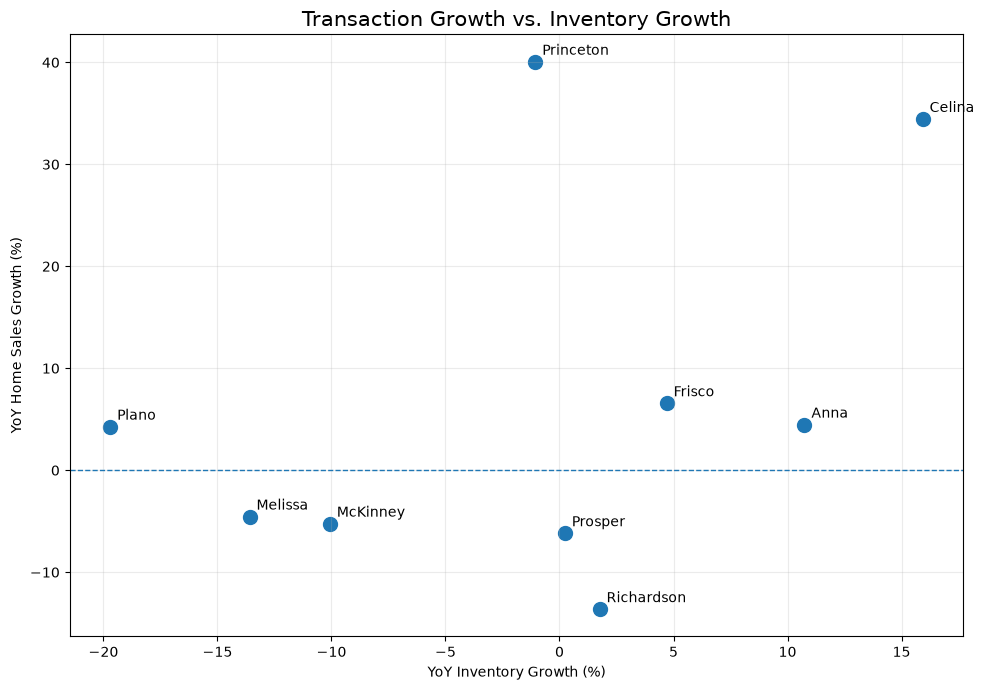

In [58]:
# SALES GROWTH VS. INVENTORY GROWTH

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    market_conditions["Inventory_YoY_Pct"],
    market_conditions["Homes_Sold_YoY_Pct"],
    s=100
)

for _, row in market_conditions.iterrows():
    ax.annotate(
        row["City"],
        (
            row["Inventory_YoY_Pct"],
            row["Homes_Sold_YoY_Pct"]
        ),
        xytext=(5,5),
        textcoords="offset points"
    )

ax.axhline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_title("Transaction Growth vs. Inventory Growth", fontsize=15)
ax.set_xlabel("YoY Inventory Growth (%)")
ax.set_ylabel("YoY Home Sales Growth (%)")

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

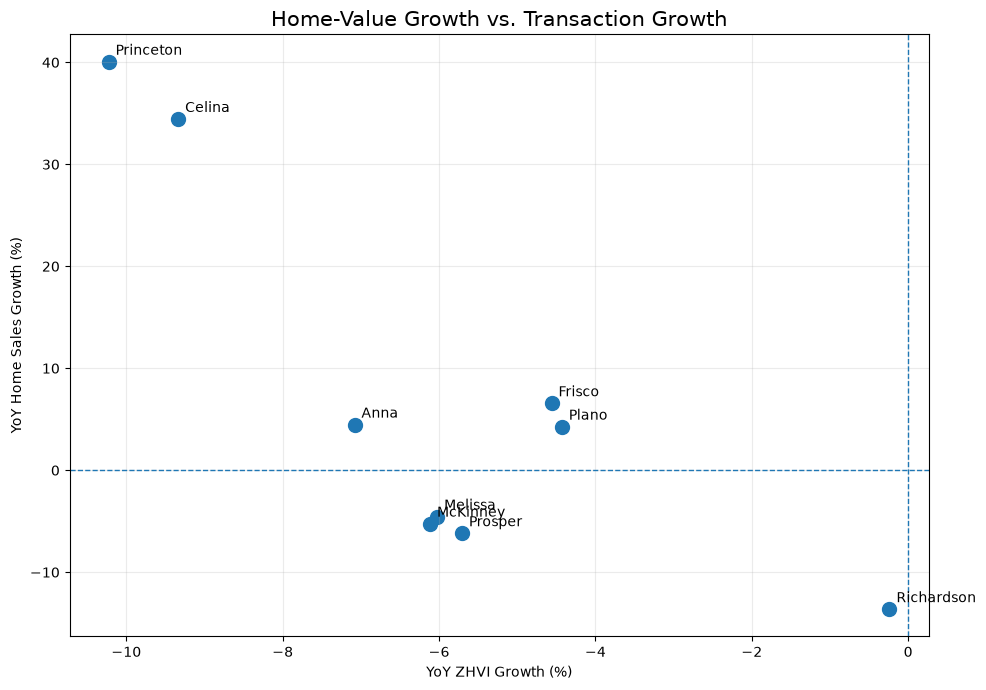

In [59]:
# PRICE GROWTH VS. TRANSACTION GROWTH

fig, ax = plt.subplots(figsize=(10,7))

ax.scatter(
    market_conditions["ZHVI_YoY_Pct"],
    market_conditions["Homes_Sold_YoY_Pct"],
    s=100
)

for _, row in market_conditions.iterrows():
    ax.annotate(
        row["City"],
        (
            row["ZHVI_YoY_Pct"],
            row["Homes_Sold_YoY_Pct"]
        ),
        xytext=(5,5),
        textcoords="offset points"
    )

ax.axhline(
    0,
    linestyle="--",
    linewidth=1
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_title("Home-Value Growth vs. Transaction Growth", fontsize=15)
ax.set_xlabel("YoY ZHVI Growth (%)")
ax.set_ylabel("YoY Home Sales Growth (%)")

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [60]:
# EXPORT CLEAN REDFIN DATA

REDFIN_PROCESSED_FILE = (
    PROCESSED_DATA_DIR / "dallas_redfin_market_activity.csv"
)

redfin_clean.to_csv(
    REDFIN_PROCESSED_FILE, index=False
)

print("Saved to:", REDFIN_PROCESSED_FILE)
print("\nShape:", redfin_clean.shape)

Saved to: /Users/ninahuang/Downloads/Personal/Projects/TX Market Analysis/tx_market_analysis/data/processed/dallas_redfin_market_activity.csv

Shape: (909, 24)


In [61]:
# CHECK SAVED FILES

redfin_check = pd.read_csv(REDFIN_PROCESSED_FILE, parse_dates=["Period_Begin", "Date"])

print("Reloaded shape:", redfin_check.shape)
print("Cities:", sorted(redfin_check["City"].unique()))
print(
    "Date range:",
    redfin_check["Date"].min(),
    "to",
    redfin_check["Date"].max()    
)

Reloaded shape: (909, 24)
Cities: ['Anna', 'Celina', 'Frisco', 'McKinney', 'Melissa', 'Plano', 'Princeton', 'Prosper', 'Richardson']
Date range: 2018-03-31 00:00:00 to 2026-07-31 00:00:00


## Housing Market Activity Findings

Current housing conditions vary substantially across the nine markets, despite home values declining year over year in every city.

**Princeton currently shows the strongest transaction recovery.** Rolling home sales increased approximately 40% year over year, pending sales increased approximately 40%, and inventory remained roughly unchanged. Median days on market also declined, suggesting improving transaction velocity despite continued price declines.

**Celina also exhibits substantial transaction growth**, with home sales increasing apprxoimately 45% and pending sales increasing approximately 44%. However, this demand growth is accompanied by a 16% increase in inventory, a 23% increase in new listings, elevated months of supply, longer marketing times, and greater discounts from listings prices. Celina therefore appears to be experiencing simultaneous growth in transaction activity and housing supply.

**Richardson stands out as the most price-resilient market in the analysis**, with ZHVI down only 0.24% YoY and 4.48% from its peak. Inventory remains relatively constrained at 3.8 months of supply, while homes sell in a median 33 days at 97.82% of list price. However, homes sold fell 13.62% YoY and pending sales declined 4.71%, indicating softer buyer activity despite stable pricing conditions. Overall, Richardson appears relatively stable rather than strongly expanding or correcting.

**Plano and Frisco show comparatively resilient conditions**, with positive sales growth and smaller home-value declines than several of the faster-growing outer markets.

**Anna shows modest transaction growth but rising inventory and longer marketing times**, suggesting that available supply is currently expanding faster than demand.

**Melissa, McKinney, and Prosper currently show broader cooling signals**, including declining home values, lower transaction activity, and declining pending sales.

Overall, falling home values do not necessarily indicate that a city's housing market is contracting. Transaction activity and housing supply must be evaluated alongside demographic and construction growth to distinguish cyclical price corrections from deterioration in underlying market fundamentals.

# Demographic Growth Analysis

## 8. Population Growth

Housing-market activity reflects current buying and selling conditions, but a growing real-estate market should also be supported by growth in the underlying population.

Population growth can increease long-term housing demand by expanding the number of households requiring housing. This section evaluates:
- Historical population
- Total population growth
- Recent population growth
- Population CAGR
- Changes in the pace of population growth

Population trends will later be combined with housing-market and rediential construction indicators to distinguish long-term market expansion from short-term housing cycles.

In [62]:
# CENSUS POPULATION FILE PATH

CENSUS_DIR = RAW_DATA_DIR / "census"

CENSUS_FILE = (CENSUS_DIR / "SUB-IP-EST2025-POP-48.xlsx")

print("Census file:", CENSUS_FILE)
print("File exists:", CENSUS_FILE.exists())

Census file: /Users/ninahuang/Downloads/Personal/Projects/TX Market Analysis/tx_market_analysis/data/raw/census/SUB-IP-EST2025-POP-48.xlsx
File exists: True


In [63]:
# INSPECT CENSUS WORKBOOK

xls = pd.ExcelFile(CENSUS_FILE)

print("Sheet names:")
for sheet in xls.sheet_names:
    print("-", sheet)

Sheet names:
- SUB-IP-EST2025-POP-48


In [64]:
# LOAD CENSUS POPULATION DATA

census_raw = pd.read_excel(
    CENSUS_FILE,
    sheet_name=0,
    header=None,
    skiprows=3
)

census_raw.columns = [
    "Geographic_Area",
    "Estimates_Base_2020",
    "Population_2020",
    "Population_2021",
    "Population_2022",
    "Population_2023",
    "Population_2024",
    "Population_2025",
]

print("Dataset shape:", census_raw.shape)
census_raw.head(10)

Dataset shape: (1231, 8)


,Geographic_Area,Estimates_Base_2020,Population_2020,Population_2021,Population_2022,Population_2023,Population_2024,Population_2025
0,NaN,NaN,"2,020.00","2,021.00","2,022.00","2,023.00","2,024.00","2,025.00"
1,"Abbott city, Texas",352.00,353.00,355.00,363.00,369.00,374.00,377.00
2,"Abernathy city, Texas","2,872.00","2,866.00","2,849.00","2,826.00","2,828.00","2,842.00","2,826.00"
3,"Abilene city, Texas","124,970.00","125,194.00","125,883.00","127,376.00","129,167.00","130,136.00","131,588.00"
4,"Ackerly city, Texas",265.00,265.00,266.00,265.00,265.00,265.00,269.00
5,"Addison town, Texas","17,090.00","17,091.00","17,417.00","17,341.00","17,295.00","17,302.00","17,195.00"
6,"Adrian city, Texas",130.00,131.00,130.00,131.00,134.00,136.00,136.00
7,"Agua Dulce city, Texas",693.00,692.00,687.00,679.00,673.00,669.00,662.00
8,"Alamo city, Texas","19,513.00","19,655.00","19,979.00","20,298.00","20,518.00","20,620.00","20,625.00"
9,"Alamo Heights city, Texas","7,362.00","7,380.00","7,456.00","7,570.00","7,536.00","7,623.00","7,632.00"


In [65]:
# CLEAN CENSUS GEOGRAPHIC NAMES

census_raw["City"] = (
    census_raw["Geographic_Area"]
    .astype(str)
    .str.replace(", Texas", "", regex=False)
    .str.replace(" city", "", regex=False)
    .str.replace(" town", "", regex=False)
    .str.replace(" village", "", regex=False)
    .str.strip()
)

census_raw[
    ["Geographic_Area", "City"]
].head(20)

,Geographic_Area,City
0,NaN,NaN
1,"Abbott city, Texas",Abbott
2,"Abernathy city, Texas",Abernathy
3,"Abilene city, Texas",Abilene
4,"Ackerly city, Texas",Ackerly
5,"Addison town, Texas",Addison
6,"Adrian city, Texas",Adrian
7,"Agua Dulce city, Texas",Agua Dulce
8,"Alamo city, Texas",Alamo
9,"Alamo Heights city, Texas",Alamo Heights


In [66]:
# REMOVE NON-DATA ROWS

census_raw = census_raw[
    census_raw["Geographic_Area"].notna()
].copy()

census_raw = census_raw[
    census_raw["City"].notna()
].copy()

census_raw = census_raw.reset_index(drop=True)
census_raw.head(10)

,Geographic_Area,Estimates_Base_2020,Population_2020,Population_2021,Population_2022,Population_2023,Population_2024,Population_2025,City
0,"Abbott city, Texas",352.00,353.00,355.00,363.00,369.00,374.00,377.00,Abbott
1,"Abernathy city, Texas","2,872.00","2,866.00","2,849.00","2,826.00","2,828.00","2,842.00","2,826.00",Abernathy
2,"Abilene city, Texas","124,970.00","125,194.00","125,883.00","127,376.00","129,167.00","130,136.00","131,588.00",Abilene
3,"Ackerly city, Texas",265.00,265.00,266.00,265.00,265.00,265.00,269.00,Ackerly
4,"Addison town, Texas","17,090.00","17,091.00","17,417.00","17,341.00","17,295.00","17,302.00","17,195.00",Addison
5,"Adrian city, Texas",130.00,131.00,130.00,131.00,134.00,136.00,136.00,Adrian
6,"Agua Dulce city, Texas",693.00,692.00,687.00,679.00,673.00,669.00,662.00,Agua Dulce
7,"Alamo city, Texas","19,513.00","19,655.00","19,979.00","20,298.00","20,518.00","20,620.00","20,625.00",Alamo
8,"Alamo Heights city, Texas","7,362.00","7,380.00","7,456.00","7,570.00","7,536.00","7,623.00","7,632.00",Alamo Heights
9,"Alba town, Texas",472.00,473.00,483.00,491.00,502.00,508.00,511.00,Alba


In [67]:
# FILTER TARGET CITIES

TARGET_CITIES = [
    "Anna",
    "Celina",
    "Frisco",
    "McKinney",
    "Melissa",
    "Plano",
    "Princeton",
    "Prosper",
    "Richardson"
]

census_target = census_raw[
    census_raw["City"].isin(TARGET_CITIES)
].copy()

print("Rows found:", len(census_target))

census_target[
    [
        "City",
        "Geographic_Area",
        "Population_2020",
        "Population_2021",
        "Population_2022",
        "Population_2023",
        "Population_2024",
        "Population_2025",
    ]
].sort_values("City")

Rows found: 9


,City,Geographic_Area,Population_2020,Population_2021,Population_2022,Population_2023,Population_2024,Population_2025
29,Anna,"Anna city, Texas","17,616.00","20,459.00","23,825.00","27,938.00","31,996.00","35,245.00"
184,Celina,"Celina city, Texas","18,033.00","24,097.00","34,476.00","43,820.00","51,717.00","64,427.00"
383,Frisco,"Frisco city, Texas","202,749.00","211,127.00","220,399.00","226,878.00","235,159.00","236,955.00"
666,McKinney,"McKinney city, Texas","197,507.00","203,569.00","208,584.00","215,834.00","227,497.00","236,001.00"
694,Melissa,"Melissa city, Texas","14,339.00","16,969.00","19,423.00","23,800.00","26,178.00","29,969.00"
853,Plano,"Plano city, Texas","286,414.00","288,912.00","291,123.00","293,395.00","293,395.00","293,028.00"
882,Princeton,"Princeton city, Texas","17,501.00","20,071.00","22,962.00","28,234.00","36,856.00","43,524.00"
885,Prosper,"Prosper town, Texas","30,829.00","34,159.00","37,870.00","42,030.00","44,511.00","45,605.00"
912,Richardson,"Richardson city, Texas","119,319.00","118,127.00","119,245.00","118,734.00","117,972.00","118,542.00"


In [68]:
# VALIDATION

cities_found = sorted(census_target["City"].unique())
cities_missing = sorted(set(TARGET_CITIES) - set(cities_found))

print("Cities found:")

for city in cities_found:
    print("-", city)

print("\nCities missing:")
if cities_missing:
    for city in cities_missing:
        print("-", city)
else:
    print("None")

Cities found:
- Anna
- Celina
- Frisco
- McKinney
- Melissa
- Plano
- Princeton
- Prosper
- Richardson

Cities missing:
None


In [69]:
# SET UP

population_cols = [
    "Population_2020",
    "Population_2021",
    "Population_2022",
    "Population_2023",
    "Population_2024",
    "Population_2025",
]

In [70]:
population_long = census_target.melt(
    id_vars=["City"],
    value_vars=population_cols,
    var_name="Population_Year",
    value_name="Population"
)

population_long["Year"] = (
    population_long["Population_Year"]
    .str.replace("Population_", "", regex=False)
    .astype(int)
)

population_long = (
    population_long
    .drop(columns=["Population_Year"])
    .sort_values(["City", "Year"])
    .reset_index(drop=True)
)

In [71]:
print("Cities:", population_long["City"].nunique())
print("Years:", sorted(population_long["Year"].unique()))
print("Observations:", len(population_long))
print("Missing population values:", population_long["Population"].isna().sum())
print("Duplicate city-years:", population_long.duplicated(["City", "Year"]).sum())

Cities: 9
Years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Observations: 54
Missing population values: 0
Duplicate city-years: 0


In [72]:
# POPULATION BY CITY AND YEAR

population_pivot = (
    population_long
    .pivot(
        index="City",
        columns="Year",
        values="Population"
    )
)

population_pivot

Year,2020,2021,2022,2023,2024,2025
City,,,,,,
Anna,"17,616.00","20,459.00","23,825.00","27,938.00","31,996.00","35,245.00"
Celina,"18,033.00","24,097.00","34,476.00","43,820.00","51,717.00","64,427.00"
Frisco,"202,749.00","211,127.00","220,399.00","226,878.00","235,159.00","236,955.00"
McKinney,"197,507.00","203,569.00","208,584.00","215,834.00","227,497.00","236,001.00"
Melissa,"14,339.00","16,969.00","19,423.00","23,800.00","26,178.00","29,969.00"
Plano,"286,414.00","288,912.00","291,123.00","293,395.00","293,395.00","293,028.00"
Princeton,"17,501.00","20,071.00","22,962.00","28,234.00","36,856.00","43,524.00"
Prosper,"30,829.00","34,159.00","37,870.00","42,030.00","44,511.00","45,605.00"
Richardson,"119,319.00","118,127.00","119,245.00","118,734.00","117,972.00","118,542.00"


In [73]:
# YEAR-OVER-YEAR POPULATION GROWTH

population_long["Population_YoY_Pct"] = (
    population_long
    .groupby("City")["Population"]
    .pct_change() * 100
)

population_long[
    [
        "City",
        "Year",
        "Population",
        "Population_YoY_Pct"
    ]
].round(2)

,City,Year,Population,Population_YoY_Pct
0,Anna,2020,"17,616.00",NaN
1,Anna,2021,"20,459.00",16.14
2,Anna,2022,"23,825.00",16.45
3,Anna,2023,"27,938.00",17.26
4,Anna,2024,"31,996.00",14.53
5,Anna,2025,"35,245.00",10.15
6,Celina,2020,"18,033.00",NaN
7,Celina,2021,"24,097.00",33.63
8,Celina,2022,"34,476.00",43.07
9,Celina,2023,"43,820.00",27.10


In [74]:
# POPULATION GROWTH SUMMARY

population_summary = (
    population_long
    .groupby("City")
    .agg(
        Start_Year=("Year", "first"),
        Latest_Year=("Year", "last"),
        Start_Population=("Population", "first"),
        Latest_Population=("Population", "last")
    )
    .reset_index()
)

population_summary["Population_Change"] = (
    population_summary["Latest_Population"]
    - population_summary["Start_Population"]
)

population_summary["Total_Population_Growth_Pct"] = (
    (
        population_summary["Latest_Population"]
        / population_summary["Start_Population"]
    ) - 1
) * 100

population_summary[
    [
        "City",
        "Start_Population",
        "Latest_Population",
        "Population_Change",
        "Total_Population_Growth_Pct"
    ]
].sort_values(
    "Total_Population_Growth_Pct",
    ascending=False
).round(2)

,City,Start_Population,Latest_Population,Population_Change,Total_Population_Growth_Pct
1,Celina,"18,033.00","64,427.00","46,394.00",257.27
6,Princeton,"17,501.00","43,524.00","26,023.00",148.69
4,Melissa,"14,339.00","29,969.00","15,630.00",109.00
0,Anna,"17,616.00","35,245.00","17,629.00",100.07
7,Prosper,"30,829.00","45,605.00","14,776.00",47.93
3,McKinney,"197,507.00","236,001.00","38,494.00",19.49
2,Frisco,"202,749.00","236,955.00","34,206.00",16.87
5,Plano,"286,414.00","293,028.00","6,614.00",2.31
8,Richardson,"119,319.00","118,542.00",-777.00,-0.65


In [75]:
# POPULATION CAGR

population_summary["Years"] = (
    population_summary["Latest_Year"] - population_summary["Start_Year"]
)

population_summary["Population_CAGR_Pct"] = (
    (
        population_summary["Latest_Population"] / population_summary["Start_Population"]
    )
    ** (1 / population_summary["Years"]) - 1
) * 100

population_summary[
    [
        "City",
        "Start_Population",
        "Latest_Population",
        "Total_Population_Growth_Pct",
        "Population_CAGR_Pct"
    ]
].sort_values(
    "Population_CAGR_Pct", ascending=False
).round(2)

,City,Start_Population,Latest_Population,Total_Population_Growth_Pct,Population_CAGR_Pct
1,Celina,"18,033.00","64,427.00",257.27,29.00
6,Princeton,"17,501.00","43,524.00",148.69,19.99
4,Melissa,"14,339.00","29,969.00",109.00,15.89
0,Anna,"17,616.00","35,245.00",100.07,14.88
7,Prosper,"30,829.00","45,605.00",47.93,8.15
3,McKinney,"197,507.00","236,001.00",19.49,3.63
2,Frisco,"202,749.00","236,955.00",16.87,3.17
5,Plano,"286,414.00","293,028.00",2.31,0.46
8,Richardson,"119,319.00","118,542.00",-0.65,-0.13


In [76]:
# LATEST POPULATION GROWTH

latest_population_growth = (
    population_long
    .dropna(subset=["Population_YoY_Pct"])
    .sort_values("Year")
    .groupby("City", as_index=False)
    .last()
    [
        [
            "City",
            "Year",
            "Population",
            "Population_YoY_Pct"
        ]
    ]
    .sort_values("Population_YoY_Pct", ascending=False)
)

latest_population_growth.round(2)

,City,Year,Population,Population_YoY_Pct
1,Celina,2025,"64,427.00",24.58
6,Princeton,2025,"43,524.00",18.09
4,Melissa,2025,"29,969.00",14.48
0,Anna,2025,"35,245.00",10.15
3,McKinney,2025,"236,001.00",3.74
7,Prosper,2025,"45,605.00",2.46
2,Frisco,2025,"236,955.00",0.76
8,Richardson,2025,"118,542.00",0.48
5,Plano,2025,"293,028.00",-0.13


In [77]:
# POPULATION GROWTH ACCELERATION

population_long["Previous_Population_YoY_Pct"] = (
    population_long
    .groupby("City")["Population_YoY_Pct"]
    .shift(1)
)

population_long["Population_Growth_Acceleration"] = (
    population_long["Population_YoY_Pct"] - population_long["Previous_Population_YoY_Pct"]
)

In [78]:
latest_population_momentum = (
    population_long
    .dropna(
        subset=["Population_YoY_Pct", "Previous_Population_YoY_Pct"]
    )
    .sort_values("Year")
    .groupby("City", as_index=False)
    .last()
    [
        [
            "City",
            "Year",
            "Population",
            "Population_YoY_Pct",
            "Previous_Population_YoY_Pct",
            "Population_Growth_Acceleration"
        ]
    ]
    .sort_values("Population_Growth_Acceleration", ascending=False)
)

latest_population_momentum.round(2)

,City,Year,Population,Population_YoY_Pct,Previous_Population_YoY_Pct,Population_Growth_Acceleration
1,Celina,2025,"64,427.00",24.58,18.02,6.55
4,Melissa,2025,"29,969.00",14.48,9.99,4.49
8,Richardson,2025,"118,542.00",0.48,-0.64,1.12
5,Plano,2025,"293,028.00",-0.13,0.00,-0.13
3,McKinney,2025,"236,001.00",3.74,5.40,-1.67
2,Frisco,2025,"236,955.00",0.76,3.65,-2.89
7,Prosper,2025,"45,605.00",2.46,5.90,-3.45
0,Anna,2025,"35,245.00",10.15,14.53,-4.37
6,Princeton,2025,"43,524.00",18.09,30.54,-12.45


In [79]:
# FINAL POPULATION SUMMARY

population_summary = population_summary.merge(
    latest_population_momentum[
        [
            "City",
            "Population_YoY_Pct",
            "Population_Growth_Acceleration"
        ]
    ],
    on="City",
    how="left"
)

population_summary = population_summary.rename(
    columns={
        "Population_YoY_Pct": "Latest_Population_YoY_Pct"
    }
)

population_summary[
    [
        "City",
        "Start_Population",
        "Latest_Population",
        "Population_Change",
        "Total_Population_Growth_Pct",
        "Population_CAGR_Pct",
        "Latest_Population_YoY_Pct",
        "Population_Growth_Acceleration"
    ]
].sort_values(
    "Population_CAGR_Pct", ascending=False
).round(2)

,City,Start_Population,Latest_Population,Population_Change,Total_Population_Growth_Pct,Population_CAGR_Pct,Latest_Population_YoY_Pct,Population_Growth_Acceleration
1,Celina,"18,033.00","64,427.00","46,394.00",257.27,29.00,24.58,6.55
6,Princeton,"17,501.00","43,524.00","26,023.00",148.69,19.99,18.09,-12.45
4,Melissa,"14,339.00","29,969.00","15,630.00",109.00,15.89,14.48,4.49
0,Anna,"17,616.00","35,245.00","17,629.00",100.07,14.88,10.15,-4.37
7,Prosper,"30,829.00","45,605.00","14,776.00",47.93,8.15,2.46,-3.45
3,McKinney,"197,507.00","236,001.00","38,494.00",19.49,3.63,3.74,-1.67
2,Frisco,"202,749.00","236,955.00","34,206.00",16.87,3.17,0.76,-2.89
5,Plano,"286,414.00","293,028.00","6,614.00",2.31,0.46,-0.13,-0.13
8,Richardson,"119,319.00","118,542.00",-777.00,-0.65,-0.13,0.48,1.12


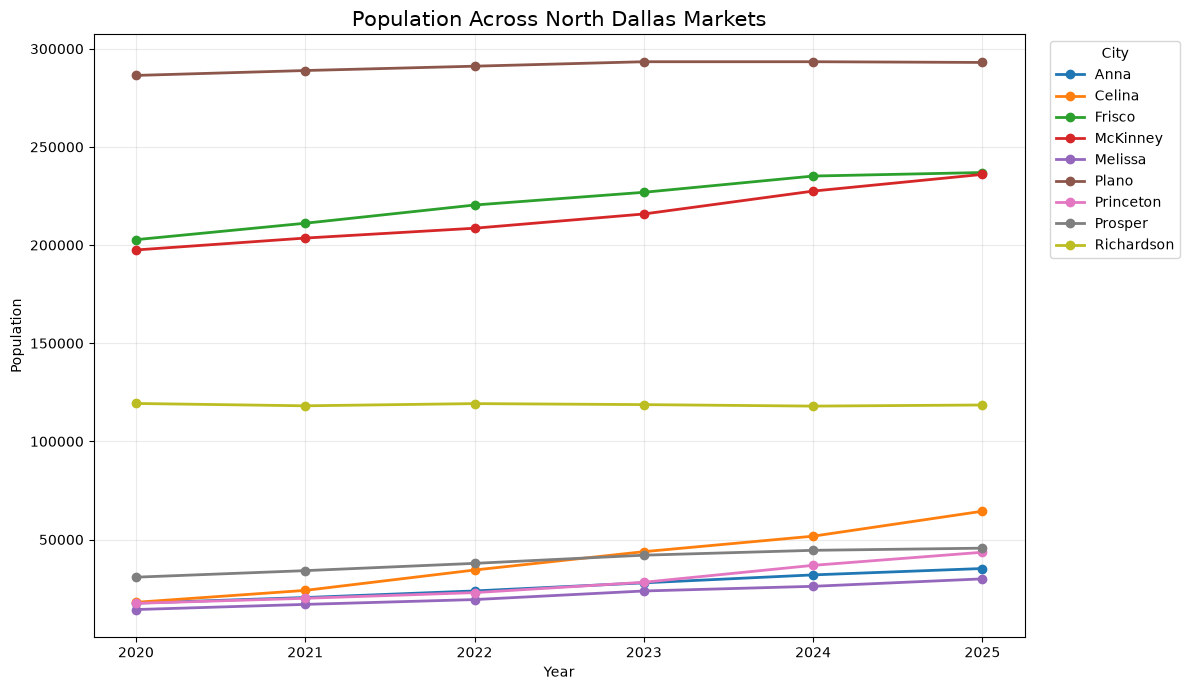

In [80]:
# POPULATION OVER TIME

fig, ax = plt.subplots(figsize=(12, 7))

for city in sorted(population_long["City"].unique()):

    city_data = population_long[
        population_long["City"] == city
    ]

    ax.plot(
        city_data["Year"],
        city_data["Population"],
        marker="o",
        linewidth=2,
        label=city
    )

ax.set_title(
    "Population Across North Dallas Markets",
    fontsize=15
)

ax.set_xlabel("Year")
ax.set_ylabel("Population")

ax.legend(
    title="City",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [81]:
# INDEX POPULATION TO 2020 = 100

population_long["Starting_Population"] = (
    population_long
    .groupby("City")["Population"]
    .transform("first")
)

population_long["Population_Index_2020"] = (
    population_long["Population"] / population_long["Starting_Population"] * 100
)

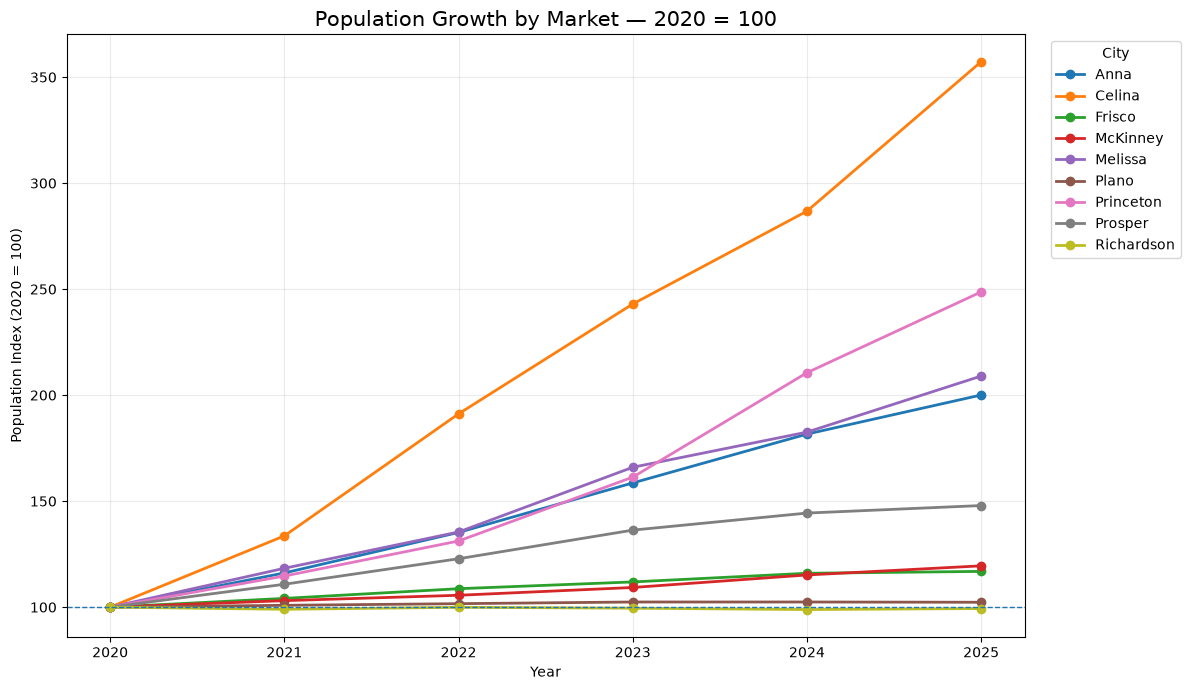

In [82]:
fig, ax = plt.subplots(figsize=(12, 7))

for city in sorted(population_long["City"].unique()):

    city_data = population_long[
        population_long["City"] == city
    ]

    ax.plot(
        city_data["Year"],
        city_data["Population_Index_2020"],
        marker="o",
        linewidth=2,
        label=city
    )

ax.axhline(
    100,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Population Growth by Market — 2020 = 100",
    fontsize=15
)

ax.set_xlabel("Year")
ax.set_ylabel("Population Index (2020 = 100)")

ax.legend(
    title="City",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

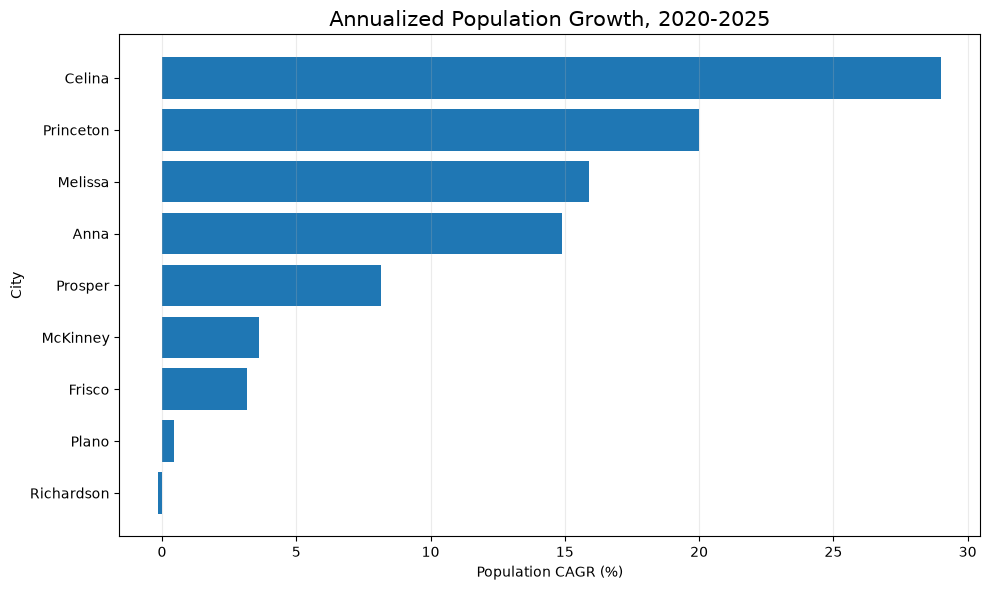

In [83]:
# POPULATION CAGR BY CITY

plot_data = population_summary.sort_values(
    "Population_CAGR_Pct"
)

fig, ax = plt.subplots(figsize=(10,6))

ax.barh(
    plot_data["City"],
    plot_data["Population_CAGR_Pct"]
)

ax.set_title("Annualized Population Growth, 2020-2025", fontsize=15)
ax.set_xlabel("Population CAGR (%)")
ax.set_ylabel("City")

ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

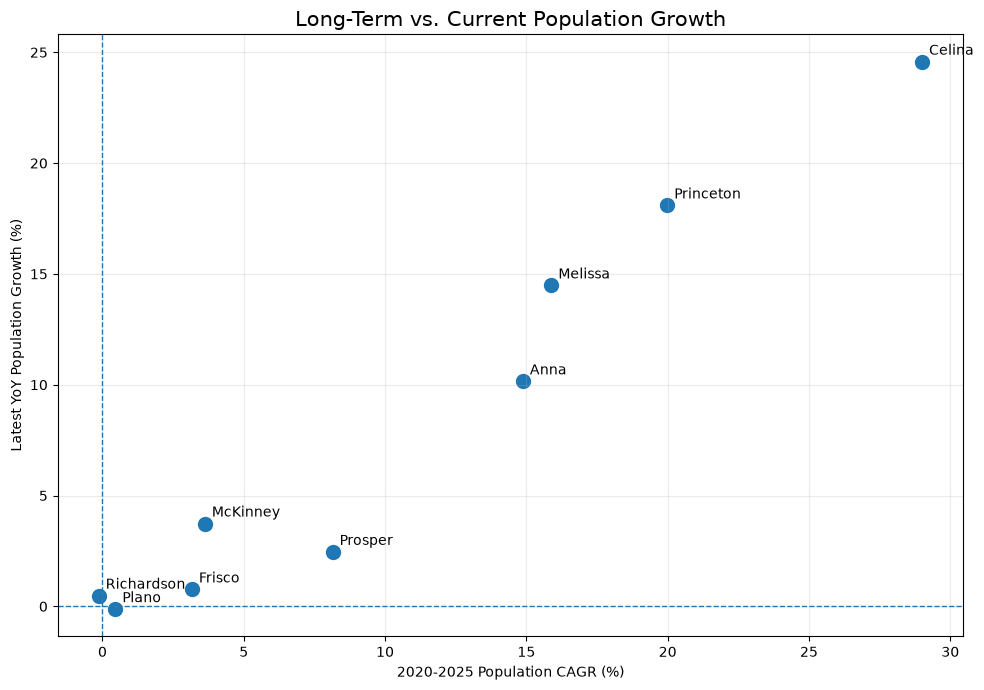

In [85]:
# LONG-TERM VS. CURRENT POPULATION GROWTH

fig, ax = plt.subplots(figsize=(10,7))

ax.scatter(
    population_summary["Population_CAGR_Pct"],
    population_summary["Latest_Population_YoY_Pct"],
    s=100
)

for _, row in population_summary.iterrows():
    ax.annotate(
        row["City"],
        (
            row["Population_CAGR_Pct"],
            row["Latest_Population_YoY_Pct"]
        ),
        xytext=(5,5),
        textcoords="offset points"
    )

ax.axhline(0, linestyle="--", linewidth=1)
ax.axvline(0, linestyle="--", linewidth=1)

ax.set_title("Long-Term vs. Current Population Growth", fontsize=15)
ax.set_xlabel("2020-2025 Population CAGR (%)")
ax.set_ylabel("Latest YoY Population Growth (%)")

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [86]:
# EXPORT CLEAN POPULATION DATA

POPULATION_FILE = (
    PROCESSED_DATA_DIR / "dallas_population_annual.csv"
)

population_long.to_csv(
    POPULATION_FILE, index=False
)

print("Saved:", POPULATION_FILE)
print("Shape:", population_long.shape)

Saved: /Users/ninahuang/Downloads/Personal/Projects/TX Market Analysis/tx_market_analysis/data/processed/dallas_population_annual.csv
Shape: (54, 8)


In [87]:
POPULATION_SUMMARY_FILE = (
    PROCESSED_DATA_DIR / "dallas_population_summary.csv"
)

population_summary.to_csv(
    POPULATION_SUMMARY_FILE, index=False
)

print("Saved:", POPULATION_SUMMARY_FILE)

Saved: /Users/ninahuang/Downloads/Personal/Projects/TX Market Analysis/tx_market_analysis/data/processed/dallas_population_summary.csv


## Demographic Growth Findings

Population growth reveals substantial differences in the long-term expansion of the nine North Dallas markets.

**Celina exhibits exceptional demographic expansion.** Its estimated population increased from approximately 18,000 in 2020 to more than 64,000 in 2025, representing total growth of approximately 257% and an annualized growth rate of 29%. Population growth also accelerated in the latest year.

**Princeton, Melissa, and Anna are also rapidly expanding markets.** Princeton's population increased approximately 149%, while Melissa and Anna approximately doubled in population between 2020 and 2025.

**Prosper continues to show substantial long-term growth**, although its latest annual growth rate is considerably slower than its earlier pace.

**McKinney and Frisco continue to add residents but at substantially lower percentage growth rates than the smaller outer-ring markets.** Their larger population bases mean that even moderate percentage growth can represent substantial absolute increases in residents.

**Plano represents the most mature demographic market in the comparison.** Population changed relatively little between 2025 and 2025 and declined slightly in the latest annual estimate.

**Richardson is also a mature, slow-growth market.** Its demographic profile is characterized by a large, established population base but relatively limited recent population expansion, making its investment thesis more dependent on market stability and existing demand than rapid population-driven growth.

In [89]:
# LOAD DATA

BPS_DIR = RAW_DATA_DIR / "bps"

for file in BPS_DIR.iterdir():
    print(file.name)

.DS_Store
footnote2025.xlsx
so2021a.txt
so2020a.txt
so2023a.txt
so2022a.txt
so2025a.txt
so2024a.txt


In [91]:
bps_2025_file = BPS_DIR / "so2025a.txt"

bps_2025_raw = pd.read_csv(bps_2025_file)

print("Shape:", bps_2025_raw.shape)
print("\nColumns:")
print(bps_2025_raw.columns.tolist())

bps_2025_raw.head()

Shape: (4459, 40)

Columns:
['Survey', 'State', '6-Digit', 'County', 'Census Place', 'FIPS Place', 'FIPS MCD', 'Pop', 'CSA', 'CBSA', 'Footnote', 'Central', 'Zip', 'Region', 'Division', 'Number of', 'Place', 'Unnamed: 17', '1-unit', 'Unnamed: 19', 'Unnamed: 20', '2-units', 'Unnamed: 22', 'Unnamed: 23', '3-4 units', 'Unnamed: 25', 'Unnamed: 26', '5+ units', 'Unnamed: 28', 'Unnamed: 29', '1-unit rep', 'Unnamed: 31', 'Unnamed: 32', '2-units rep', 'Unnamed: 34', 'Unnamed: 35', '3-4 units rep', 'Unnamed: 37', 'Unnamed: 38', '5+ units rep']


,Survey,State,6-Digit,County,Census Place,FIPS Place,FIPS MCD,Pop,CSA,CBSA,Footnote,Central,Zip,Region,Division,Number of,Place,Unnamed: 17,1-unit,Unnamed: 19,Unnamed: 20,2-units,Unnamed: 22,Unnamed: 23,3-4 units,Unnamed: 25,Unnamed: 26,5+ units,Unnamed: 28,Unnamed: 29,1-unit rep,Unnamed: 31,Unnamed: 32,2-units rep,Unnamed: 34,Unnamed: 35,3-4 units rep,Unnamed: 37,Unnamed: 38,5+ units rep
Date,Code,ID,Code,Code,Code,Code,,Code,Code,Code,City,Code,Code,Code,Months Rep,Name,Bldgs,Units,Value,Bldgs,Units,Value,Bldgs,Units,Value,Bldgs,Units,Value,Bldgs,Units,Value,Bldgs,Units,Value,Bldgs,Units,Value,Bldgs,Units,Value
2025,01,001000,067,0020,00124,00000,2553,222,20020,,,36310,3,6,12,Abbeville,40,40,11840668,0,0,0,0,0,0,0,0,0,40,40,11840668,0,0,0,0,0,0,0,0,0
2025,01,002000,073,0030,00460,00000,4211,142,13820,,,35005,3,6,0,Adamsville,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2025,01,005000,117,0025,00820,00000,33701,142,13820,,,35007,3,6,12,Alabaster,86,86,17929261,0,0,0,0,0,0,0,0,0,86,86,17929261,0,0,0,0,0,0,0,0,0
2025,01,006000,095,0030,00988,00000,21777,290,10700,,2,35950,3,6,12,Albertville,95,95,17901072,3,6,550000,0,0,0,0,0,0,95,95,17901072,3,6,550000,0,0,0,0,0,0


In [92]:
# INSPECT BPS COLUMN POSITIONS

for i, col in enumerate(bps_2025_raw.columns):
    print(i, col)

0 Survey
1 State
2 6-Digit
3 County
4 Census Place
5 FIPS Place
6 FIPS MCD
7 Pop
8 CSA
9 CBSA
10 Footnote
11 Central
12 Zip
13 Region
14 Division
15 Number of
16 Place
17 Unnamed: 17
18 1-unit
19 Unnamed: 19
20 Unnamed: 20
21 2-units
22 Unnamed: 22
23 Unnamed: 23
24 3-4 units
25 Unnamed: 25
26 Unnamed: 26
27 5+ units
28 Unnamed: 28
29 Unnamed: 29
30 1-unit rep
31 Unnamed: 31
32 Unnamed: 32
33 2-units rep
34 Unnamed: 34
35 Unnamed: 35
36 3-4 units rep
37 Unnamed: 37
38 Unnamed: 38
39 5+ units rep


In [93]:
# RELOAD BPS DATA WITHOUT MULTI-ROW HEADER

bps_2025_file = BPS_DIR / "so2025a.txt"

bps_2025_raw = pd.read_csv(
    bps_2025_file, header=None, skiprows=3
)

print("Shape:", bps_2025_raw.shape)
bps_2025_raw.head()

Shape: (4458, 41)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40
0,2025,1,1000,67,0020,124,0,2553,222,20020,,,36310,3,6,12,Abbeville,40,40,11840668,0,0,0,0,0,0,0,0,0,40,40,11840668,0,0,0,0,0,0,0,0,0
1,2025,1,2000,73,0030,460,0,4211,142,13820,,,35005,3,6,0,Adamsville,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2025,1,5000,117,0025,820,0,33701,142,13820,,,35007,3,6,12,Alabaster,86,86,17929261,0,0,0,0,0,0,0,0,0,86,86,17929261,0,0,0,0,0,0,0,0,0
3,2025,1,6000,95,0030,988,0,21777,290,10700,,2,35950,3,6,12,Albertville,95,95,17901072,3,6,550000,0,0,0,0,0,0,95,95,17901072,3,6,550000,0,0,0,0,0,0
4,2025,1,7000,123,0035,1132,0,14142,194,10760,,2,350100552,3,6,12,Alexander City,66,66,64632324,0,0,0,0,0,0,0,0,0,66,66,64632324,0,0,0,0,0,0,0,0,0


In [94]:
# RENAME BPS COLUMNS

bps_2025 = bps_2025_raw.copy()

bps_2025.columns = [
    # Geography / Metadata
    "Survey_Year",
    "State_Code",
    "BPO_ID",
    "County_Code",
    "Census_Place_Code",
    "FIPS_Place_Code",
    "FIPS_MCD_Code",
    "Population",
    "CSA_Code",
    "CBSA_Code",
    "Footnote_Code",
    "Central_City_Code",
    "Zip_Code",
    "Region_Code",
    "Division_Code",
    "Months_Reporting",
    "Place_Name",

    # Reporting + Imputed Estimates
    "One_Unit_Buildings",
    "One_Unit_Units",
    "One_Unit_Value",

    "Two_Unit_Buildings",
    "Two_Unit_Units",
    "Two_Unit_Value",

    "Three_Four_Unit_Buildings",
    "Three_Four_Unit_Units",
    "Three_Four_Unit_Value",

    "Five_Plus_Unit_Buildings",
    "Five_Plus_Unit_Units",
    "Five_Plus_Unit_Value",

    # Reported-only values
    "One_Unit_Rep_Buildings",
    "One_Unit_Rep_Units",
    "One_Unit_Rep_Value",

    "Two_Unit_Rep_Buildings",
    "Two_Unit_Rep_Units",
    "Two_Unit_Rep_Value",

    "Three_Four_Rep_Buildings",
    "Three_Four_Rep_Units",
    "Three_Four_Rep_Value",

    "Five_Plus_Rep_Buildings",
    "Five_Plus_Rep_Units",
    "Five_Plus_Rep_Value",
]

print("Rows:", len(bps_2025))
print("Columns:", len(bps_2025.columns))

bps_2025.head()

Rows: 4458
Columns: 41


,Survey_Year,State_Code,BPO_ID,County_Code,Census_Place_Code,FIPS_Place_Code,FIPS_MCD_Code,Population,CSA_Code,CBSA_Code,Footnote_Code,Central_City_Code,Zip_Code,Region_Code,Division_Code,Months_Reporting,Place_Name,One_Unit_Buildings,One_Unit_Units,One_Unit_Value,Two_Unit_Buildings,Two_Unit_Units,Two_Unit_Value,Three_Four_Unit_Buildings,Three_Four_Unit_Units,Three_Four_Unit_Value,Five_Plus_Unit_Buildings,Five_Plus_Unit_Units,Five_Plus_Unit_Value,One_Unit_Rep_Buildings,One_Unit_Rep_Units,One_Unit_Rep_Value,Two_Unit_Rep_Buildings,Two_Unit_Rep_Units,Two_Unit_Rep_Value,Three_Four_Rep_Buildings,Three_Four_Rep_Units,Three_Four_Rep_Value,Five_Plus_Rep_Buildings,Five_Plus_Rep_Units,Five_Plus_Rep_Value
0,2025,1,1000,67,0020,124,0,2553,222,20020,,,36310,3,6,12,Abbeville,40,40,11840668,0,0,0,0,0,0,0,0,0,40,40,11840668,0,0,0,0,0,0,0,0,0
1,2025,1,2000,73,0030,460,0,4211,142,13820,,,35005,3,6,0,Adamsville,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2025,1,5000,117,0025,820,0,33701,142,13820,,,35007,3,6,12,Alabaster,86,86,17929261,0,0,0,0,0,0,0,0,0,86,86,17929261,0,0,0,0,0,0,0,0,0
3,2025,1,6000,95,0030,988,0,21777,290,10700,,2,35950,3,6,12,Albertville,95,95,17901072,3,6,550000,0,0,0,0,0,0,95,95,17901072,3,6,550000,0,0,0,0,0,0
4,2025,1,7000,123,0035,1132,0,14142,194,10760,,2,350100552,3,6,12,Alexander City,66,66,64632324,0,0,0,0,0,0,0,0,0,66,66,64632324,0,0,0,0,0,0,0,0,0


In [95]:
# FILTER TEXAS

bps_tx_2025 = bps_2025[
    pd.to_numeric(
        bps_2025["State_Code"],
        errors="coerce"
    ) == 48
].copy()

print("Texas permit-office records:", len(bps_tx_2025))

bps_tx_2025[
    [
        "Place_Name",
        "County_Code",
        "One_Unit_Units",
        "Two_Unit_Units",
        "Three_Four_Unit_Units",
        "Five_Plus_Unit_Units"
    ]
].head(20)

Texas permit-office records: 987


,Place_Name,County_Code,One_Unit_Units,Two_Unit_Units,Three_Four_Unit_Units,Five_Plus_Unit_Units
3096,Abernathy,189,5,0,0,0
3097,Abilene,441,696,324,0,0
3098,Addison town,113,34,0,0,0
3099,Alamo,215,90,0,0,0
3100,Alamo Heights,29,0,0,0,0
3101,Aledo,367,63,0,0,0
3102,Alice,249,2,0,0,0
3103,Allen,85,269,0,0,759
3104,Alpine,43,0,0,3,0
3105,Alton,215,144,80,0,0


In [96]:
# SEARCH TARGET BPS PLACES

bps_matches = bps_tx_2025[
    bps_tx_2025["Place_Name"]
    .astype(str)
    .str.contains(
        "|".join(TARGET_CITIES),
        case=False,
        na=False
    )
].copy()

bps_matches[
    [
        "Place_Name",
        "BPO_ID",
        "County_Code",
        "Months_Reporting",
        "One_Unit_Units",
        "Two_Unit_Units",
        "Three_Four_Unit_Units",
        "Five_Plus_Unit_Units"
    ]
].sort_values("Place_Name")

,Place_Name,BPO_ID,County_Code,Months_Reporting,One_Unit_Units,Two_Unit_Units,Three_Four_Unit_Units,Five_Plus_Unit_Units
3115,Anna,19000,85,12,864,0,0,0
3242,Celina,117500,85,12,2489,0,0,314
3405,Frisco,246500,85,12,1090,0,0,4562
3672,McKinney,448000,85,12,1649,0,0,1391
3677,Melissa,453000,85,12,553,0,0,0
3795,Plano,553500,85,12,138,0,0,175
3818,Princeton,569000,85,12,1598,12,0,0
3821,Prosper town,570000,85,12,261,0,0,0
3842,Richardson,587500,113,12,56,0,0,621
3882,San Leanna village,623500,453,0,8,0,0,0


In [97]:
# CLEAN BPS PLACE NAMES

bps_tx_2025["City"] = (
    bps_tx_2025["Place_Name"]
    .astype(str)
    .str.replace(" city", "", regex=False)
    .str.replace(" town", "", regex=False)
    .str.replace(" village", "", regex=False)
    .str.strip()
)

bps_target_2025 = bps_tx_2025[
    bps_tx_2025["City"].isin(TARGET_CITIES)
].copy()

bps_target_2025[
    [
        "City",
        "Place_Name",
        "BPO_ID",
        "Months_Reporting",
        "One_Unit_Units",
        "Two_Unit_Units",
        "Three_Four_Unit_Units",
        "Five_Plus_Unit_Units"
    ]
].sort_values("City")

,City,Place_Name,BPO_ID,Months_Reporting,One_Unit_Units,Two_Unit_Units,Three_Four_Unit_Units,Five_Plus_Unit_Units
3115,Anna,Anna,19000,12,864,0,0,0
3242,Celina,Celina,117500,12,2489,0,0,314
3405,Frisco,Frisco,246500,12,1090,0,0,4562
3672,McKinney,McKinney,448000,12,1649,0,0,1391
3677,Melissa,Melissa,453000,12,553,0,0,0
3795,Plano,Plano,553500,12,138,0,0,175
3818,Princeton,Princeton,569000,12,1598,12,0,0
3821,Prosper,Prosper town,570000,12,261,0,0,0
3842,Richardson,Richardson,587500,12,56,0,0,621


In [98]:
# VALIDATE

print("Target cities found:", bps_target_2025["City"].nunique())
print("Target records:", len(bps_target_2025))
print("\nCities found:")

for city in sorted(bps_target_2025["City"].unique()):
    print("-", city)

print(
    "\nCities missing:",
    sorted(set(TARGET_CITIES) - set(bps_target_2025["City"]))
)

Target cities found: 9
Target records: 9

Cities found:
- Anna
- Celina
- Frisco
- McKinney
- Melissa
- Plano
- Princeton
- Prosper
- Richardson

Cities missing: []


In [105]:
# CALCULATE 2025 RESIDENTIAL UNITS PERMITTED

# Total units permitted
bps_target_2025["Total_Units_Permitted"] = (
    bps_target_2025["One_Unit_Units"]
    + bps_target_2025["Two_Unit_Units"]
    + bps_target_2025["Three_Four_Unit_Units"]
    + bps_target_2025["Five_Plus_Unit_Units"]
)

# Single-family = one-unit structures
bps_target_2025["Single_Family_Units"] = (
    bps_target_2025["One_Unit_Units"]
)

# Multifamily = 2-unit + 3–4-unit + 5+ unit structures
bps_target_2025["Multifamily_Units"] = (
    bps_target_2025["Two_Unit_Units"]
    + bps_target_2025["Three_Four_Unit_Units"]
    + bps_target_2025["Five_Plus_Unit_Units"]
)

# Single-family share of all permitted units
bps_target_2025["Single_Family_Share_Pct"] = (
    bps_target_2025["Single_Family_Units"]
    / bps_target_2025["Total_Units_Permitted"]
    * 100
)

bps_target_2025[
    [
        "City",
        "Total_Units_Permitted",
        "Single_Family_Units",
        "Multifamily_Units",
        "Single_Family_Share_Pct"
    ]
].sort_values(
    "Total_Units_Permitted",
    ascending=False
).round(2)

,City,Total_Units_Permitted,Single_Family_Units,Multifamily_Units,Single_Family_Share_Pct
3405,Frisco,5652,1090,4562,19.29
3672,McKinney,3040,1649,1391,54.24
3242,Celina,2803,2489,314,88.80
3818,Princeton,1610,1598,12,99.25
3115,Anna,864,864,0,100.00
3842,Richardson,677,56,621,8.27
3677,Melissa,553,553,0,100.00
3795,Plano,313,138,175,44.09
3821,Prosper,261,261,0,100.00


In [107]:
bps_2025_summary = (
    bps_target_2025[
        [
            "City",
            "Total_Units_Permitted",
            "Single_Family_Units",
            "Multifamily_Units",
            "Single_Family_Share_Pct"
        ]
    ]
    .sort_values("Total_Units_Permitted", ascending=False)
)

bps_2025_summary.round(2)

,City,Total_Units_Permitted,Single_Family_Units,Multifamily_Units,Single_Family_Share_Pct
3405,Frisco,5652,1090,4562,19.29
3672,McKinney,3040,1649,1391,54.24
3242,Celina,2803,2489,314,88.80
3818,Princeton,1610,1598,12,99.25
3115,Anna,864,864,0,100.00
3842,Richardson,677,56,621,8.27
3677,Melissa,553,553,0,100.00
3795,Plano,313,138,175,44.09
3821,Prosper,261,261,0,100.00


In [108]:
# ADD 2025 POPULATION

population_2025 = (
    population_long[
        population_long["Year"] == 2025
    ][
        [
            "City",
            "Population"
        ]
    ]
    .copy()
)

bps_2025_summary = bps_2025_summary.merge(
    population_2025, on="City", how="left"
)

bps_2025_summary["Permits_Per_1000_Residents"] = (
    bps_2025_summary["Total_Units_Permitted"] / bps_2025_summary["Population"] * 1000
)

bps_2025_summary[
    [
        "City",
        "Population",
        "Total_Units_Permitted",
        "Permits_Per_1000_Residents",
        "Single_Family_Units",
        "Multifamily_Units",
        "Single_Family_Share_Pct"
    ]
].sort_values("Permits_Per_1000_Residents", ascending=False).round(2)

,City,Population,Total_Units_Permitted,Permits_Per_1000_Residents,Single_Family_Units,Multifamily_Units,Single_Family_Share_Pct
2,Celina,"64,427.00",2803,43.51,2489,314,88.80
3,Princeton,"43,524.00",1610,36.99,1598,12,99.25
4,Anna,"35,245.00",864,24.51,864,0,100.00
0,Frisco,"236,955.00",5652,23.85,1090,4562,19.29
6,Melissa,"29,969.00",553,18.45,553,0,100.00
1,McKinney,"236,001.00",3040,12.88,1649,1391,54.24
8,Prosper,"45,605.00",261,5.72,261,0,100.00
5,Richardson,"118,542.00",677,5.71,56,621,8.27
7,Plano,"293,028.00",313,1.07,138,175,44.09


In [ ]:
# REUSABLE BPS ANNUAL LOADER

BPS_COLUMNS = [
    "Survey_Year",
    "State_Code",
    "BPO_ID",
    "County_Code",
    "Census_Place_Code",
    "FIPS_Place_Code",
    "FIPS_MCD_Code",
    "Population",
    "CSA_Code",
    "CBSA_Code",
    "Footnote_Code",
    "Central_City_Code",
    "Zip_Code",
    "Region_Code",
    "Division_Code",
    "Months_Reporting",
    "Place_Name",
    "One_Unit_Buildings",
    "One_Unit_Units",
    "One_Unit_Value",
    "Two_Unit_Buildings",
    "Two_Unit_Units",
    "Two_Unit_Value",
    "Three_Four_Unit_Buildings",
    "Three_Four_Unit_Units",
    "Three_Four_Unit_Value",
    "Five_Plus_Unit_Buildings",
    "Five_Plus_Unit_Units",
    "Five_Plus_Unit_Value",
    "One_Unit_Rep_Buildings",
    "One_Unit_Rep_Units",
    "One_Unit_Rep_Value",
    "Two_Unit_Rep_Buildings",
    "Two_Unit_Rep_Units",
    "Two_Unit_Rep_Value",
    "Three_Four_Rep_Buildings",
    "Three_Four_Rep_Units",
    "Three_Four_Rep_Value",
    "Five_Plus_Rep_Buildings",
    "Five_Plus_Rep_Units",
    "Five_Plus_Rep_Value",
]


def load_bps_annual(year):
    file = BPS_DIR / f"so{year}a.txt"

    df_bps = pd.read_csv(
        file,
        header=None,
        skiprows=3
    )

    if df_bps.shape[1] != len(BPS_COLUMNS):
        raise ValueError(
            f"{year}: expected {len(BPS_COLUMNS)} columns, "
            f"found {df_bps.shape[1]}"
        )

    df_bps.columns = BPS_COLUMNS

    # Texas only
    df_bps = df_bps[
        pd.to_numeric(
            df_bps["State_Code"],
            errors="coerce"
        ) == 48
    ].copy()

    # Clean place names
    df_bps["City"] = (
        df_bps["Place_Name"]
        .astype(str)
        .str.replace(" city", "", regex=False)
        .str.replace(" town", "", regex=False)
        .str.replace(" village", "", regex=False)
        .str.strip()
    )

    # Target cities only
    df_bps = df_bps[
        df_bps["City"].isin(TARGET_CITIES)
    ].copy()

    # Convert permit fields to numeric
    permit_cols = [
        "One_Unit_Units",
        "Two_Unit_Units",
        "Three_Four_Unit_Units",
        "Five_Plus_Unit_Units"
    ]

    for col in permit_cols:
        df_bps[col] = pd.to_numeric(
            df_bps[col],
            errors="coerce"
        )

    # Create construction metrics
    df_bps["Single_Family_Units"] = (
        df_bps["One_Unit_Units"]
    )

    df_bps["Multifamily_Units"] = (
        df_bps["Two_Unit_Units"]
        + df_bps["Three_Four_Unit_Units"]
        + df_bps["Five_Plus_Unit_Units"]
    )

    df_bps["Total_Units_Permitted"] = (
        df_bps["Single_Family_Units"]
        + df_bps["Multifamily_Units"]
    )

    df_bps["Single_Family_Share_Pct"] = np.where(
        df_bps["Total_Units_Permitted"] > 0,
        (
            df_bps["Single_Family_Units"]
            / df_bps["Total_Units_Permitted"]
            * 100
        ),
        np.nan
    )

    df_bps["Year"] = year

    return df_bps[
        [
            "City",
            "Year",
            "Months_Reporting",
            "Single_Family_Units",
            "Multifamily_Units",
            "Total_Units_Permitted",
            "Single_Family_Share_Pct"
        ]
    ]

In [116]:
# LOAD 2020-2025 BPS DATA

bps_frames = []

for year in range(2020, 2026):
    yearly_data = load_bps_annual(year)
    bps_frames.append(yearly_data)

bps_long = pd.concat(
    bps_frames,
    ignore_index=True
)

bps_long = (
    bps_long
    .sort_values(["City", "Year"])
    .reset_index(drop=True)
)

bps_long.head(15)

,City,Year,Months_Reporting,Single_Family_Units,Multifamily_Units,Total_Units_Permitted,Single_Family_Share_Pct
0,Anna,2020,12,960,0,960,100.00
1,Anna,2021,12,1121,0,1121,100.00
2,Anna,2022,12,907,539,1446,62.72
3,Anna,2023,12,1089,317,1406,77.45
4,Anna,2024,12,1173,0,1173,100.00
5,Anna,2025,12,864,0,864,100.00
6,Celina,2020,12,2003,30,2033,98.52
7,Celina,2021,12,2825,624,3449,81.91
8,Celina,2022,12,1650,1546,3196,51.63
9,Celina,2023,10,2467,229,2696,91.51


In [118]:
# VALIDATE BPS PANEL

print("Cities:", bps_long["City"].nunique())
print("Years:", sorted(bps_long["Year"].unique()))
print("Observations:", len(bps_long))

print(
    "Duplicate city-years:",
    bps_long.duplicated(
        subset=["City", "Year"]
    ).sum()
)

print(
    "Missing total permits:",
    bps_long["Total_Units_Permitted"].isna().sum()
)

print("\nRecords by city:")
print(
    bps_long.groupby("City").size()
)

Cities: 9
Years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Observations: 54
Duplicate city-years: 0
Missing total permits: 0

Records by city:
City
Anna          6
Celina        6
Frisco        6
McKinney      6
Melissa       6
Plano         6
Princeton     6
Prosper       6
Richardson    6
dtype: int64


In [119]:
# CHECK BPS REPORTING COVERAGE

reporting_check = (
    bps_long[
        [
            "City",
            "Year",
            "Months_Reporting"
        ]
    ]
    .pivot(
        index="City",
        columns="Year",
        values="Months_Reporting"
    )
)

reporting_check

Year,2020,2021,2022,2023,2024,2025
City,,,,,,
Anna,12,12,12,12,12,12
Celina,12,12,12,10,12,12
Frisco,12,12,12,12,12,12
McKinney,12,12,12,12,12,12
Melissa,12,12,12,12,12,12
Plano,12,12,12,12,12,12
Princeton,0,0,12,12,12,12
Prosper,12,12,12,12,12,12
Richardson,12,12,12,12,12,12


In [120]:
# ANNUAL RESIDENTIAL UNITS PERMITTED

permit_pivot = (
    bps_long
    .pivot(
        index="City",
        columns="Year",
        values="Total_Units_Permitted"
    )
)

permit_pivot

Year,2020,2021,2022,2023,2024,2025
City,,,,,,
Anna,960,1121,1446,1406,1173,864
Celina,2033,3449,3196,2696,4357,2803
Frisco,3179,3390,2896,3400,1333,5652
McKinney,2302,1727,3315,4802,3910,3040
Melissa,857,784,1474,802,1295,553
Plano,976,668,1777,496,799,313
Princeton,823,916,1784,2882,2278,1610
Prosper,1115,1220,1473,877,472,261
Richardson,45,751,92,26,790,677


In [122]:
# MERGE POPULATION WITH BPS

bps_population = bps_long.merge(
    population_long[
        [
            "City",
            "Year",
            "Population"
        ]
    ],
    on=["City", "Year"],
    how="left"
)

bps_population["Permits_Per_1000_Residents"] = (
    bps_population["Total_Units_Permitted"] / bps_population["Population"] * 1000
)

bps_population[
    [
        "City",
        "Year",
        "Population",
        "Total_Units_Permitted",
        "Permits_Per_1000_Residents"
    ]
].head(20).round(2)

,City,Year,Population,Total_Units_Permitted,Permits_Per_1000_Residents
0,Anna,2020,"17,616.00",960,54.50
1,Anna,2021,"20,459.00",1121,54.79
2,Anna,2022,"23,825.00",1446,60.69
3,Anna,2023,"27,938.00",1406,50.33
4,Anna,2024,"31,996.00",1173,36.66
5,Anna,2025,"35,245.00",864,24.51
6,Celina,2020,"18,033.00",2033,112.74
7,Celina,2021,"24,097.00",3449,143.13
8,Celina,2022,"34,476.00",3196,92.70
9,Celina,2023,"43,820.00",2696,61.52


In [123]:
# YEAR-OVER-YEAR PERMIT GROWTH

bps_population["Permits_YoY_Pct"] = (
    bps_population
    .groupby("City")["Total_Units_Permitted"]
    .pct_change() * 100
)

In [124]:
# CONSTRUCTION FUNDAMENTALS SUMMARY

construction_summary = (
    bps_population
    .groupby("City")
    .agg(
        Total_Permits_2020_2025=(
            "Total_Units_Permitted",
            "sum"
        ),
        Avg_Annual_Permits=(
            "Total_Units_Permitted",
            "mean"
        ),
        Avg_Permits_Per_1000=(
            "Permits_Per_1000_Residents",
            "mean"
        ),
        Latest_Permits=(
            "Total_Units_Permitted",
            "last"
        ),
        Latest_Permits_Per_1000=(
            "Permits_Per_1000_Residents",
            "last"
        ),
        Latest_SF_Share_Pct=(
            "Single_Family_Share_Pct",
            "last"
        )
    )
    .reset_index()
)

construction_summary.sort_values(
    "Avg_Permits_Per_1000", ascending=False
).round(2)

,City,Total_Permits_2020_2025,Avg_Annual_Permits,Avg_Permits_Per_1000,Latest_Permits,Latest_Permits_Per_1000,Latest_SF_Share_Pct
1,Celina,18534,"3,089.00",89.64,2803,43.51,88.80
6,Princeton,10293,"1,715.50",61.87,1610,36.99,99.25
4,Melissa,5765,960.83,47.25,553,18.45,100.00
0,Anna,6970,"1,161.67",46.91,864,24.51,100.00
7,Prosper,5418,903.00,24.66,261,5.72,100.00
2,Frisco,19850,"3,308.33",14.90,5652,23.85,19.29
3,McKinney,19096,"3,182.67",14.72,3040,12.88,54.24
8,Richardson,2381,396.83,3.36,677,5.71,8.27
5,Plano,5029,838.17,2.88,313,1.07,44.09


In [125]:
# BPS REPORTING QUALITY FLAG

bps_population["Reporting_Status"] = np.select(
    [
        bps_population["Months_Reporting"] == 12,
        bps_population["Months_Reporting"].between(1, 11),
        bps_population["Months_Reporting"] == 0
    ],
    [
        "Full 12-Month Reporting",
        "Partial Reporting / Annual Estimate",
        "No Monthly Reports / Annual Estimate"
    ],
    default="Unknown"
)

bps_population[
    [
        "City",
        "Year",
        "Months_Reporting",
        "Reporting_Status",
        "Total_Units_Permitted"
    ]
][
    bps_population["Months_Reporting"] < 12
]

,City,Year,Months_Reporting,Reporting_Status,Total_Units_Permitted
9,Celina,2023,10,Partial Reporting / Annual Estimate,2696
36,Princeton,2020,0,No Monthly Reports / Annual Estimate,823
37,Princeton,2021,0,No Monthly Reports / Annual Estimate,916


In [126]:
# PEAK CONSTRUCTION INTENSITY

peak_construction = (
    bps_population.loc[
        bps_population
        .groupby("City")["Permits_Per_1000_Residents"]
        .idxmax(),
        [
            "City",
            "Year",
            "Permits_Per_1000_Residents"
        ]
    ]
    .rename(
        columns={
            "Year": "Peak_Construction_Year",
            "Permits_Per_1000_Residents": "Peak_Permits_Per_1000"
        }
    )
)

latest_construction = (
    bps_population[
        bps_population["Year"] == 2025
    ][
        [
            "City",
            "Permits_Per_1000_Residents"
        ]
    ]
    .rename(
        columns={
            "Permits_Per_1000_Residents": "Latest_Permits_Per_1000"
        }
    )
)

construction_peak_summary = peak_construction.merge(
    latest_construction,
    on="City",
    how="left"
)

construction_peak_summary[
    "Change_From_Construction_Peak_Pct"
] = (
    (
        construction_peak_summary["Latest_Permits_Per_1000"] / construction_peak_summary["Peak_Permits_Per_1000"]
    ) - 1
) * 100

construction_peak_summary.sort_values(
    "Change_From_Construction_Peak_Pct"
).round(2)

,City,Peak_Construction_Year,Peak_Permits_Per_1000,Latest_Permits_Per_1000,Change_From_Construction_Peak_Pct
7,Prosper,2022,38.90,5.72,-85.29
5,Plano,2022,6.10,1.07,-82.50
4,Melissa,2022,75.89,18.45,-75.69
1,Celina,2021,143.13,43.51,-69.60
6,Princeton,2023,102.08,36.99,-63.76
0,Anna,2022,60.69,24.51,-59.61
3,McKinney,2023,22.25,12.88,-42.10
8,Richardson,2024,6.70,5.71,-14.72
2,Frisco,2025,23.85,23.85,0.00


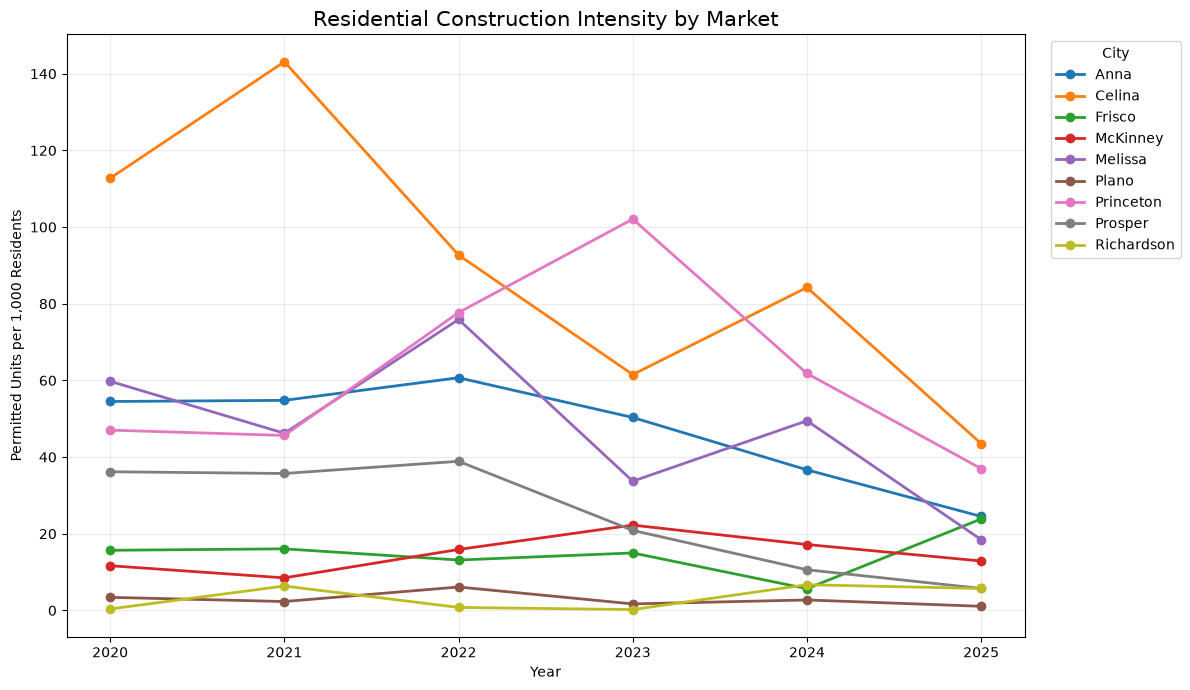

In [128]:
fig, ax = plt.subplots(figsize=(12,7))

for city in sorted(
    bps_population["City"].unique()
):
    city_data = bps_population[
        bps_population["City"] == city
    ]

    ax.plot(
        city_data["Year"],
        city_data["Permits_Per_1000_Residents"],
        marker="o",
        linewidth=2,
        label=city
    )

ax.set_title("Residential Construction Intensity by Market", fontsize=15)
ax.set_xlabel("Year")
ax.set_ylabel("Permitted Units per 1,000 Residents")

ax.legend(
    title="City",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


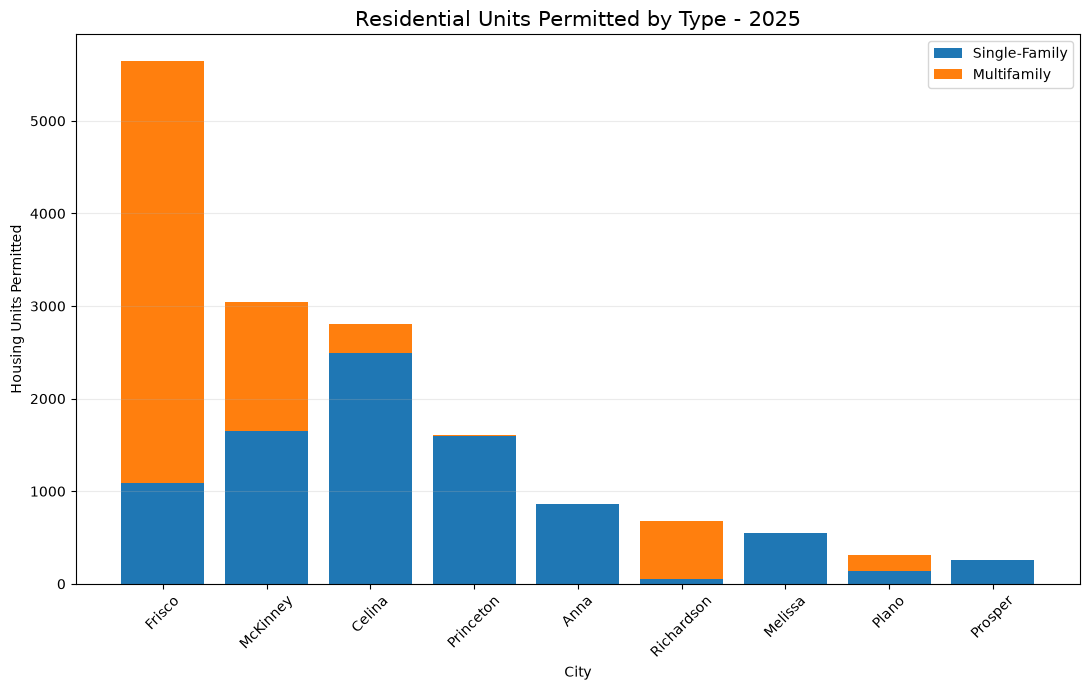

In [129]:
# 2025 PERMIT MIX

permit_mix_2025 = (
    bps_population[
        bps_population["Year"] == 2025
    ]
    .sort_values("Total_Units_Permitted", ascending=False)
)

fig, ax = plt.subplots(figsize=(11,7))

ax.bar(
    permit_mix_2025["City"],
    permit_mix_2025["Single_Family_Units"],
    label="Single-Family"
)

ax.bar(
    permit_mix_2025["City"],
    permit_mix_2025["Multifamily_Units"],
    bottom=permit_mix_2025["Single_Family_Units"],
    label="Multifamily"
)

ax.set_title("Residential Units Permitted by Type - 2025", fontsize=15)
ax.set_xlabel("City")
ax.set_ylabel("Housing Units Permitted")

ax.legend()

ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# SAVE PROCESSED FILES

BPS_PROCESSED_FILE = PROCESSED_DATA_DIR / "dallas_building_permits_annual.csv"

bps_population.to_csv(BPS_PROCESSED_FILE, index=False)

print("Saved:", BPS_PROCESSED_FILE)
print("Shape:", bps_population.shape)

Saved: /Users/ninahuang/Downloads/Personal/Projects/TX Market Analysis/tx_market_analysis/data/processed/dallas_building_permits_annual.csv
Shape: (54, 11)


In [131]:
CONSTRUCTION_SUMMARY_FILE = (
    PROCESSED_DATA_DIR / "dallas_construction_summary.csv"
)

construction_summary.to_csv(CONSTRUCTION_SUMMARY_FILE, index=False)

print("Saved:", CONSTRUCTION_SUMMARY_FILE)

Saved: /Users/ninahuang/Downloads/Personal/Projects/TX Market Analysis/tx_market_analysis/data/processed/dallas_construction_summary.csv


## Residential Construction Findings

Building-permit activity reveals substantial differences in both the intensity and composition of residential consutrction across the nine markets.

**Celina has experienced the highest sustained construction intensity in the comparison.** Approximately 18,500 residential units were permitted from 2020 through 2025, averaging nearly 90 permitted units per 1,000 residents annually. This construction boom occurred alongside exceptionally rapid population growth, indicating simultaneous expansion in both housing demand and supply.

**Princeton also experienced unusually high construction intensity**, averaging approximately 62 permitted units per 1,000 residents. Construction has moderated from its recent peak, while population growth remains strong and current transaction activity has accelerated.

**Anna and Melissa exhibit substantial single-family-oriented development.** Both markets have experienced rapid population growth alongside comparatively high residential construction rates.

**Frisco and McKinney generate high absolute permit volumes because of their much larger market sizes.** Their normalized construction rates are considerably lower than those of the smaller high-growth cities, and recent construction includes a substantially larger multifamily component.

**Richardson has relatively limited residential construction activity, consistent with its status as a mature, largely built-out market.** Unlike rapidly expanding outer suburbs such as Celina and Princeton, Richardson has less new housing supply entering the market, which limits supply-growth pressure but also provides less construction-driven capacity for future population expansion.

**Prosper's construction intensity has declined considerably from earlier levels**, while Plano exhibits very limited residential construction relative to its population, consistent with a more mature and built-out market.

Overall, the building-permit data suggest the recent home-price weakness in several high-growth North Dallas markets is occuring alongside substantial housing-supply expansion rather than demographic contraction. Construction indentisty has nevertheless moderated from earlier peaks in several of the fastest-growing markets.

## 10. Integrated Market Fundamentals

This section combines the home-value, demographic, residential-construction, and current housing-market indicators developed throughout the exploratory analysis.

The integrated dataset provides one standardized observation per market and serves as the foundation for the market-scoring methodology developed in the subsequent modeling notebook.

The variables are organized into four analytical dimensions:
1. **Historical Price Performance** - longer-term home-value appreciation and recent price trends
2. **Demographic Fundamentals** - population growth and recent demographic momentum
3. **Residential Construction** - the scale and intensity of new housing development
4. **Current Market Conditions** - transaction activity, inventory, supply, market speed, and pricing competitiveness

No composite scores or weights are assigned in this notebook. Those methodological decisions are developed separately after examining the relationships among the underlying indicators.

In [132]:
# INSPECT SUMMARY TABLES BEFORE INTEGRATION

print("PRICE SUMMARY COLUMNS")
print(final_price_summary.columns.tolist())

print("\nPOPULATION SUMMARY COLUMNS")
print(population_summary.columns.tolist())

print("\nCONSTRUCTION SUMMARY COLUMNS")
print(construction_summary.columns.tolist())

print("\nMARKET CONDITIONS COLUMNS")
print(market_conditions.columns.to_list())

PRICE SUMMARY COLUMNS
['City', 'Start_ZHVI', 'Latest_ZHVI', 'Total_Appreciation_Pct', 'Five_Yr_CAGR_Pct', 'Three_Yr_CAGR_Pct', 'Latest_YoY_Pct', 'Momentum_vs_3yr', 'Change_From_Peak_Pct', 'Months_Since_Peak', 'Current_Price_Trend']

POPULATION SUMMARY COLUMNS
['City', 'Start_Year', 'Latest_Year', 'Start_Population', 'Latest_Population', 'Population_Change', 'Total_Population_Growth_Pct', 'Years', 'Population_CAGR_Pct', 'Latest_Population_YoY_Pct', 'Population_Growth_Acceleration']

CONSTRUCTION SUMMARY COLUMNS
['City', 'Total_Permits_2020_2025', 'Avg_Annual_Permits', 'Avg_Permits_Per_1000', 'Latest_Permits', 'Latest_Permits_Per_1000', 'Latest_SF_Share_Pct']

MARKET CONDITIONS COLUMNS
['City', 'ZHVI_YoY_Pct', 'ZHVI_From_Peak_Pct', 'Homes_Sold_YoY_Pct', 'Inventory_YoY_Pct', 'Months_of_Supply', 'Median_DOM', 'DOM_YoY_Change', 'Sale_to_List_Pct', 'New_Listings_YoY_Pct', 'Pending_Sales_YoY_Pct']


In [133]:
# VERIFY ONE OBSERVATION PER CITY

summary_tables = {
    "Price": final_price_summary,
    "Population": population_summary,
    "Construction": construction_summary,
    "Market Conditions": market_conditions
}

for name, table in summary_tables.items():
    print(f"\n{name}")
    print("-" * 40)

    print("Rows:", len(table))
    print("Unique cities:", table["City"].nunique())
    print("Duplicate cities:", table["City"].duplicated().sum())
    print("Cities:", sorted(table["City"].unique()))


Price
----------------------------------------
Rows: 9
Unique cities: 9
Duplicate cities: 0
Cities: ['Anna', 'Celina', 'Frisco', 'McKinney', 'Melissa', 'Plano', 'Princeton', 'Prosper', 'Richardson']

Population
----------------------------------------
Rows: 9
Unique cities: 9
Duplicate cities: 0
Cities: ['Anna', 'Celina', 'Frisco', 'McKinney', 'Melissa', 'Plano', 'Princeton', 'Prosper', 'Richardson']

Construction
----------------------------------------
Rows: 9
Unique cities: 9
Duplicate cities: 0
Cities: ['Anna', 'Celina', 'Frisco', 'McKinney', 'Melissa', 'Plano', 'Princeton', 'Prosper', 'Richardson']

Market Conditions
----------------------------------------
Rows: 9
Unique cities: 9
Duplicate cities: 0
Cities: ['Anna', 'Celina', 'Frisco', 'McKinney', 'Melissa', 'Plano', 'Princeton', 'Prosper', 'Richardson']


In [134]:
# CHECK CITY COVERAGE ACROSS DATASETS

expected_cities = set(TARGET_CITIES)

for name, table in summary_tables.items():
    actual_cities = set(table["City"])

    missing = expected_cities - actual_cities
    extra = actual_cities - expected_cities

    print(f"\n{name}")

    print(
        "Missing:",
        sorted(missing) if missing else "None"
    )

    print(
        "Extra:",
        sorted(extra) if extra else "None"
    )


Price
Missing: None
Extra: None

Population
Missing: None
Extra: None

Construction
Missing: None
Extra: None

Market Conditions
Missing: None
Extra: None


In [135]:
# SELECT PRICE VARIABLES

price_master = final_price_summary[
    [
        "City",
        "Latest_ZHVI",
        "Total_Appreciation_Pct",
        "Five_Yr_CAGR_Pct",
        "Three_Yr_CAGR_Pct",
        "Latest_YoY_Pct",
        "Momentum_vs_3yr",
        "Change_From_Peak_Pct",
        "Months_Since_Peak"
    ]
].copy()

price_master = price_master.rename(
    columns={
        "Latest_YoY_Pct": "ZHVI_YoY_Pct",
        "Change_From_Peak_Pct": "ZHVI_From_Peak_Pct"
    }
)

price_master.round(2)

,City,Latest_ZHVI,Total_Appreciation_Pct,Five_Yr_CAGR_Pct,Three_Yr_CAGR_Pct,ZHVI_YoY_Pct,Momentum_vs_3yr,ZHVI_From_Peak_Pct,Months_Since_Peak
1,Richardson,"445,039.94",51.09,3.71,-0.39,-0.24,0.15,-4.48,25
5,Plano,"499,723.21",42.52,3.23,-2.21,-4.43,-2.22,-9.18,26
2,Frisco,"649,172.68",50.67,3.81,-1.87,-4.56,-2.69,-9.64,48
0,Prosper,"770,217.03",59.47,3.96,-1.99,-5.71,-3.72,-12.17,48
6,Melissa,"430,393.87",40.56,2.10,-3.63,-6.02,-2.39,-17.95,48
4,McKinney,"480,264.85",42.73,2.67,-3.23,-6.11,-2.89,-13.80,48
7,Anna,"345,077.93",31.91,1.01,-4.62,-7.08,-2.46,-20.84,48
3,Celina,"522,656.82",45.35,2.85,-3.60,-9.34,-5.73,-17.01,48
8,Princeton,"288,891.23",24.09,-0.35,-6.50,-10.23,-3.73,-25.12,47


In [137]:
# SELECT DEMOGRAPHIC VARIABLES

population_master = population_summary[
    [
        "City",
        "Latest_Population",
        "Population_Change",
        "Total_Population_Growth_Pct",
        "Population_CAGR_Pct",
        "Latest_Population_YoY_Pct",
        "Population_Growth_Acceleration"
    ]
].copy()

population_master.round(2)

,City,Latest_Population,Population_Change,Total_Population_Growth_Pct,Population_CAGR_Pct,Latest_Population_YoY_Pct,Population_Growth_Acceleration
0,Anna,"35,245.00","17,629.00",100.07,14.88,10.15,-4.37
1,Celina,"64,427.00","46,394.00",257.27,29.00,24.58,6.55
2,Frisco,"236,955.00","34,206.00",16.87,3.17,0.76,-2.89
3,McKinney,"236,001.00","38,494.00",19.49,3.63,3.74,-1.67
4,Melissa,"29,969.00","15,630.00",109.00,15.89,14.48,4.49
5,Plano,"293,028.00","6,614.00",2.31,0.46,-0.13,-0.13
6,Princeton,"43,524.00","26,023.00",148.69,19.99,18.09,-12.45
7,Prosper,"45,605.00","14,776.00",47.93,8.15,2.46,-3.45
8,Richardson,"118,542.00",-777.00,-0.65,-0.13,0.48,1.12


In [138]:
# SELECT CONSTRUCTION VARIABLES

construction_master = construction_summary[
    [
        "City",
        "Total_Permits_2020_2025",
        "Avg_Annual_Permits",
        "Avg_Permits_Per_1000",
        "Latest_Permits",
        "Latest_Permits_Per_1000",
        "Latest_SF_Share_Pct"
    ]
].copy()

construction_master.round(2)

,City,Total_Permits_2020_2025,Avg_Annual_Permits,Avg_Permits_Per_1000,Latest_Permits,Latest_Permits_Per_1000,Latest_SF_Share_Pct
0,Anna,6970,"1,161.67",46.91,864,24.51,100.00
1,Celina,18534,"3,089.00",89.64,2803,43.51,88.80
2,Frisco,19850,"3,308.33",14.90,5652,23.85,19.29
3,McKinney,19096,"3,182.67",14.72,3040,12.88,54.24
4,Melissa,5765,960.83,47.25,553,18.45,100.00
5,Plano,5029,838.17,2.88,313,1.07,44.09
6,Princeton,10293,"1,715.50",61.87,1610,36.99,99.25
7,Prosper,5418,903.00,24.66,261,5.72,100.00
8,Richardson,2381,396.83,3.36,677,5.71,8.27


In [139]:
construction_master = construction_master.merge(
    construction_peak_summary[
        [
            "City",
            "Peak_Construction_Year",
            "Peak_Permits_Per_1000",
            "Change_From_Construction_Peak_Pct"
        ]
    ],
    on="City",
    how="left",
    validate="one_to_one"
)

construction_master.round(2)

,City,Total_Permits_2020_2025,Avg_Annual_Permits,Avg_Permits_Per_1000,Latest_Permits,Latest_Permits_Per_1000,Latest_SF_Share_Pct,Peak_Construction_Year,Peak_Permits_Per_1000,Change_From_Construction_Peak_Pct
0,Anna,6970,"1,161.67",46.91,864,24.51,100.00,2022,60.69,-59.61
1,Celina,18534,"3,089.00",89.64,2803,43.51,88.80,2021,143.13,-69.60
2,Frisco,19850,"3,308.33",14.90,5652,23.85,19.29,2025,23.85,0.00
3,McKinney,19096,"3,182.67",14.72,3040,12.88,54.24,2023,22.25,-42.10
4,Melissa,5765,960.83,47.25,553,18.45,100.00,2022,75.89,-75.69
5,Plano,5029,838.17,2.88,313,1.07,44.09,2022,6.10,-82.50
6,Princeton,10293,"1,715.50",61.87,1610,36.99,99.25,2023,102.08,-63.76
7,Prosper,5418,903.00,24.66,261,5.72,100.00,2022,38.90,-85.29
8,Richardson,2381,396.83,3.36,677,5.71,8.27,2024,6.70,-14.72


In [140]:
# SELECT CURRENT MARKET VARIABLES

current_market_master = market_conditions[
    [
        "City",
        "Homes_Sold_YoY_Pct",
        "Pending_Sales_YoY_Pct",
        "Inventory_YoY_Pct",
        "New_Listings_YoY_Pct",
        "Months_of_Supply",
        "Median_DOM",
        "DOM_YoY_Change",
        "Sale_to_List_Pct"
    ]
].copy()

current_market_master.round(2)

,City,Homes_Sold_YoY_Pct,Pending_Sales_YoY_Pct,Inventory_YoY_Pct,New_Listings_YoY_Pct,Months_of_Supply,Median_DOM,DOM_YoY_Change,Sale_to_List_Pct
0,Richardson,-13.62,-4.71,1.76,0.93,3.80,33.00,1.00,97.82
1,Plano,4.27,-6.38,-19.70,-17.03,3.40,36.00,1.00,97.90
2,Frisco,6.57,-1.81,4.70,-0.18,4.90,50.00,2.00,97.29
3,Prosper,-6.18,-11.60,0.24,-18.94,5.30,66.00,0.00,96.36
4,Melissa,-4.55,-16.67,-13.59,-12.64,5.20,60.00,3.00,97.90
5,McKinney,-5.24,-12.53,-10.07,-14.55,4.10,45.00,0.00,97.76
6,Anna,4.48,5.88,10.74,-1.88,5.90,76.00,14.00,97.73
7,Celina,34.45,44.17,15.93,23.48,6.80,83.00,10.00,96.50
8,Princeton,40.06,39.94,-1.06,-15.67,3.30,61.00,-5.00,97.33


In [141]:
# BUILD INTEGRATED MARKET DATASET

market_master = (
    price_master
    .merge(
        population_master,
        on="City",
        how="inner",
        validate="one_to_one"
    )
    .merge(
        construction_master,
        on="City",
        how="inner",
        validate="one_to_one"
    )
    .merge(
        current_market_master,
        on="City",
        how="inner",
        validate="one_to_one"
    )
)

market_master = (
    market_master
    .sort_values("City")
    .reset_index(drop=True)
)

print("Shape:", market_master.shape)
market_master.round(2)

Shape: (9, 32)


,City,Latest_ZHVI,Total_Appreciation_Pct,Five_Yr_CAGR_Pct,Three_Yr_CAGR_Pct,ZHVI_YoY_Pct,Momentum_vs_3yr,ZHVI_From_Peak_Pct,Months_Since_Peak,Latest_Population,Population_Change,Total_Population_Growth_Pct,Population_CAGR_Pct,Latest_Population_YoY_Pct,Population_Growth_Acceleration,Total_Permits_2020_2025,Avg_Annual_Permits,Avg_Permits_Per_1000,Latest_Permits,Latest_Permits_Per_1000,Latest_SF_Share_Pct,Peak_Construction_Year,Peak_Permits_Per_1000,Change_From_Construction_Peak_Pct,Homes_Sold_YoY_Pct,Pending_Sales_YoY_Pct,Inventory_YoY_Pct,New_Listings_YoY_Pct,Months_of_Supply,Median_DOM,DOM_YoY_Change,Sale_to_List_Pct
0,Anna,"345,077.93",31.91,1.01,-4.62,-7.08,-2.46,-20.84,48,"35,245.00","17,629.00",100.07,14.88,10.15,-4.37,6970,"1,161.67",46.91,864,24.51,100.00,2022,60.69,-59.61,4.48,5.88,10.74,-1.88,5.90,76.00,14.00,97.73
1,Celina,"522,656.82",45.35,2.85,-3.60,-9.34,-5.73,-17.01,48,"64,427.00","46,394.00",257.27,29.00,24.58,6.55,18534,"3,089.00",89.64,2803,43.51,88.80,2021,143.13,-69.60,34.45,44.17,15.93,23.48,6.80,83.00,10.00,96.50
2,Frisco,"649,172.68",50.67,3.81,-1.87,-4.56,-2.69,-9.64,48,"236,955.00","34,206.00",16.87,3.17,0.76,-2.89,19850,"3,308.33",14.90,5652,23.85,19.29,2025,23.85,0.00,6.57,-1.81,4.70,-0.18,4.90,50.00,2.00,97.29
3,McKinney,"480,264.85",42.73,2.67,-3.23,-6.11,-2.89,-13.80,48,"236,001.00","38,494.00",19.49,3.63,3.74,-1.67,19096,"3,182.67",14.72,3040,12.88,54.24,2023,22.25,-42.10,-5.24,-12.53,-10.07,-14.55,4.10,45.00,0.00,97.76
4,Melissa,"430,393.87",40.56,2.10,-3.63,-6.02,-2.39,-17.95,48,"29,969.00","15,630.00",109.00,15.89,14.48,4.49,5765,960.83,47.25,553,18.45,100.00,2022,75.89,-75.69,-4.55,-16.67,-13.59,-12.64,5.20,60.00,3.00,97.90
5,Plano,"499,723.21",42.52,3.23,-2.21,-4.43,-2.22,-9.18,26,"293,028.00","6,614.00",2.31,0.46,-0.13,-0.13,5029,838.17,2.88,313,1.07,44.09,2022,6.10,-82.50,4.27,-6.38,-19.70,-17.03,3.40,36.00,1.00,97.90
6,Princeton,"288,891.23",24.09,-0.35,-6.50,-10.23,-3.73,-25.12,47,"43,524.00","26,023.00",148.69,19.99,18.09,-12.45,10293,"1,715.50",61.87,1610,36.99,99.25,2023,102.08,-63.76,40.06,39.94,-1.06,-15.67,3.30,61.00,-5.00,97.33
7,Prosper,"770,217.03",59.47,3.96,-1.99,-5.71,-3.72,-12.17,48,"45,605.00","14,776.00",47.93,8.15,2.46,-3.45,5418,903.00,24.66,261,5.72,100.00,2022,38.90,-85.29,-6.18,-11.60,0.24,-18.94,5.30,66.00,0.00,96.36
8,Richardson,"445,039.94",51.09,3.71,-0.39,-0.24,0.15,-4.48,25,"118,542.00",-777.00,-0.65,-0.13,0.48,1.12,2381,396.83,3.36,677,5.71,8.27,2024,6.70,-14.72,-13.62,-4.71,1.76,0.93,3.80,33.00,1.00,97.82


In [144]:
# VALIDATE INTEGRATED MARKET DATASET

print("INTEGRATED MARKET DATA VALIDATION")
print("-" * 45)

print("Rows:", len(market_master))
print("Columns:", len(market_master.columns))
print("Unique cities:", market_master["City"].nunique())

print("Duplicate cities:", market_master["City"].duplicated().sum())
print("Total missing values:", market_master.isna().sum().sum())

print("\nCities:")
for city in market_master["City"]:
    print("-", city)

INTEGRATED MARKET DATA VALIDATION
---------------------------------------------
Rows: 9
Columns: 32
Unique cities: 9
Duplicate cities: 0
Total missing values: 0

Cities:
- Anna
- Celina
- Frisco
- McKinney
- Melissa
- Plano
- Princeton
- Prosper
- Richardson


In [145]:
# CHECK MISSING VALUES BY VARIABLE

missing_summary = (
    market_master
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing_summary = missing_summary[
    missing_summary > 0
]

if len(missing_summary) == 0:
    print("No missing values in the integrated dataset.")
else:
    print("Variables with missing values:", missing_summary)

No missing values in the integrated dataset.


In [147]:
# COMPACT MARKET COMPARISON

market_snapshot = market_master[
    [
        "City",

        # Price
        "Five_Yr_CAGR_Pct",
        "ZHVI_YoY_Pct",
        "ZHVI_From_Peak_Pct",

        # Demographics
        "Population_CAGR_Pct",
        "Latest_Population_YoY_Pct",

        # Construction
        "Avg_Permits_Per_1000",
        "Latest_Permits_Per_1000",

        # Current market
        "Homes_Sold_YoY_Pct",
        "Pending_Sales_YoY_Pct",
        "Inventory_YoY_Pct",
        "Months_of_Supply",
        "DOM_YoY_Change",
        "Sale_to_List_Pct"
    ]
].copy()

market_snapshot.round(2)

,City,Five_Yr_CAGR_Pct,ZHVI_YoY_Pct,ZHVI_From_Peak_Pct,Population_CAGR_Pct,Latest_Population_YoY_Pct,Avg_Permits_Per_1000,Latest_Permits_Per_1000,Homes_Sold_YoY_Pct,Pending_Sales_YoY_Pct,Inventory_YoY_Pct,Months_of_Supply,DOM_YoY_Change,Sale_to_List_Pct
0,Anna,1.01,-7.08,-20.84,14.88,10.15,46.91,24.51,4.48,5.88,10.74,5.90,14.00,97.73
1,Celina,2.85,-9.34,-17.01,29.00,24.58,89.64,43.51,34.45,44.17,15.93,6.80,10.00,96.50
2,Frisco,3.81,-4.56,-9.64,3.17,0.76,14.90,23.85,6.57,-1.81,4.70,4.90,2.00,97.29
3,McKinney,2.67,-6.11,-13.80,3.63,3.74,14.72,12.88,-5.24,-12.53,-10.07,4.10,0.00,97.76
4,Melissa,2.10,-6.02,-17.95,15.89,14.48,47.25,18.45,-4.55,-16.67,-13.59,5.20,3.00,97.90
5,Plano,3.23,-4.43,-9.18,0.46,-0.13,2.88,1.07,4.27,-6.38,-19.70,3.40,1.00,97.90
6,Princeton,-0.35,-10.23,-25.12,19.99,18.09,61.87,36.99,40.06,39.94,-1.06,3.30,-5.00,97.33
7,Prosper,3.96,-5.71,-12.17,8.15,2.46,24.66,5.72,-6.18,-11.60,0.24,5.30,0.00,96.36
8,Richardson,3.71,-0.24,-4.48,-0.13,0.48,3.36,5.71,-13.62,-4.71,1.76,3.80,1.00,97.82


In [148]:
# EXPORT INTEGRATED MARKET DATASET

MASTER_FILE = (PROCESSED_DATA_DIR / "dallas_market_master.csv")

market_master.to_csv(MASTER_FILE, index=False)

print("Saved:", MASTER_FILE)
print("Shape:", market_master.shape)

Saved: /Users/ninahuang/Downloads/Personal/Projects/TX Market Analysis/tx_market_analysis/data/processed/dallas_market_master.csv
Shape: (9, 32)


In [151]:
SNAPSHOT_FILE = (PROCESSED_DATA_DIR / "dallas_market_snapshot.csv")

market_snapshot.to_csv(
    SNAPSHOT_FILE, index=False
)

print("Saved:", SNAPSHOT_FILE)
print("Shape:", market_snapshot.shape)

Saved: /Users/ninahuang/Downloads/Personal/Projects/TX Market Analysis/tx_market_analysis/data/processed/dallas_market_snapshot.csv
Shape: (9, 14)


## 11. Indicator Correlation and Redundancy Analysis

Before construction composite market scores, the candidate indicators are evaluated for potential redundancy.

Several variables measure related economic concepts, including highly correlated indicators in the same composite scores which could unintentionally give greater weight to a single underlying factor.

Because the analysis contains only nine markets, correlations are interpreted descriptively rather than as statistically robust estimates of relationships across housing markets. The primary purpose of this section is therefore variable selection and redundancy detection rather than statistical inference.

In [152]:
# DEFINE CANDIDATE MODEL VARIABLES

candidate_variables = [
    # Historical price performance
    "Five_Yr_CAGR_Pct",
    "Three_Yr_CAGR_Pct",
    "ZHVI_YoY_Pct",
    "ZHVI_From_Peak_Pct",

    # Demographics
    "Population_CAGR_Pct",
    "Latest_Population_YoY_Pct",
    "Population_Growth_Acceleration",

    # Construction
    "Avg_Permits_Per_1000",
    "Latest_Permits_Per_1000",
    "Change_From_Construction_Peak_Pct",

    # Transaction activity
    "Homes_Sold_YoY_Pct",
    "Pending_Sales_YoY_Pct",

    # Supply
    "Inventory_YoY_Pct",
    "New_Listings_YoY_Pct",
    "Months_of_Supply",

    # Market Speed / Competitiveness
    "Median_DOM",
    "DOM_YoY_Change",
    "Sale_to_List_Pct"
]

candidate_data = market_master[
    ["City"] + candidate_variables
].copy()

print("Candidate variables:", len(candidate_variables))
print("Markets:", len(candidate_data))

candidate_data.round(2)

Candidate variables: 18
Markets: 9


,City,Five_Yr_CAGR_Pct,Three_Yr_CAGR_Pct,ZHVI_YoY_Pct,ZHVI_From_Peak_Pct,Population_CAGR_Pct,Latest_Population_YoY_Pct,Population_Growth_Acceleration,Avg_Permits_Per_1000,Latest_Permits_Per_1000,Change_From_Construction_Peak_Pct,Homes_Sold_YoY_Pct,Pending_Sales_YoY_Pct,Inventory_YoY_Pct,New_Listings_YoY_Pct,Months_of_Supply,Median_DOM,DOM_YoY_Change,Sale_to_List_Pct
0,Anna,1.01,-4.62,-7.08,-20.84,14.88,10.15,-4.37,46.91,24.51,-59.61,4.48,5.88,10.74,-1.88,5.90,76.00,14.00,97.73
1,Celina,2.85,-3.60,-9.34,-17.01,29.00,24.58,6.55,89.64,43.51,-69.60,34.45,44.17,15.93,23.48,6.80,83.00,10.00,96.50
2,Frisco,3.81,-1.87,-4.56,-9.64,3.17,0.76,-2.89,14.90,23.85,0.00,6.57,-1.81,4.70,-0.18,4.90,50.00,2.00,97.29
3,McKinney,2.67,-3.23,-6.11,-13.80,3.63,3.74,-1.67,14.72,12.88,-42.10,-5.24,-12.53,-10.07,-14.55,4.10,45.00,0.00,97.76
4,Melissa,2.10,-3.63,-6.02,-17.95,15.89,14.48,4.49,47.25,18.45,-75.69,-4.55,-16.67,-13.59,-12.64,5.20,60.00,3.00,97.90
5,Plano,3.23,-2.21,-4.43,-9.18,0.46,-0.13,-0.13,2.88,1.07,-82.50,4.27,-6.38,-19.70,-17.03,3.40,36.00,1.00,97.90
6,Princeton,-0.35,-6.50,-10.23,-25.12,19.99,18.09,-12.45,61.87,36.99,-63.76,40.06,39.94,-1.06,-15.67,3.30,61.00,-5.00,97.33
7,Prosper,3.96,-1.99,-5.71,-12.17,8.15,2.46,-3.45,24.66,5.72,-85.29,-6.18,-11.60,0.24,-18.94,5.30,66.00,0.00,96.36
8,Richardson,3.71,-0.39,-0.24,-4.48,-0.13,0.48,1.12,3.36,5.71,-14.72,-13.62,-4.71,1.76,0.93,3.80,33.00,1.00,97.82


In [153]:
# CANDIDATE VARIABLE CORRELATIONS

correlation_matrix = (
    candidate_data
    .drop(columns="City")
    .corr()
)

correlation_matrix.round(2)

,Five_Yr_CAGR_Pct,Three_Yr_CAGR_Pct,ZHVI_YoY_Pct,ZHVI_From_Peak_Pct,Population_CAGR_Pct,Latest_Population_YoY_Pct,Population_Growth_Acceleration,Avg_Permits_Per_1000,Latest_Permits_Per_1000,Change_From_Construction_Peak_Pct,Homes_Sold_YoY_Pct,Pending_Sales_YoY_Pct,Inventory_YoY_Pct,New_Listings_YoY_Pct,Months_of_Supply,Median_DOM,DOM_YoY_Change,Sale_to_List_Pct
Five_Yr_CAGR_Pct,1.00,0.94,0.68,0.90,-0.55,-0.60,0.56,-0.55,-0.56,0.27,-0.59,-0.52,-0.07,0.14,0.13,-0.38,-0.02,-0.22
Three_Yr_CAGR_Pct,0.94,1.00,0.89,0.98,-0.70,-0.72,0.49,-0.70,-0.68,0.40,-0.71,-0.59,-0.12,0.09,-0.06,-0.57,-0.06,0.02
ZHVI_YoY_Pct,0.68,0.89,1.00,0.89,-0.83,-0.80,0.29,-0.83,-0.78,0.50,-0.82,-0.69,-0.27,-0.11,-0.33,-0.75,-0.14,0.41
ZHVI_From_Peak_Pct,0.90,0.98,0.89,1.00,-0.78,-0.77,0.41,-0.77,-0.70,0.45,-0.66,-0.55,-0.20,0.04,-0.23,-0.70,-0.16,0.11
Population_CAGR_Pct,-0.55,-0.70,-0.83,-0.78,1.00,0.98,0.09,1.00,0.86,-0.44,0.75,0.76,0.51,0.48,0.60,0.87,0.39,-0.46
Latest_Population_YoY_Pct,-0.60,-0.72,-0.80,-0.77,0.98,1.00,0.12,0.98,0.87,-0.39,0.76,0.77,0.42,0.47,0.49,0.76,0.31,-0.32
Population_Growth_Acceleration,0.56,0.49,0.29,0.41,0.09,0.12,1.00,0.08,-0.09,-0.06,-0.28,-0.20,0.00,0.52,0.50,0.04,0.45,-0.02
Avg_Permits_Per_1000,-0.55,-0.70,-0.83,-0.77,1.00,0.98,0.08,1.00,0.89,-0.39,0.77,0.78,0.55,0.51,0.61,0.87,0.40,-0.46
Latest_Permits_Per_1000,-0.56,-0.68,-0.78,-0.70,0.86,0.87,-0.09,0.89,1.00,0.01,0.85,0.85,0.64,0.59,0.47,0.72,0.31,-0.37
Change_From_Construction_Peak_Pct,0.27,0.40,0.50,0.45,-0.44,-0.39,-0.06,-0.39,0.01,1.00,-0.22,-0.11,0.27,0.29,-0.17,-0.43,-0.08,0.25


In [154]:
# IDENTIFY HIGH-CORRELATION VARIABLE PAIRS

correlation_pairs = []

columns = correlation_matrix.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        var_1 = columns[i]
        var_2 = columns[j]

        corr = correlation_matrix.loc[
            var_1, var_2
        ]

        correlation_pairs.append(
            {
                "Variable_1": var_1,
                "Variable_2": var_2,
                "Correlation": corr,
                "Absolute_Correlation": abs(corr)
            }
        )

correlation_pairs = pd.DataFrame(
    correlation_pairs
).sort_values(
    "Absolute_Correlation", ascending=False
)

correlation_pairs.head(20).round(3)

,Variable_1,Variable_2,Correlation,Absolute_Correlation
64,Population_CAGR_Pct,Avg_Permits_Per_1000,1.00,1.00
76,Latest_Population_YoY_Pct,Avg_Permits_Per_1000,0.98,0.98
62,Population_CAGR_Pct,Latest_Population_YoY_Pct,0.98,0.98
18,Three_Yr_CAGR_Pct,ZHVI_From_Peak_Pct,0.98,0.98
125,Homes_Sold_YoY_Pct,Pending_Sales_YoY_Pct,0.94,0.94
0,Five_Yr_CAGR_Pct,Three_Yr_CAGR_Pct,0.94,0.94
2,Five_Yr_CAGR_Pct,ZHVI_From_Peak_Pct,0.90,0.90
33,ZHVI_YoY_Pct,ZHVI_From_Peak_Pct,0.90,0.90
98,Avg_Permits_Per_1000,Latest_Permits_Per_1000,0.89,0.89
17,Three_Yr_CAGR_Pct,ZHVI_YoY_Pct,0.89,0.89


In [155]:
# FLAG POTENTIALLY REDUNDANT VARIABLES

high_correlation_pairs = correlation_pairs[
    correlation_pairs["Absolute_Correlation"] >= 0.80
].copy()

print(
    "Pairs with |correlation| >= 0.80:",
    len(high_correlation_pairs)
)

high_correlation_pairs[
    [
        "Variable_1",
        "Variable_2",
        "Correlation"
    ]
].round(3)

Pairs with |correlation| >= 0.80: 21


,Variable_1,Variable_2,Correlation
64,Population_CAGR_Pct,Avg_Permits_Per_1000,1.00
76,Latest_Population_YoY_Pct,Avg_Permits_Per_1000,0.98
62,Population_CAGR_Pct,Latest_Population_YoY_Pct,0.98
18,Three_Yr_CAGR_Pct,ZHVI_From_Peak_Pct,0.98
125,Homes_Sold_YoY_Pct,Pending_Sales_YoY_Pct,0.94
0,Five_Yr_CAGR_Pct,Three_Yr_CAGR_Pct,0.94
2,Five_Yr_CAGR_Pct,ZHVI_From_Peak_Pct,0.90
33,ZHVI_YoY_Pct,ZHVI_From_Peak_Pct,0.90
98,Avg_Permits_Per_1000,Latest_Permits_Per_1000,0.89
17,Three_Yr_CAGR_Pct,ZHVI_YoY_Pct,0.89


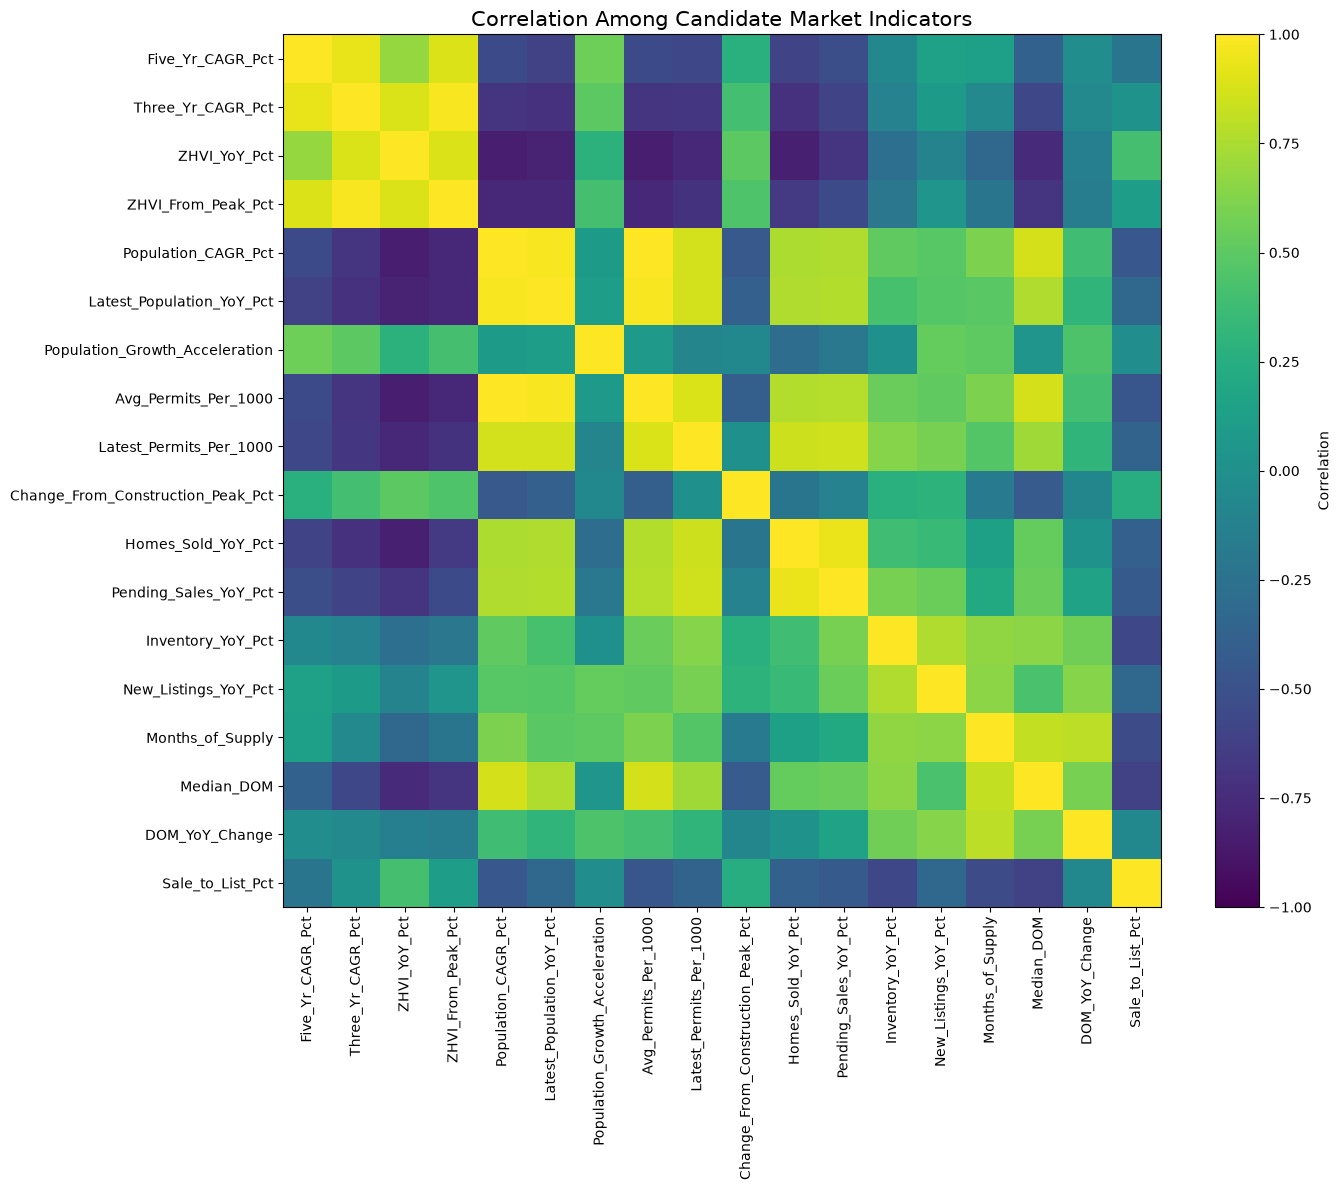

In [157]:
# CORRELATION HEATMAP

fig, ax = plt.subplots(figsize=(14,12))

im = ax.imshow(
    correlation_matrix,
    aspect="auto",
    vmin=-1,
    vmax=1
)

ax.set_xticks(
    range(len(correlation_matrix.columns))
)

ax.set_xticklabels(
    correlation_matrix.columns, rotation=90
)

ax.set_yticks(
    range(len(correlation_matrix.index))
)

ax.set_yticklabels(correlation_matrix.index)

fig.colorbar(im, ax=ax, label="Correlation")

ax.set_title("Correlation Among Candidate Market Indicators", fontsize=15)

plt.tight_layout()
plt.show()

In [158]:
fundamental_relationships = market_master[
    [
        "Population_CAGR_Pct",
        "Latest_Population_YoY_Pct",
        "Population_Growth_Acceleration",
        "Avg_Permits_Per_1000",
        "Latest_Permits_Per_1000"
    ]
].corr()

fundamental_relationships.round(2)

,Population_CAGR_Pct,Latest_Population_YoY_Pct,Population_Growth_Acceleration,Avg_Permits_Per_1000,Latest_Permits_Per_1000
Population_CAGR_Pct,1.00,0.98,0.09,1.00,0.86
Latest_Population_YoY_Pct,0.98,1.00,0.12,0.98,0.87
Population_Growth_Acceleration,0.09,0.12,1.00,0.08,-0.09
Avg_Permits_Per_1000,1.00,0.98,0.08,1.00,0.89
Latest_Permits_Per_1000,0.86,0.87,-0.09,0.89,1.00


In [159]:
transaction_relationships = market_master[
    [
        "Homes_Sold_YoY_Pct",
        "Pending_Sales_YoY_Pct",
        "New_Listings_YoY_Pct"
    ]
].corr()

transaction_relationships.round(2)

,Homes_Sold_YoY_Pct,Pending_Sales_YoY_Pct,New_Listings_YoY_Pct
Homes_Sold_YoY_Pct,1.00,0.94,0.36
Pending_Sales_YoY_Pct,0.94,1.00,0.55
New_Listings_YoY_Pct,0.36,0.55,1.00


In [160]:
supply_relationships = market_master[
    [
        "Inventory_YoY_Pct",
        "Months_of_Supply",
        "Median_DOM",
        "DOM_YoY_Change",
        "Sale_to_List_Pct"
    ]
].corr()

supply_relationships.round(2)

,Inventory_YoY_Pct,Months_of_Supply,Median_DOM,DOM_YoY_Change,Sale_to_List_Pct
Inventory_YoY_Pct,1.00,0.67,0.65,0.57,-0.57
Months_of_Supply,0.67,1.00,0.82,0.80,-0.54
Median_DOM,0.65,0.82,1.00,0.59,-0.61
DOM_YoY_Change,0.57,0.80,0.59,1.00,-0.07
Sale_to_List_Pct,-0.57,-0.54,-0.61,-0.07,1.00


## Variable Selection for Composite Scoring

The exploratory correlation analysis identified substantial redundancy among several candidate indicators. Because the dataset contains only nine markets, the correlations are not interpreted as statistically robust estimate of broader housing-market relationships. Instead, they are used as diagnostic tool to reduce obvious duplication within the eventual scoring framework.

Variable selection follows four principles:
1. **Avoid double-counting:** High correlated indicators representing the same economic concept should not independently recieve full weights.
2. **Preserve distinct economic dimensions:** Correlated variables may still be retained when they represent meaningfully different concepts, but they should not necessarily appear in the same composite score.
3. **Separate structural fundamentals from current conditions:** Long-term population and price growth describe a different dimension of market attractiveness than current inventory, transaction, and market speed.
4. **Treat construction carefully:** High-permitting activity can indicate strong market expansion and developer confidence, but it can also represent greater future housing supply and competition. Construction is therefore evaluated separately rather than automatically treated as a uniformly positive signal.

In [161]:
# PROPOSED MODEL VARIABLE SELECTION

model_variable_selection = pd.DataFrame(
    [
        # Long-term fundamentals
        [
            "Population_CAGR_Pct",
            "Long-Term Fundamentals",
            "Keep",
            "Higher is better",
            "Sustained demographic growth"
        ],
        [
            "Five_Yr_CAGR_Pct",
            "Long-Term Fundamentals",
            "Keep",
            "Higher is better",
            "Median-term realized home-value appreciation"
        ],
        [
            "Population_Growth_Acceleration",
            "Long-Term Fundamentals",
            "Keep",
            "Higher is better",
            "Captures change in demographic growth rate"
        ],

        # Construction context
        [
            "Avg_Permits_Per_1000",
            "Construction Context",
            "Context",
            "Ambiguous",
            "Strongly correlated with population growth; supply and growth signal"
        ],
        [
            "Latest_Permits_Per_1000",
            "Construction Context",
            "Context",
            "Ambiguous",
            "Current construction intensity"
        ],
        [
            "Change_From_Construction_Peak_Pct",
            "Construction Context",
            "Context",
            "Ambiguous",
            "Shows whether construction is accelerating or moderating"
        ],

        # Current momentum
        [
            "ZHVI_YoY_Pct",
            "Current Market Momentum",
            "Keep",
            "Higher is better",
            "Current home-value momentum"
        ],
        [
            "Homes_Sold_YoY_Pct",
            "Current Market Momentum",
            "Keep",
            "Higher is better",
            "Current transaction momentum"
        ],
        [
            "Inventory_YoY_Pct",
            "Current Market Momentum",
            "Keep",
            "Lower is better",
            "Direction of available supply"
        ],
        [
            "Months_of_Supply",
            "Current Market Momentum",
            "Keep",
            "Lower is better",
            "Current supply-demand balance"
        ],
        [
            "Sale_to_List_Pct",
            "Current Market Momentum",
            "Keep",
            "Higher is better",
            "Seller pricing power"
        ],

        # Context / Redunancy
        [
            "Three_Yr_CAGR_Pct",
            "Price Context",
            "Context",
            "Higher is better",
            "Highly correlated with five-year CAGR"
        ],
        [
            "ZHVI_From_Peak_Pct",
            "Price Context",
            "Context",
            "Higher is better",
            "Useful correction indicator but correlated with price trends"
        ],
        [
            "Latest_Population_YoY_Pct",
            "Demographic Context",
            "Context",
            "Higher is better",
            "Highly correlated with population CAGR"
        ],
        [
            "Pending_Sales_YoY_Pct",
            "Transaction Context",
            "Context",
            "Higher is better",
            "Highly correlated with homes sold growth"
        ],
        [
            "New_Listings_YoY_Pct",
            "Supply Context",
            "Context",
            "Ambiguous",
            "Useful additional supply indicator"
        ],
        [
            "Median_DOM",
            "Market Speed Context",
            "Context",
            "Lower is better",
            "Correlated with inventory and months supply"
        ],
        [
            "DOM_YoY_Change",
            "Market Speed Context",
            "Context",
            "Lower is better",
            "Correlated with months supply"
        ]       
    ],
    columns=[
        "Variable",
        "Dimension",
        "Model_Status",
        "Direction",
        "Rationale"
    ]
)

model_variable_selection

,Variable,Dimension,Model_Status,Direction,Rationale
0,Population_CAGR_Pct,Long-Term Fundamentals,Keep,Higher is better,Sustained demographic growth
1,Five_Yr_CAGR_Pct,Long-Term Fundamentals,Keep,Higher is better,Median-term realized home-value appreciation
2,Population_Growth_Acceleration,Long-Term Fundamentals,Keep,Higher is better,Captures change in demographic growth rate
3,Avg_Permits_Per_1000,Construction Context,Context,Ambiguous,Strongly correlated with population growth; su...
4,Latest_Permits_Per_1000,Construction Context,Context,Ambiguous,Current construction intensity
5,Change_From_Construction_Peak_Pct,Construction Context,Context,Ambiguous,Shows whether construction is accelerating or ...
6,ZHVI_YoY_Pct,Current Market Momentum,Keep,Higher is better,Current home-value momentum
7,Homes_Sold_YoY_Pct,Current Market Momentum,Keep,Higher is better,Current transaction momentum
8,Inventory_YoY_Pct,Current Market Momentum,Keep,Lower is better,Direction of available supply
9,Months_of_Supply,Current Market Momentum,Keep,Lower is better,Current supply-demand balance


In [162]:
# PROVISIONAL MODEL INPUTS

fundamental_variables = [
    "Population_CAGR_Pct",
    "Five_Yr_CAGR_Pct",
    "Population_Growth_Acceleration"
]

momentum_positive_variables = [
    "ZHVI_YoY_Pct",
    "Homes_Sold_YoY_Pct",
    "Sale_to_List_Pct"
]

momentum_negative_variables = [
    "Inventory_YoY_Pct",
    "Months of Supply"
]

construction_context_variables = [
    "Avg_Permits_Per_1000",
    "Latest_Permits_Per_1000",
    "Change_From_Construction_Peak_Pct",
    "Latest_SF_Share_Pct"
]

print("Fundamentals:", fundamental_variables)
print("Momentum - higher is better:", momentum_positive_variables)
print("Momentum - lower is better:", momentum_negative_variables)
print("Construction context:", construction_context_variables)

Fundamentals: ['Population_CAGR_Pct', 'Five_Yr_CAGR_Pct', 'Population_Growth_Acceleration']
Momentum - higher is better: ['ZHVI_YoY_Pct', 'Homes_Sold_YoY_Pct', 'Sale_to_List_Pct']
Momentum - lower is better: ['Inventory_YoY_Pct', 'Months of Supply']
Construction context: ['Avg_Permits_Per_1000', 'Latest_Permits_Per_1000', 'Change_From_Construction_Peak_Pct', 'Latest_SF_Share_Pct']


## EDA Conclusion

The exploratory analysis reveals substantial differences between long-term market fundamentals and current housing-market conditions across North Dallas.

The fastest-growing demographic markets (particularly Celina, Princeton, Melissa, and Anna) also experience the highest residential construction intensity. This relationship indicates that rapid population expansion has been accompanied by a substantial supply response rather than occurring under fixed housing supply.

At the same time, all nine markets currently exhibit negative year-over-year ZHVI growth, demonstrating a broad regional housing-price correction. The severity and accompanying market dynamics differ considerably. Princeton combines a large price correction with strong transaction and pending-sales growth, relatively contained inventory, and improving market speed. Celina also exhibits strong transaction activity but faces considerably greater current supply pressure. Plano and Frisco demonstrate greater price resilience but substantially slower demographic expansion.

Correlation analysis also identifies significant redundancy among several candidate indicators. Population CAGR, recent population growth, and historical construction indicators. Population CAGR, recent population growth, and historical construction intensity are highly correlated across the nine markets, while homes-sold and pending-sales growth provide nearly identical transaction signals. Similarly, several measures of supply and market speed are correlated.

To avoid unintentionally overweighting these underlying economic dimensions, the subsequent scoring model uses a reduced set of indicators. Long-term fundamentals and current market momentum are modeled separately, while residential constructin is retained as an important contextual measure because high construction can represnet both market expansion and future competitive supply.

The resulting modeling framework therefore distinguishes between:
- **Long-Term Growth Fundamentals**: sustained demographic growth, historical home-value appreciation, and changes in demographic growth.
- **Current Market Momentum**: current price performance, transaction activity, inventory trends, supply-demand balance, and seller pricing power.
- **Construction Context**: the scale, intensity, and recent direction of new residential development.

This framework provides the foundation for the market scoring and comparative investment analysis developed in the next notebook.